# KDB Family — Extended FewPLa Dataset Benchmark

Adds all eleven requested datasets to the existing runtime-optimized comparative notebook.
The frozen learners and numerical optimization layer are unchanged. Previous outputs have been
cleared because they do not describe this expanded experiment.

Dataset specifications come from Table 1 of the supplied **FewPla: Efficient And Effective Limited
Pass Learning For Large Data Quantities**, `ecmlpkdd2017b.pdf`, pp. 11–12, and its references 19–20.
The paper's dataset table contains discrepancies with current source releases; the source audit
below records these instead of silently changing the task.

**This is an expanded KDB-family comparison, not a complete reproduction of FewPLa.** The paper
uses ten discriminative passes, validation-based learning-rate search, and adaptive regularization.
This notebook retains the existing D=1, fixed-rate configuration and experimental sdKDB variant.
`PAPER_FIDELITY` matches only the paper's two rounds of two-fold outer evaluation.


## 1. What was slow, what changed, and why the study is still the same

The previous notebook was correct but operationally hostile at CORE scale.
It reparsed data after kernel restarts, fitted the same `k=5` generative
state four times per split, and executed its hottest loops one Python row
at a time. Full three-fold evaluation of hundreds of thousands of rows multiplied
redundant work into days.

| Change | Runtime benefit | Scientific invariant protected |
|---|---|---|
| Vectorized, feature-parallel MDL candidate scoring | Removes per-candidate Python work | Same Fayyad–Irani criterion, strict comparison, cuts, missing state, and train-fold-only fit; equality-tested |
| Batched vectorized MI/CMI and parameter counts | Replaces row/context Python loops | Same integer sufficient statistics, MI/CMI ordering, parents, tables, and logical passes; equality-tested |
| Compiled sKDB third-pass LOOCV | Removes row × prefix × k Python dispatch | Same incremental LOOCV RMSE, min-count fallback, strict winner scan, selected `k`/prefix; equality-tested |
| Compiled dKDB/sdKDB online updates | Accelerates the inner numeric loop | Same row order, SGD/AdaGrad update order, learning rate, `D`, and fixed generative Θ; weights/probabilities equality-tested |
| Grouped, batched prediction | Evaluates repeated contexts together | Same deepest-available-context backoff and probabilities; equality-tested |
| Shared physical `k=5` base and sKDB selection within a fold | Cuts headline physical learner passes from 12 to 5 | Each model retains its standalone logical `2/3/3/4` pass record and measured standalone-equivalent stage time; predictive state is identical |
| Processed `.npy` cache plus per-model result checkpoints | Fast restart after kernel loss | Cache keys include code/config/data hashes; no stale reuse; final tables rebuild in this notebook |
| Timeout/retry/progress downloads and concurrent cod-rna parts | Prevents silent indefinite loader hangs | Same official three cod-rna partitions and exact loaded rows |
| Practical and full-fidelity modes are separate | A complete comparison can finish in a sensible session | Practical samples are labelled, deterministic, and never called full; the original full modes remain available |
| Per-mode wall-clock budget and stage progress | Stops at safe checkpoint boundaries instead of drifting for days | No partial model is reported complete; rerun resumes finished model records |

The headline comparison remains KDB `k=5`, sKDB `kmax=5`, dKDB
`k=5,D=1`, and **experimental/unpublished sdKDB** `kmax=5,D=1` with
identical outer splits and one shared train-only MDL discretization per
split. Metrics, pass accounting, statistical unit (dataset—not CV fold),
stress holdouts, sensitivity experiment, and final plots remain intact.

Practical modes change only the *evaluation scope*: they use declared
deterministic row caps. Use the corresponding `_FULL` mode when every
source row is required. Results from the two scopes must not be pooled.


## 2. Imports and the one centralized configuration cell


In [1]:
from __future__ import annotations

import gc
import gzip
import json
import math
import os
import pickle
import platform
import sys
import urllib.request
import warnings
import requests
import zipfile
from collections.abc import Callable, Iterator, Mapping, Sequence
from contextlib import contextmanager
from dataclasses import asdict, dataclass
from hashlib import sha256
from math import log2
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import friedmanchisquare, rankdata, studentized_range, t, wilcoxon
from sklearn.datasets import fetch_covtype, fetch_openml, load_svmlight_file
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.22})

DIRECT_SOURCE_NOTEBOOK = 'KDB Family - Multi-Dataset Comparative Benchmark.ipynb'
DIRECT_SOURCE_SHA256 = 'F1100B93531CEBF7FD43ABC12F001088AA2FBEFCE8F40101A8CF9D6D7B7A781C'
FROZEN_IMPLEMENTATION_SHA256 = '2BF6A258EDC878E6A7671644B5539AC38BD5BF802800982102CD8F80FBD60232'
OPTIMIZATION_LAYER_SHA256 = 'A315ECF19686CF8C4C0511854E7AC3419E5D263B85FD7FFE02FE0EA788324185'
REPOSITORY_COMMIT = 'cf55d7c5570f8304c618c9883dd9c8e364a85a3d'

# ------------------------- ONE CONFIGURATION CELL -------------------------
MODE = "CORE_PRACTICAL"  # SMOKE | CORE_PRACTICAL | CORE_FULL | STRESS_PRACTICAL | STRESS_FULL | PAPER_FIDELITY

RANDOM_SEED = 5
K = 5
KMAX = 5
D = 1
OPTIMIZER = "adagrad"
LEARNING_RATE = 0.01
ADAGRAD_EPSILON = 1e-9
SENSITIVITY_K_VALUES = tuple(range(6))

# Runtime kernels: memory-bounded batches; none changes row/update order.
MDL_N_JOBS = max(1, min(4, os.cpu_count() or 1))
STRUCTURE_BATCH_MAX_ROWS = 8_192
STRUCTURE_BATCH_TARGET_CELLS = 3_000_000
PARAMETER_BATCH_ROWS = 8_192
SELECTION_BATCH_ROWS = 4_096
DISCRIMINATIVE_BATCH_ROWS = 4_096
PREDICTION_BATCH_ROWS = 16_384
DOWNLOAD_TIMEOUT_SECONDS = 90
DOWNLOAD_RETRIES = 3
DOWNLOAD_CHUNK_BYTES = 8 * 1024 * 1024

MODE_CONFIGS = {
    "SMOKE": {
        "datasets": ("Skin Segmentation", "MiniBooNE"),
        "folds": 2, "repeats": 2,
        "row_limits": {"Skin Segmentation": 300, "MiniBooNE": 200},
        "scaling_rows": (), "stress_test_rows": None,
        "use_predefined_holdout": False, "max_minutes": 20,
        "evaluation_scope": "smoke only",
    },
    "CORE_PRACTICAL": {
        "datasets": ("Skin Segmentation", "MiniBooNE", "cod-rna", "Covertype"),
        "folds": 3, "repeats": 1,
        "row_limits": {
            "Skin Segmentation": 50_000, "MiniBooNE": 50_000,
            "cod-rna": 50_000, "Covertype": 50_000,
          },
        "scaling_rows": (), "stress_test_rows": None,
        "use_predefined_holdout": False, "max_minutes": 240,
        "evaluation_scope": "deterministic declared practical sample",
    },
    "CORE_FULL": {
        "datasets": ("cod-rna", "Covertype"),
        "folds": 3, "repeats": 1, "row_limits": {},
        "scaling_rows": (), "stress_test_rows": None,
        "use_predefined_holdout": False, "max_minutes": 1_440,
        "evaluation_scope": "full source datasets (original CORE contract)",
    },
    "STRESS_PRACTICAL": {
        "datasets": ("SUSY", "HIGGS"), "folds": 1, "repeats": 1,
        "row_limits": {}, "scaling_rows": (100_000, 250_000, 500_000),
        "stress_test_rows": 100_000, "use_predefined_holdout": True,
        "max_minutes": 480,
        "evaluation_scope": "nested documented training prefixes; deterministic 100k sample from final-500k test block",
    },
    "STRESS_FULL": {
        "datasets": ("SUSY", "HIGGS"), "folds": 1, "repeats": 1,
        "row_limits": {},
        "scaling_rows": (100_000, 250_000, 500_000, 1_000_000, 2_000_000, None),
        "stress_test_rows": None, "use_predefined_holdout": True,
        "max_minutes": 1_440,
        "evaluation_scope": "original full stress scaling and final-500k test block",
    },
    "PAPER_FIDELITY": {
        "datasets": ("Skin Segmentation", "MiniBooNE", "cod-rna", "Covertype"),
        "folds": 10, "repeats": 1,
        "row_limits": {
            "Skin Segmentation": 50_000, "MiniBooNE": 50_000,
            "cod-rna": 50_000, "Covertype": 50_000,
        },
        "scaling_rows": (), "stress_test_rows": None,
        "use_predefined_holdout": False, "max_minutes": 480,
        "evaluation_scope": "10-fold external CV on declared practical samples",
    },
}

# Dataset selection and source policy. Full-data mode is the default.
DATASET_EXTENSION_VERSION = "fewpla-datasets-v1"
REQUESTED_DATASETS = (
    "PokerHand", "Diabetes", "Waveform", "WearableComputing", "Localization",
    "TwitterAbsoluteSigma", "CensusIncome", "KddCUP", "USPSExtended", "MNIST", "Satellite",
)
ALL_CORE_DATASETS = ("Skin Segmentation", "MiniBooNE", "cod-rna", "Covertype") + REQUESTED_DATASETS
# Strict by default: discrepancies require an original source or an explicit
# variant experiment. Shape agreement alone does not prove original-file identity.
REQUIRE_PAPER_SHAPE = False
SOURCE_CHUNK_ROWS = 8192
DATASET_SOURCE_OVERRIDES = {}
# Examples (replace paths/target/schema with the actual ORIGINAL experiment file):
# DATASET_SOURCE_OVERRIDES["Diabetes"] = {
#     "path": "paper-datasets/Diabetes.arff", "format": "arff", "target": -1,
#     "description": "Original binary 46-feature FewPLa experiment file",
# }
# DATASET_SOURCE_OVERRIDES["WearableComputing"] = {
#     "path": "paper-datasets/PUC-Rio.csv", "format": "csv", "target": "class",
#     "read_csv": {"sep": ";", "decimal": ",", "na_values": ["?"]},
#     "categorical": ["user", "gender"], "description": "Full original donor file",
# }
# DATASET_SOURCE_OVERRIDES["USPSExtended"] = {
#     "path": "paper-datasets/usps-extended.libsvm.bz2", "format": "libsvm",
#     "n_features": 676, "rows": 341462, "zero_based": False,
#     "description": "CVM binary extended USPS",
# }
# DATASET_SOURCE_OVERRIDES["KddCUP"] = {
#     "paths": ["paper-datasets/kddcup.data.gz", "paper-datasets/corrected.gz"],
#     "format": "csv", "target": -1, "read_csv": {"header": None},
#     "categorical": [1, 2, 3, 6, 11, 20, 21],
#     "description": "Original full KDD Cup 1999 train and corrected test",
# }
# For large datasets, prefer numeric .npy files or chunked LIBSVM parsing:
# DATASET_SOURCE_OVERRIDES["Satellite"] = {
#     "paths": ["paper-datasets/Satellite-X.npy", "paper-datasets/Satellite-y.npy"],
#     "format": "npy", "description": "Original 138-feature, 24-class data",
# }
TWITTER_CLASSIFICATION_URL = (
    "https://lig-aptikal.imag.fr/all-data/data/buzz/classification/Twitter/"
    "Absolute_labeling/Twitter-Absolute-Sigma-500.data"
)
MODE_CONFIGS["CORE_FULL"].update(
    datasets=ALL_CORE_DATASETS, max_minutes=None,
    evaluation_scope="full source datasets; three-fold comparative experiment",
)
MODE_CONFIGS["CORE_PRACTICAL"]["datasets"] = ALL_CORE_DATASETS
MODE_CONFIGS["CORE_PRACTICAL"]["row_limits"].update({name: 50_000 for name in REQUESTED_DATASETS})
# Correct the former misleading ten-fold label: the supplied FewPLa paper uses 2x2 CV.
# This matches its OUTER SPLITS only: learner D=1 and fixed learning rate remain unchanged.
MODE_CONFIGS["PAPER_FIDELITY"].update(
    datasets=ALL_CORE_DATASETS, folds=2, repeats=2, row_limits={}, max_minutes=None,
    evaluation_scope="FewPLa outer protocol: 2 rounds x 2 folds, full source data; algorithm differs",
)

RUN_BENCHMARKS = True
RUN_K_SENSITIVITY = True
ENABLE_PROCESSED_DATA_CACHE = True
ENABLE_RESULT_CACHE = True
RESUME_COMPLETED_RUNS = True
FAIL_FAST = False
CACHE_SCHEMA_VERSION = 3
CACHE_ROOT = Path("KDB family runtime-optimized cache")
DATA_CACHE_DIR = CACHE_ROOT / "raw-datasets"
PROCESSED_DATA_CACHE = CACHE_ROOT / "processed-datasets"
RESULT_CACHE_ROOT = CACHE_ROOT / "results"

if MODE not in MODE_CONFIGS:
    raise ValueError(f"Unknown MODE={MODE!r}")
if (K, KMAX, D) != (5, 5, 1):
    raise AssertionError("Matched headline capacity must remain k=5/kmax=5,D=1")
ACTIVE_MODE = MODE_CONFIGS[MODE]
CONFIG_PAYLOAD = {
    "schema": CACHE_SCHEMA_VERSION, "mode": MODE, "mode_config": ACTIVE_MODE,
    "dataset_extension_sha256": "9623495a32375f1121e5f8c53ef2a1be6deae059d074eccad832ef1b685935bc",
    "source_overrides": DATASET_SOURCE_OVERRIDES, "strict_paper_shape": REQUIRE_PAPER_SHAPE,
    "seed": RANDOM_SEED, "k": K, "kmax": KMAX, "D": D,
    "optimizer": OPTIMIZER, "learning_rate": LEARNING_RATE,
    "source_sha256": DIRECT_SOURCE_SHA256,
    "optimization_sha256": OPTIMIZATION_LAYER_SHA256,
    "batches": {
        "mdl_jobs": MDL_N_JOBS, "structure": STRUCTURE_BATCH_TARGET_CELLS,
        "parameter": PARAMETER_BATCH_ROWS, "selection": SELECTION_BATCH_ROWS,
        "discriminative": DISCRIMINATIVE_BATCH_ROWS, "prediction": PREDICTION_BATCH_ROWS,
    },
}
CONFIGURATION_ID = sha256(
    json.dumps(CONFIG_PAYLOAD, sort_keys=True, default=str).encode("utf-8")
).hexdigest()[:16]
print(f"MODE={MODE} | configuration_id={CONFIGURATION_ID}")
display(pd.DataFrame([{"mode": MODE, **ACTIVE_MODE}]))


MODE=CORE_PRACTICAL | configuration_id=54c0518917f385f8


,mode,datasets,folds,repeats,row_limits,scaling_rows,stress_test_rows,use_predefined_holdout,max_minutes,evaluation_scope
0,CORE_PRACTICAL,"(Skin Segmentation, MiniBooNE, cod-rna, Covert...",3,1,"{'Skin Segmentation': 50000, 'MiniBooNE': 5000...",(),None,False,240,deterministic declared practical sample


## 3. Frozen implementation reference (unchanged)


These cells are copied exactly from the prior notebook. They remain the
semantic reference and are used by the equivalence suite. The optimized
layer subclasses them; it does not loosen their mathematical contracts.


### Frozen supervised MDL discretizer


In [2]:
def _entropy(counts: np.ndarray) -> float:
    total = int(counts.sum())
    if total == 0:
        return 0.0
    probabilities = counts[counts > 0] / total
    return float(-np.sum(probabilities * np.log2(probabilities)))


def _mdl_cut_points(values: np.ndarray, labels: np.ndarray) -> np.ndarray:
    """Return recursively accepted Fayyad-Irani MDL cuts for one feature."""

    if values.size < 2 or np.unique(labels).size < 2:
        return np.empty(0, dtype=np.float64)

    order = np.argsort(values, kind="mergesort")
    sorted_values = values[order]
    sorted_labels = labels[order]
    n_classes = int(sorted_labels.max()) + 1
    accepted: list[float] = []

    def split(start: int, stop: int) -> None:
        n = stop - start
        if n < 2:
            return

        node_labels = sorted_labels[start:stop]
        total_counts = np.bincount(node_labels, minlength=n_classes)
        parent_entropy = _entropy(total_counts)
        if parent_entropy == 0.0:
            return

        left_counts = np.zeros(n_classes, dtype=np.int64)
        best_position: int | None = None
        best_weighted_entropy = np.inf
        for position in range(start, stop - 1):
            left_counts[sorted_labels[position]] += 1
            if sorted_values[position] == sorted_values[position + 1]:
                continue
            n_left = position - start + 1
            n_right = n - n_left
            right_counts = total_counts - left_counts
            weighted = (
                n_left * _entropy(left_counts)
                + n_right * _entropy(right_counts)
            ) / n
            if weighted < best_weighted_entropy:
                best_weighted_entropy = weighted
                best_position = position

        if best_position is None:
            return

        left = np.bincount(
            sorted_labels[start : best_position + 1], minlength=n_classes
        )
        right = total_counts - left
        gain = parent_entropy - best_weighted_entropy
        k = int(np.count_nonzero(total_counts))
        k_left = int(np.count_nonzero(left))
        k_right = int(np.count_nonzero(right))
        delta = log2((3**k) - 2) - (
            k * parent_entropy
            - k_left * _entropy(left)
            - k_right * _entropy(right)
        )
        threshold = (log2(n - 1) + delta) / n
        if gain <= threshold:
            return

        low = float(sorted_values[best_position])
        high = float(sorted_values[best_position + 1])
        accepted.append(low + (high - low) / 2.0)
        split(start, best_position + 1)
        split(best_position + 1, stop)

    split(0, sorted_values.size)
    return np.asarray(sorted(accepted), dtype=np.float64)


class MDLDiscretizer:
    """Training-fold-only, in-memory supervised MDL discretizer.

    A permanently reserved state handles NaN and +/- infinity.  The public fit
    audit fields are used by the evaluator and leakage tests.
    """

    method_name = "Fayyad-Irani supervised MDL (in memory; training fold only)"

    def __init__(self) -> None:
        self.cut_points_: list[np.ndarray] | None = None
        self.cardinalities_: np.ndarray | None = None
        self.fit_seconds_: float = 0.0
        self.fit_rows_: int = 0
        self.fit_calls_: int = 0

    def fit(self, X: Sequence, y: Sequence) -> "MDLDiscretizer":
        started = perf_counter()
        X_array = _numeric_matrix(X)
        y_array = np.asarray(y, dtype=object).reshape(-1)
        if len(X_array) != len(y_array):
            raise ValueError("X and y must contain the same number of rows")
        if len(X_array) == 0:
            raise ValueError("Cannot fit MDLDiscretizer on an empty fold")

        label_to_index: dict[object, int] = {}
        encoded_y = np.empty(len(y_array), dtype=np.int32)
        for row, label in enumerate(y_array.tolist()):
            try:
                encoded_y[row] = label_to_index[label]
            except KeyError:
                label_to_index[label] = len(label_to_index)
                encoded_y[row] = label_to_index[label]

        self.cut_points_ = []
        for feature in range(X_array.shape[1]):
            observed = np.isfinite(X_array[:, feature])
            self.cut_points_.append(
                _mdl_cut_points(
                    X_array[observed, feature], encoded_y[observed]
                )
            )

        # digitize yields len(cuts)+1 observed bins; reserve one more for missing.
        self.cardinalities_ = np.asarray(
            [len(cuts) + 2 for cuts in self.cut_points_], dtype=np.int32
        )
        self.fit_rows_ = int(len(X_array))
        self.fit_calls_ += 1
        self.fit_seconds_ = float(perf_counter() - started)
        return self

    def transform(self, X: Sequence) -> np.ndarray:
        if self.cut_points_ is None or self.cardinalities_ is None:
            raise RuntimeError("MDLDiscretizer must be fitted before transform")
        X_array = _numeric_matrix(X)
        if X_array.shape[1] != len(self.cut_points_):
            raise ValueError("Transform data has a different feature count")

        transformed = np.empty(X_array.shape, dtype=np.int32)
        for feature, cuts in enumerate(self.cut_points_):
            observed = np.isfinite(X_array[:, feature])
            transformed[observed, feature] = np.digitize(
                X_array[observed, feature], cuts, right=False
            )
            transformed[~observed, feature] = len(cuts) + 1
        return transformed

    def fit_transform(self, X: Sequence, y: Sequence) -> np.ndarray:
        return self.fit(X, y).transform(X)


def _numeric_matrix(X: Sequence) -> np.ndarray:
    if hasattr(X, "to_numpy"):
        X = X.to_numpy(copy=False)
    array = np.asarray(X)
    if array.ndim != 2:
        raise ValueError("X must be a two-dimensional matrix")
    try:
        return array.astype(np.float64, copy=False)
    except (TypeError, ValueError) as exc:
        raise TypeError("MDLDiscretizer requires numeric features") from exc


### Frozen pass tracker


In [3]:
@dataclass(frozen=True)
class PassRecord:
    stage: str
    pass_number: int
    rows_processed: int
    seconds: float


class PassTracker:
    """Records only full learner traversals (preprocessing is separate)."""

    def __init__(self, expected_rows: int) -> None:
        if expected_rows <= 0:
            raise ValueError("expected_rows must be positive")
        self.expected_rows = int(expected_rows)
        self.records: list[PassRecord] = []

    @contextmanager
    def iter_rows(
        self, stage: str, X: np.ndarray, y: np.ndarray
    ) -> Iterator[Iterator[tuple[np.ndarray, int]]]:
        processed = 0
        started = perf_counter()

        def rows() -> Iterator[tuple[np.ndarray, int]]:
            nonlocal processed
            for index in range(self.expected_rows):
                processed += 1
                yield X[index], int(y[index])

        yield rows()
        if processed != self.expected_rows:
            raise RuntimeError(
                f"{stage} processed {processed} rows; expected "
                f"{self.expected_rows}"
            )
        self.records.append(
            PassRecord(
                stage=stage,
                pass_number=len(self.records) + 1,
                rows_processed=processed,
                seconds=float(perf_counter() - started),
            )
        )

    @contextmanager
    def iter_batches(
        self,
        stage: str,
        X: np.ndarray,
        y: np.ndarray,
        batch_size: int,
    ) -> Iterator[Iterator[tuple[np.ndarray, np.ndarray]]]:
        processed = 0
        started = perf_counter()

        def batches() -> Iterator[tuple[np.ndarray, np.ndarray]]:
            nonlocal processed
            for start in range(0, self.expected_rows, batch_size):
                stop = min(start + batch_size, self.expected_rows)
                processed += stop - start
                yield X[start:stop], y[start:stop]

        yield batches()
        if processed != self.expected_rows:
            raise RuntimeError(
                f"{stage} processed {processed} rows; expected "
                f"{self.expected_rows}"
            )
        self.records.append(
            PassRecord(
                stage=stage,
                pass_number=len(self.records) + 1,
                rows_processed=processed,
                seconds=float(perf_counter() - started),
            )
        )

    @property
    def pass_count(self) -> int:
        return len(self.records)

    @property
    def rows_processed(self) -> int:
        return int(sum(record.rows_processed for record in self.records))

    def as_records(self) -> list[dict[str, object]]:
        return [asdict(record) for record in self.records]


### Frozen KDB


In [4]:
class KDBClassifier:
    """K-dependence Bayesian classifier for discrete, non-negative features.

    ``k=0`` is a genuine one-pass Naive Bayes path: it skips MI, CMI and all
    pair-count allocation.  ``k>0`` uses one structure pass and one parameter
    pass, as in Fupla's KDB stages.
    """

    model_name = "KDB"

    def __init__(self, k: int = 1, *, m_estimate: float = 1.0) -> None:
        if int(k) != k or k < 0:
            raise ValueError("k must be a non-negative integer")
        if m_estimate <= 0:
            raise ValueError("m_estimate must be positive")
        self.k = int(k)
        self.m_estimate = float(m_estimate)

    def fit(self, X: Sequence, y: Sequence) -> "KDBClassifier":
        X_array = _categorical_matrix(X)
        y_encoded, classes, label_to_index = _encode_labels(y)
        if len(X_array) != len(y_encoded):
            raise ValueError("X and y must contain the same number of rows")
        if len(X_array) == 0 or X_array.shape[1] == 0:
            raise ValueError("KDB requires at least one row and one feature")

        self.classes_ = classes
        self._label_to_index_ = label_to_index
        self.n_classes_ = len(classes)
        self.n_features_in_ = X_array.shape[1]
        self.n_train_rows_ = len(X_array)
        self.cardinalities_ = X_array.max(axis=0).astype(np.int64) + 1
        self.pass_tracker_ = PassTracker(len(X_array))
        self.structure_learned_ = self.k > 0
        self.selection_rmse_ = None
        self.selected_k_ = min(self.k, self.n_features_in_ - 1)
        self.selected_feature_count_ = self.n_features_in_
        self.discriminative_iterations_ = 0
        self.discriminative_updates_ = 0

        if self.k == 0:
            self.feature_order_ = np.arange(self.n_features_in_, dtype=np.int64)
            self.parents_ = [np.empty(0, dtype=np.int64) for _ in self.feature_order_]
            self.class_counts_ = np.zeros(self.n_classes_, dtype=np.int64)
            self.tables_ = [
                [
                    {
                        (): np.zeros(
                            (int(self.cardinalities_[feature]), self.n_classes_),
                            dtype=np.int64,
                        )
                    }
                ]
                for feature in self.feature_order_
            ]
            with self.pass_tracker_.iter_rows(
                "naive_bayes_parameters", X_array, y_encoded
            ) as rows:
                for row, target in rows:
                    self.class_counts_[target] += 1
                    for position, feature in enumerate(self.feature_order_):
                        self.tables_[position][0][()][int(row[feature]), target] += 1
        else:
            self._fit_structure(X_array, y_encoded)
            self._fit_parameters(X_array, y_encoded)

        self.full_feature_order_ = self.feature_order_.copy()
        self.training_seconds_ = float(
            sum(record.seconds for record in self.pass_tracker_.records)
        )
        return self

    def _fit_structure(self, X: np.ndarray, y: np.ndarray) -> None:
        n_features = self.n_features_in_
        n_classes = self.n_classes_
        xy_offsets = np.zeros(n_features, dtype=np.int64)
        if n_features > 1:
            xy_offsets[1:] = np.cumsum(self.cardinalities_[:-1])
        xy_counts = np.zeros(
            (int(self.cardinalities_.sum()), n_classes), dtype=np.int64
        )
        class_counts = np.zeros(n_classes, dtype=np.int64)

        pair_i: list[int] = []
        pair_j: list[int] = []
        pair_offsets: list[int] = []
        pair_state_total = 0
        for i in range(1, n_features):
            for j in range(i):
                pair_i.append(i)
                pair_j.append(j)
                pair_offsets.append(pair_state_total)
                pair_state_total += int(self.cardinalities_[i] * self.cardinalities_[j])
        pair_i_array = np.asarray(pair_i, dtype=np.int64)
        pair_j_array = np.asarray(pair_j, dtype=np.int64)
        pair_offsets_array = np.asarray(pair_offsets, dtype=np.int64)
        pair_counts = np.zeros((pair_state_total, n_classes), dtype=np.int64)

        n_pairs = max(1, len(pair_i))
        batch_size = max(1, min(512, 1_000_000 // n_pairs))
        with self.pass_tracker_.iter_batches(
            "kdb_structure_mi_cmi", X, y, batch_size
        ) as batches:
            for X_batch, y_batch in batches:
                np.add.at(class_counts, y_batch, 1)
                xy_states = xy_offsets[None, :] + X_batch
                for class_index in range(n_classes):
                    mask = y_batch == class_index
                    if np.any(mask):
                        np.add.at(
                            xy_counts[:, class_index],
                            xy_states[mask].ravel(),
                            1,
                        )
                if pair_i:
                    pair_states = (
                        pair_offsets_array[None, :]
                        + X_batch[:, pair_i_array]
                        * self.cardinalities_[pair_j_array][None, :]
                        + X_batch[:, pair_j_array]
                    )
                    for class_index in range(n_classes):
                        mask = y_batch == class_index
                        if np.any(mask):
                            np.add.at(
                                pair_counts[:, class_index],
                                pair_states[mask].ravel(),
                                1,
                            )

        xy_by_feature = [
            xy_counts[
                int(xy_offsets[f]) : int(xy_offsets[f] + self.cardinalities_[f])
            ]
            for f in range(n_features)
        ]
        total = float(len(X))
        mi = np.zeros(n_features, dtype=np.float64)
        for feature, counts in enumerate(xy_by_feature):
            value_counts = counts.sum(axis=1)
            denominator = value_counts[:, None] * class_counts[None, :]
            mask = counts > 0
            mi[feature] = np.sum(
                (counts[mask] / total)
                * np.log2((counts[mask] * total) / denominator[mask])
            )

        cmi = np.zeros((n_features, n_features), dtype=np.float64)
        pair_lookup: dict[tuple[int, int], int] = {}
        for pair_index, (i, j, offset) in enumerate(
            zip(pair_i, pair_j, pair_offsets)
        ):
            pair_lookup[(i, j)] = pair_index
            size = int(self.cardinalities_[i] * self.cardinalities_[j])
            counts = pair_counts[offset : offset + size].reshape(
                int(self.cardinalities_[i]),
                int(self.cardinalities_[j]),
                n_classes,
            )
            denominator = (
                xy_by_feature[i][:, None, :] * xy_by_feature[j][None, :, :]
            )
            class_numerator = counts * class_counts[None, None, :]
            mask = counts > 0
            score = np.sum(
                (counts[mask] / total)
                * np.log2(class_numerator[mask] / denominator[mask])
            )
            cmi[i, j] = cmi[j, i] = score

        self.feature_mi_ = mi
        self.feature_order_ = np.argsort(-mi, kind="mergesort").astype(np.int64)
        self.parents_ = []
        for position, feature in enumerate(self.feature_order_):
            parent_count = min(position, self.k)
            if parent_count == 0:
                self.parents_.append(np.empty(0, dtype=np.int64))
                continue
            candidates = self.feature_order_[:position]
            candidate_scores = cmi[int(feature), candidates]
            ranking = np.argsort(-candidate_scores, kind="mergesort")
            self.parents_.append(candidates[ranking[:parent_count]].copy())

        # Structure statistics are intentionally local: they are not model state.

    def _fit_parameters(self, X: np.ndarray, y: np.ndarray) -> None:
        self.class_counts_ = np.zeros(self.n_classes_, dtype=np.int64)
        self.tables_: list[list[dict[tuple[int, ...], np.ndarray]]] = []
        for position, feature in enumerate(self.feature_order_):
            self.tables_.append([{} for _ in range(len(self.parents_[position]) + 1)])

        with self.pass_tracker_.iter_rows("kdb_parameters", X, y) as rows:
            for row, target in rows:
                self.class_counts_[target] += 1
                for position, feature in enumerate(self.feature_order_):
                    x_value = int(row[feature])
                    parents = self.parents_[position]
                    for depth in range(len(parents) + 1):
                        context = tuple(int(row[p]) for p in parents[:depth])
                        table = self.tables_[position][depth].get(context)
                        if table is None:
                            table = np.zeros(
                                (int(self.cardinalities_[feature]), self.n_classes_),
                                dtype=np.int64,
                            )
                            self.tables_[position][depth][context] = table
                        table[x_value, target] += 1

    @property
    def learner_passes_(self) -> int:
        return self.pass_tracker_.pass_count

    @property
    def learner_rows_processed_(self) -> int:
        return self.pass_tracker_.rows_processed

    @property
    def selected_feature_indices_(self) -> np.ndarray:
        return self.feature_order_[: self.selected_feature_count_].copy()

    def pass_records(self) -> list[dict[str, object]]:
        return self.pass_tracker_.as_records()

    def model_state_bytes(self) -> int:
        return _deep_sizeof(self)

    def predict_proba(self, X: Sequence) -> np.ndarray:
        self._require_fitted()
        X_array = _categorical_matrix(X)
        if X_array.shape[1] != self.n_features_in_:
            raise ValueError("Prediction data has a different feature count")
        probabilities = np.empty((len(X_array), self.n_classes_), dtype=np.float64)
        for row_index, row in enumerate(X_array):
            probabilities[row_index] = _softmax(self._generative_log_scores(row))
        return probabilities

    def predict(self, X: Sequence) -> np.ndarray:
        probabilities = self.predict_proba(X)
        return self.classes_[np.argmax(probabilities, axis=1)]

    def _generative_log_scores(self, row: np.ndarray) -> np.ndarray:
        scores = self._class_log_theta()
        for position in range(self.selected_feature_count_):
            feature = int(self.feature_order_[position])
            table, _, _ = self._lookup_table(row, position, self.selected_k_)
            scores += self._conditional_log_theta(table, int(row[feature]))
        return scores

    def _class_log_theta(self) -> np.ndarray:
        m = self.m_estimate
        return np.log(
            (self.class_counts_ + m / self.n_classes_)
            / (self.n_train_rows_ + m)
        )

    def _conditional_log_theta(
        self, table: np.ndarray, value: int
    ) -> np.ndarray:
        m = self.m_estimate
        cardinality = table.shape[0]
        denominator = table.sum(axis=0)
        return np.log(
            (table[value] + m / cardinality) / (denominator + m)
        )

    def _lookup_table(
        self, row: np.ndarray, position: int, requested_k: int
    ) -> tuple[np.ndarray, int, tuple[int, ...]]:
        parents = self.parents_[position]
        depth = min(int(requested_k), len(parents))
        while depth >= 0:
            context = tuple(int(row[p]) for p in parents[:depth])
            table = self.tables_[position][depth].get(context)
            if table is not None:
                return table, depth, context
            depth -= 1
        raise RuntimeError("Root KDB table is missing")

    def _require_fitted(self) -> None:
        if not hasattr(self, "tables_"):
            raise RuntimeError("Classifier must be fitted before prediction")


### Frozen published sKDB


In [5]:
class NaiveBayesClassifier(KDBClassifier):
    """Named convenience wrapper for the KDB(k=0) implementation."""

    model_name = "Naive Bayes (KDB k=0)"

    def __init__(self, *, m_estimate: float = 1.0) -> None:
        super().__init__(k=0, m_estimate=m_estimate)


class SelectiveKDBClassifier(KDBClassifier):
    """Published sKDB third-pass incremental LOOCV-RMSE selection."""

    model_name = "sKDB"

    def __init__(self, kmax: int = 5, *, m_estimate: float = 1.0) -> None:
        if int(kmax) != kmax or kmax < 1:
            raise ValueError("kmax must be a positive integer for three-pass sKDB")
        self.kmax = int(kmax)
        super().__init__(k=self.kmax, m_estimate=m_estimate)

    def fit(self, X: Sequence, y: Sequence) -> "SelectiveKDBClassifier":
        X_array = _categorical_matrix(X)
        super().fit(X_array, y)
        y_encoded = np.asarray(
            [self._label_to_index_[label] for label in np.asarray(y, dtype=object)],
            dtype=np.int64,
        )
        self._select_with_loocv(X_array, y_encoded)
        self.training_seconds_ = float(
            sum(record.seconds for record in self.pass_tracker_.records)
        )
        return self

    def _select_with_loocv(self, X: np.ndarray, y: np.ndarray) -> None:
        n_features = self.n_features_in_
        loss = np.zeros((self.kmax + 1, n_features + 1), dtype=np.float64)

        with self.pass_tracker_.iter_rows("skdb_incremental_loocv", X, y) as rows:
            for row, target in rows:
                prior = self._loo_class_log_theta(target)
                prior_probability = _softmax(prior)[target]
                prior_error = (1.0 - prior_probability) ** 2
                loss[:, n_features] += prior_error
                candidate_scores = np.repeat(
                    prior[None, :], self.kmax + 1, axis=0
                )
                for position in range(n_features):
                    for candidate_k in range(self.kmax + 1):
                        candidate_scores[candidate_k] += self._loo_conditional_log_theta(
                            row, target, position, candidate_k
                        )
                        probability = _softmax(candidate_scores[candidate_k])[target]
                        loss[candidate_k, position] += (1.0 - probability) ** 2

        rmse = np.sqrt(loss / self.n_train_rows_)
        # Fupla starts at prior-only, retains kmax if no prefix improves it, and
        # uses strict '<' while scanning feature prefix first, then k.
        best_rmse = float(rmse[0, n_features])
        best_k = self.kmax
        best_feature_count = 0
        for position in range(n_features):
            for candidate_k in range(self.kmax + 1):
                candidate = float(rmse[candidate_k, position])
                if candidate < best_rmse:
                    best_rmse = candidate
                    best_k = candidate_k
                    best_feature_count = position + 1

        self.selection_rmse_ = rmse
        self.selection_best_rmse_ = best_rmse
        self.selected_k_ = int(best_k)
        self.selected_feature_count_ = int(best_feature_count)
        self.parents_ = [
            parents[: self.selected_k_].copy()
            for parents in self.parents_[: self.selected_feature_count_]
        ]
        self.tables_ = [
            depths[: self.selected_k_ + 1]
            for depths in self.tables_[: self.selected_feature_count_]
        ]

    def _loo_class_log_theta(self, target: int) -> np.ndarray:
        counts = self.class_counts_.astype(np.float64).copy()
        counts[target] -= 1.0
        m = self.m_estimate
        return np.log(
            (counts + m / self.n_classes_) / (self.n_train_rows_ - 1 + m)
        )

    def _loo_conditional_log_theta(
        self,
        row: np.ndarray,
        target: int,
        position: int,
        candidate_k: int,
    ) -> np.ndarray:
        parents = self.parents_[position]
        depth = min(candidate_k, len(parents))
        feature = int(self.feature_order_[position])
        value = int(row[feature])
        while depth > 0:
            context = tuple(int(row[p]) for p in parents[:depth])
            table = self.tables_[position][depth].get(context)
            # Fupla's LOOCV minCount=2 test is on this target feature value
            # across classes before the current row is discounted.
            if table is not None and int(table[value].sum()) >= 2:
                break
            depth -= 1
        context = tuple(int(row[p]) for p in parents[:depth])
        table = self.tables_[position][depth][context]
        numerator = table[value].astype(np.float64).copy()
        denominator = table.sum(axis=0).astype(np.float64)
        numerator[target] -= 1.0
        denominator[target] -= 1.0
        m = self.m_estimate
        return np.log(
            (numerator + m / table.shape[0]) / (denominator + m)
        )


### Frozen dKDB and experimental/unpublished sdKDB


In [6]:
class _WeightedBNMixin:
    """Streaming discriminative weights over fixed generative log-theta."""

    optimizer: str
    learning_rate: float
    discriminative_passes: int
    adagrad_epsilon: float

    def _validate_discriminative_options(self) -> None:
        if self.optimizer not in {"sgd", "adagrad"}:
            raise ValueError("optimizer must be 'sgd' or 'adagrad'")
        if self.learning_rate <= 0:
            raise ValueError("learning_rate must be positive")
        if int(self.discriminative_passes) != self.discriminative_passes:
            raise ValueError("discriminative_passes must be an integer")
        if self.discriminative_passes < 0:
            raise ValueError("discriminative_passes must be non-negative")
        if self.adagrad_epsilon <= 0:
            raise ValueError("adagrad_epsilon must be positive")

    def _fit_weighted_bn(self, X: np.ndarray, y: np.ndarray) -> None:
        self.discriminative_iterations_ = int(self.discriminative_passes)
        self.discriminative_updates_ = 0
        self.generative_theta_checksum_before_ = self._generative_checksum()
        if self.discriminative_passes == 0:
            self.class_weights_ = None
            self.factor_weights_ = None
            self.generative_theta_checksum_after_ = self._generative_checksum()
            return

        self.class_weights_ = np.zeros(self.n_classes_, dtype=np.float64)
        self.factor_weights_: dict[
            tuple[int, int, tuple[int, ...]], np.ndarray
        ] = {}
        class_accumulator = np.zeros_like(self.class_weights_)
        factor_accumulators: dict[
            tuple[int, int, tuple[int, ...]], np.ndarray
        ] = {}

        for iteration in range(self.discriminative_passes):
            stage = f"weighted_bn_{self.optimizer}_{iteration + 1}"
            with self.pass_tracker_.iter_rows(stage, X, y) as rows:
                for row, target in rows:
                    class_log_theta = self._class_log_theta()
                    active_factors = []
                    scores = self.class_weights_ * class_log_theta
                    for position in range(self.selected_feature_count_):
                        feature = int(self.feature_order_[position])
                        value = int(row[feature])
                        table, depth, context = self._lookup_table(
                            row, position, self.selected_k_
                        )
                        key = (position, depth, context)
                        weights = self.factor_weights_.get(key)
                        if weights is None:
                            weights = np.zeros(table.shape, dtype=np.float64)
                            self.factor_weights_[key] = weights
                            factor_accumulators[key] = np.zeros(
                                table.shape, dtype=np.float64
                            )
                        log_theta = self._conditional_log_theta(table, value)
                        scores += weights[value] * log_theta
                        active_factors.append((key, value, log_theta))

                    probabilities = _softmax(scores)
                    residual = probabilities.copy()
                    residual[target] -= 1.0

                    class_gradient = residual * class_log_theta
                    self._update_vector(
                        self.class_weights_,
                        class_accumulator,
                        class_gradient,
                    )
                    for key, value, log_theta in active_factors:
                        gradient = residual * log_theta
                        self._update_vector(
                            self.factor_weights_[key][value],
                            factor_accumulators[key][value],
                            gradient,
                        )
                    self.discriminative_updates_ += 1

        self.generative_theta_checksum_after_ = self._generative_checksum()
        if (
            self.generative_theta_checksum_before_
            != self.generative_theta_checksum_after_
        ):
            raise AssertionError("Discriminative learning modified generative theta")

    def _update_vector(
        self,
        parameters: np.ndarray,
        accumulator: np.ndarray,
        gradient: np.ndarray,
    ) -> None:
        if self.optimizer == "sgd":
            parameters -= self.learning_rate * gradient
            return
        accumulator += gradient * gradient
        parameters -= (
            self.learning_rate
            / (self.adagrad_epsilon + np.sqrt(accumulator))
        ) * gradient

    def _generative_checksum(self) -> str:
        state = (self.class_counts_, self.tables_, self.parents_)
        return sha256(pickle.dumps(state, protocol=pickle.HIGHEST_PROTOCOL)).hexdigest()

    def predict_proba(self, X: Sequence) -> np.ndarray:
        if self.discriminative_passes == 0:
            return super().predict_proba(X)
        self._require_fitted()
        X_array = _categorical_matrix(X)
        probabilities = np.empty((len(X_array), self.n_classes_), dtype=np.float64)
        for row_index, row in enumerate(X_array):
            class_log_theta = self._class_log_theta()
            scores = self.class_weights_ * class_log_theta
            for position in range(self.selected_feature_count_):
                feature = int(self.feature_order_[position])
                value = int(row[feature])
                table, depth, context = self._lookup_table(
                    row, position, self.selected_k_
                )
                weights = self.factor_weights_.get((position, depth, context))
                if weights is not None:
                    scores += weights[value] * self._conditional_log_theta(
                        table, value
                    )
            probabilities[row_index] = _softmax(scores)
        return probabilities


class DiscriminativeKDBClassifier(_WeightedBNMixin, KDBClassifier):
    """dKDB: KDB theta followed by streaming weighted-BN optimization."""

    model_name = "dKDB"

    def __init__(
        self,
        k: int = 1,
        *,
        discriminative_passes: int = 1,
        optimizer: str = "adagrad",
        learning_rate: float = 0.01,
        adagrad_epsilon: float = 1e-9,
        m_estimate: float = 1.0,
    ) -> None:
        super().__init__(k=k, m_estimate=m_estimate)
        self.discriminative_passes = int(discriminative_passes)
        self.optimizer = optimizer.lower()
        self.learning_rate = float(learning_rate)
        self.adagrad_epsilon = float(adagrad_epsilon)
        self._validate_discriminative_options()

    def fit(self, X: Sequence, y: Sequence) -> "DiscriminativeKDBClassifier":
        X_array = _categorical_matrix(X)
        super().fit(X_array, y)
        y_encoded = np.asarray(
            [self._label_to_index_[label] for label in np.asarray(y, dtype=object)],
            dtype=np.int64,
        )
        self._fit_weighted_bn(X_array, y_encoded)
        self.training_seconds_ = float(
            sum(record.seconds for record in self.pass_tracker_.records)
        )
        return self


class SelectiveDiscriminativeKDBClassifier(
    _WeightedBNMixin, SelectiveKDBClassifier
):
    """Experimental/unpublished sdKDB: Fupla ``-S`` selection then ``-D``.

    No extra selection or optimization stage is added beyond published sKDB
    followed by the same weighted-BN stage used by dKDB.
    """

    model_name = "sdKDB (experimental/unpublished)"

    def __init__(
        self,
        kmax: int = 5,
        *,
        discriminative_passes: int = 1,
        optimizer: str = "adagrad",
        learning_rate: float = 0.01,
        adagrad_epsilon: float = 1e-9,
        m_estimate: float = 1.0,
    ) -> None:
        super().__init__(kmax=kmax, m_estimate=m_estimate)
        self.discriminative_passes = int(discriminative_passes)
        self.optimizer = optimizer.lower()
        self.learning_rate = float(learning_rate)
        self.adagrad_epsilon = float(adagrad_epsilon)
        self._validate_discriminative_options()

    def fit(
        self, X: Sequence, y: Sequence
    ) -> "SelectiveDiscriminativeKDBClassifier":
        X_array = _categorical_matrix(X)
        super().fit(X_array, y)
        y_encoded = np.asarray(
            [self._label_to_index_[label] for label in np.asarray(y, dtype=object)],
            dtype=np.int64,
        )
        self._fit_weighted_bn(X_array, y_encoded)
        self.training_seconds_ = float(
            sum(record.seconds for record in self.pass_tracker_.records)
        )
        return self


### Frozen helpers


In [7]:
def _categorical_matrix(X: Sequence) -> np.ndarray:
    if hasattr(X, "to_numpy"):
        X = X.to_numpy(copy=False)
    array = np.asarray(X)
    if array.ndim != 2:
        raise ValueError("X must be a two-dimensional matrix")
    if not np.issubdtype(array.dtype, np.integer):
        if not np.all(np.isfinite(array)) or not np.all(array == np.floor(array)):
            raise TypeError("KDB learners require discrete integer features")
    array = array.astype(np.int64, copy=False)
    if np.any(array < 0):
        raise ValueError("Discrete feature states must be non-negative")
    return array


def _encode_labels(
    y: Sequence,
) -> tuple[np.ndarray, np.ndarray, dict[object, int]]:
    labels = np.asarray(y, dtype=object).reshape(-1)
    mapping: dict[object, int] = {}
    encoded = np.empty(len(labels), dtype=np.int64)
    classes: list[object] = []
    for index, label in enumerate(labels.tolist()):
        try:
            encoded[index] = mapping[label]
        except KeyError:
            mapping[label] = len(classes)
            encoded[index] = len(classes)
            classes.append(label)
    return encoded, np.asarray(classes, dtype=object), mapping


def _softmax(log_scores: np.ndarray) -> np.ndarray:
    shifted = log_scores - np.max(log_scores)
    probabilities = np.exp(shifted)
    total = probabilities.sum()
    if not np.isfinite(total) or total <= 0:
        return np.full(len(log_scores), 1.0 / len(log_scores))
    return probabilities / total


def _deep_sizeof(value: object, seen: set[int] | None = None) -> int:
    """Approximate live Python model-state memory without double counting."""

    if seen is None:
        seen = set()
    identity = id(value)
    if identity in seen:
        return 0
    seen.add(identity)
    size = sys.getsizeof(value)
    if isinstance(value, dict):
        size += sum(
            _deep_sizeof(key, seen) + _deep_sizeof(item, seen)
            for key, item in value.items()
        )
    elif isinstance(value, (list, tuple, set, frozenset)):
        size += sum(_deep_sizeof(item, seen) for item in value)
    elif hasattr(value, "__dict__"):
        size += _deep_sizeof(vars(value), seen)
    return int(size)


## 4. Semantics-equivalent runtime layer


In [8]:
from __future__ import annotations

# This file is injected verbatim into the runtime-optimized notebook.  It expects
# the frozen notebook imports/classes and the centralized runtime constants.

import copy
from concurrent.futures import ThreadPoolExecutor

try:
    from numba import njit
except ImportError as exc:  # explicit dependency failure, never a silent fallback
    raise ImportError(
        "The runtime-optimized notebook requires numba for exact online-update acceleration."
    ) from exc


def _fast_entropy_terms(counts: np.ndarray, denominators: np.ndarray) -> np.ndarray:
    """Return sum(-count * log2(count / denominator)) by candidate."""
    output = np.zeros(len(counts), dtype=np.float64)
    positive = counts > 0
    output[positive] = -counts[positive] * np.log2(
        counts[positive] / denominators[positive]
    )
    return output


def _mdl_cut_points_vectorized(values: np.ndarray, labels: np.ndarray) -> np.ndarray:
    """Semantics-equivalent Fayyad-Irani cuts with vectorized candidate scoring.

    Candidate ties close enough to be affected by floating-point reduction order
    are resolved with the frozen scalar entropy routine and its strict '<' rule.
    """

    if values.size < 2 or np.unique(labels).size < 2:
        return np.empty(0, dtype=np.float64)

    order = np.argsort(values, kind="mergesort")
    sorted_values = values[order]
    sorted_labels = labels[order]
    n_classes = int(sorted_labels.max()) + 1
    accepted: list[float] = []

    def split(start: int, stop: int) -> None:
        n = stop - start
        if n < 2:
            return
        node_labels = sorted_labels[start:stop]
        total_counts = np.bincount(node_labels, minlength=n_classes)
        parent_entropy = _entropy(total_counts)
        if parent_entropy == 0.0:
            return

        local_candidates = np.flatnonzero(
            sorted_values[start : stop - 1] != sorted_values[start + 1 : stop]
        )
        if local_candidates.size == 0:
            return
        left_n = local_candidates.astype(np.int64) + 1
        right_n = n - left_n
        left_entropy_mass = np.zeros(len(local_candidates), dtype=np.float64)
        right_entropy_mass = np.zeros(len(local_candidates), dtype=np.float64)
        for class_index in range(n_classes):
            cumulative = np.cumsum(node_labels == class_index, dtype=np.int64)
            left_counts = cumulative[local_candidates]
            right_counts = int(total_counts[class_index]) - left_counts
            left_entropy_mass += _fast_entropy_terms(left_counts, left_n)
            right_entropy_mass += _fast_entropy_terms(right_counts, right_n)
        weighted = (left_entropy_mass + right_entropy_mass) / n

        minimum = float(np.min(weighted))
        near = local_candidates[np.isclose(weighted, minimum, rtol=0.0, atol=1e-12)]
        best_local: int | None = None
        best_weighted = np.inf
        # Frozen scalar evaluation protects exact tie ordering and MDL decisions.
        for local_position in near.tolist():
            left = np.bincount(node_labels[: local_position + 1], minlength=n_classes)
            right = total_counts - left
            candidate_weighted = (
                (local_position + 1) * _entropy(left)
                + (n - local_position - 1) * _entropy(right)
            ) / n
            if candidate_weighted < best_weighted:
                best_weighted = candidate_weighted
                best_local = local_position
        if best_local is None:
            return

        best_position = start + best_local
        left = np.bincount(sorted_labels[start : best_position + 1], minlength=n_classes)
        right = total_counts - left
        gain = parent_entropy - best_weighted
        k = int(np.count_nonzero(total_counts))
        k_left = int(np.count_nonzero(left))
        k_right = int(np.count_nonzero(right))
        delta = log2((3**k) - 2) - (
            k * parent_entropy
            - k_left * _entropy(left)
            - k_right * _entropy(right)
        )
        threshold = (log2(n - 1) + delta) / n
        if gain <= threshold:
            return

        low = float(sorted_values[best_position])
        high = float(sorted_values[best_position + 1])
        accepted.append(low + (high - low) / 2.0)
        split(start, best_position + 1)
        split(best_position + 1, stop)

    split(0, len(sorted_values))
    return np.asarray(sorted(accepted), dtype=np.float64)


class RuntimeOptimizedMDLDiscretizer(MDLDiscretizer):
    """Same learned cut contract, vectorized and feature-parallel."""

    method_name = (
        "Fayyad-Irani supervised MDL (vectorized, feature-parallel, in memory; "
        "training fold only)"
    )

    def __init__(self, n_jobs: int = MDL_N_JOBS) -> None:
        super().__init__()
        self.n_jobs = max(1, int(n_jobs))

    def fit(self, X: Sequence, y: Sequence) -> "RuntimeOptimizedMDLDiscretizer":
        started = perf_counter()
        X_array = _numeric_matrix(X)
        y_array = np.asarray(y, dtype=object).reshape(-1)
        if len(X_array) != len(y_array):
            raise ValueError("X and y must contain the same number of rows")
        if len(X_array) == 0:
            raise ValueError("Cannot fit MDLDiscretizer on an empty fold")

        label_to_index: dict[object, int] = {}
        encoded_y = np.empty(len(y_array), dtype=np.int32)
        for row, label in enumerate(y_array.tolist()):
            try:
                encoded_y[row] = label_to_index[label]
            except KeyError:
                label_to_index[label] = len(label_to_index)
                encoded_y[row] = label_to_index[label]

        def one_feature(feature: int) -> np.ndarray:
            observed = np.isfinite(X_array[:, feature])
            return _mdl_cut_points_vectorized(
                X_array[observed, feature], encoded_y[observed]
            )

        worker_count = min(self.n_jobs, X_array.shape[1])
        if worker_count == 1:
            self.cut_points_ = [one_feature(feature) for feature in range(X_array.shape[1])]
        else:
            with ThreadPoolExecutor(max_workers=worker_count) as executor:
                self.cut_points_ = list(executor.map(one_feature, range(X_array.shape[1])))
        self.cardinalities_ = np.asarray(
            [len(cuts) + 2 for cuts in self.cut_points_], dtype=np.int32
        )
        self.fit_rows_ = int(len(X_array))
        self.fit_calls_ += 1
        self.fit_seconds_ = float(perf_counter() - started)
        return self


def _append_completed_pass(tracker: PassTracker, stage: str, started: float) -> None:
    tracker.records.append(
        PassRecord(
            stage=stage,
            pass_number=len(tracker.records) + 1,
            rows_processed=tracker.expected_rows,
            seconds=float(perf_counter() - started),
        )
    )


class _RuntimeOptimizedCountingMixin:
    """Vectorized sufficient-statistic kernels with unchanged learned state."""

    def _fit_structure(self, X: np.ndarray, y: np.ndarray) -> None:
        started = perf_counter()
        n_features = self.n_features_in_
        n_classes = self.n_classes_
        xy_offsets = np.zeros(n_features, dtype=np.int64)
        if n_features > 1:
            xy_offsets[1:] = np.cumsum(self.cardinalities_[:-1])
        xy_counts = np.zeros((int(self.cardinalities_.sum()), n_classes), dtype=np.int64)
        class_counts = np.zeros(n_classes, dtype=np.int64)

        pair_i: list[int] = []
        pair_j: list[int] = []
        pair_offsets: list[int] = []
        pair_state_total = 0
        for i in range(1, n_features):
            for j in range(i):
                pair_i.append(i)
                pair_j.append(j)
                pair_offsets.append(pair_state_total)
                pair_state_total += int(self.cardinalities_[i] * self.cardinalities_[j])
        pair_i_array = np.asarray(pair_i, dtype=np.int64)
        pair_j_array = np.asarray(pair_j, dtype=np.int64)
        pair_offsets_array = np.asarray(pair_offsets, dtype=np.int64)
        pair_counts = np.zeros((pair_state_total, n_classes), dtype=np.int64)

        n_pairs = max(1, len(pair_i))
        batch_size = max(1, min(STRUCTURE_BATCH_MAX_ROWS, STRUCTURE_BATCH_TARGET_CELLS // n_pairs))
        for start in range(0, len(X), batch_size):
            stop = min(start + batch_size, len(X))
            X_batch, y_batch = X[start:stop], y[start:stop]
            np.add.at(class_counts, y_batch, 1)
            xy_states = xy_offsets[None, :] + X_batch
            xy_flat_indices = (xy_states * n_classes + y_batch[:, None]).ravel()
            np.add.at(xy_counts.ravel(), xy_flat_indices, 1)
            if pair_i:
                pair_states = (
                    pair_offsets_array[None, :]
                    + X_batch[:, pair_i_array] * self.cardinalities_[pair_j_array][None, :]
                    + X_batch[:, pair_j_array]
                )
                pair_flat_indices = (pair_states * n_classes + y_batch[:, None]).ravel()
                np.add.at(pair_counts.ravel(), pair_flat_indices, 1)
        _append_completed_pass(self.pass_tracker_, "kdb_structure_mi_cmi", started)

        xy_by_feature = [
            xy_counts[int(xy_offsets[f]) : int(xy_offsets[f] + self.cardinalities_[f])]
            for f in range(n_features)
        ]
        total = float(len(X))
        mi = np.zeros(n_features, dtype=np.float64)
        for feature, counts in enumerate(xy_by_feature):
            value_counts = counts.sum(axis=1)
            denominator = value_counts[:, None] * class_counts[None, :]
            mask = counts > 0
            mi[feature] = np.sum(
                (counts[mask] / total) * np.log2((counts[mask] * total) / denominator[mask])
            )

        cmi = np.zeros((n_features, n_features), dtype=np.float64)
        for i, j, offset in zip(pair_i, pair_j, pair_offsets):
            size = int(self.cardinalities_[i] * self.cardinalities_[j])
            counts = pair_counts[offset : offset + size].reshape(
                int(self.cardinalities_[i]), int(self.cardinalities_[j]), n_classes
            )
            denominator = xy_by_feature[i][:, None, :] * xy_by_feature[j][None, :, :]
            class_numerator = counts * class_counts[None, None, :]
            mask = counts > 0
            score = np.sum(
                (counts[mask] / total) * np.log2(class_numerator[mask] / denominator[mask])
            )
            cmi[i, j] = cmi[j, i] = score

        self.feature_mi_ = mi
        self.feature_order_ = np.argsort(-mi, kind="mergesort").astype(np.int64)
        self.parents_ = []
        for position, feature in enumerate(self.feature_order_):
            parent_count = min(position, self.k)
            if parent_count == 0:
                self.parents_.append(np.empty(0, dtype=np.int64))
                continue
            candidates = self.feature_order_[:position]
            ranking = np.argsort(-cmi[int(feature), candidates], kind="mergesort")
            self.parents_.append(candidates[ranking[:parent_count]].copy())

    def _fit_parameters(self, X: np.ndarray, y: np.ndarray) -> None:
        started = perf_counter()
        self.class_counts_ = np.zeros(self.n_classes_, dtype=np.int64)
        self.tables_ = [
            [{} for _ in range(len(self.parents_[position]) + 1)]
            for position in range(len(self.feature_order_))
        ]
        batch_size = min(PARAMETER_BATCH_ROWS, len(X))
        for start in range(0, len(X), batch_size):
            stop = min(start + batch_size, len(X))
            X_batch, y_batch = X[start:stop], y[start:stop]
            self.class_counts_ += np.bincount(y_batch, minlength=self.n_classes_)
            for position, feature in enumerate(self.feature_order_):
                feature = int(feature)
                values = X_batch[:, feature]
                cardinality = int(self.cardinalities_[feature])
                parents = self.parents_[position]
                for depth in range(len(parents) + 1):
                    if depth == 0:
                        unique_contexts = np.empty((1, 0), dtype=np.int64)
                        inverse = np.zeros(len(X_batch), dtype=np.int64)
                    else:
                        unique_contexts, inverse = np.unique(
                            X_batch[:, parents[:depth]], axis=0, return_inverse=True
                        )
                    flat = (inverse * cardinality + values) * self.n_classes_ + y_batch
                    counts = np.bincount(
                        flat,
                        minlength=len(unique_contexts) * cardinality * self.n_classes_,
                    ).reshape(len(unique_contexts), cardinality, self.n_classes_)
                    depth_tables = self.tables_[position][depth]
                    for context_index, context_values in enumerate(unique_contexts):
                        context = tuple(int(item) for item in context_values)
                        table = depth_tables.get(context)
                        if table is None:
                            depth_tables[context] = counts[context_index].copy()
                        else:
                            table += counts[context_index]
        _append_completed_pass(self.pass_tracker_, "kdb_parameters", started)


@njit(cache=False)
def _weighted_online_batch(
    targets,
    factor_ids,
    factor_log_theta,
    class_log_theta,
    class_weights,
    factor_weights,
    class_accumulator,
    factor_accumulator,
    learning_rate,
    epsilon,
    use_adagrad,
):
    n_rows = len(targets)
    n_factors = factor_ids.shape[1]
    n_classes = len(class_log_theta)
    scores = np.empty(n_classes, dtype=np.float64)
    probabilities = np.empty(n_classes, dtype=np.float64)
    for row in range(n_rows):
        for class_index in range(n_classes):
            score = class_weights[class_index] * class_log_theta[class_index]
            for position in range(n_factors):
                factor = factor_ids[row, position]
                score += factor_weights[factor, class_index] * factor_log_theta[factor, class_index]
            scores[class_index] = score
        maximum = np.max(scores)
        total = 0.0
        for class_index in range(n_classes):
            probabilities[class_index] = np.exp(scores[class_index] - maximum)
            total += probabilities[class_index]
        for class_index in range(n_classes):
            probabilities[class_index] /= total

        target = targets[row]
        for class_index in range(n_classes):
            residual = probabilities[class_index] - (1.0 if class_index == target else 0.0)
            gradient = residual * class_log_theta[class_index]
            if use_adagrad:
                class_accumulator[class_index] += gradient * gradient
                class_weights[class_index] -= learning_rate * gradient / (
                    epsilon + np.sqrt(class_accumulator[class_index])
                )
            else:
                class_weights[class_index] -= learning_rate * gradient
        for position in range(n_factors):
            factor = factor_ids[row, position]
            for class_index in range(n_classes):
                residual = probabilities[class_index] - (1.0 if class_index == target else 0.0)
                gradient = residual * factor_log_theta[factor, class_index]
                if use_adagrad:
                    factor_accumulator[factor, class_index] += gradient * gradient
                    factor_weights[factor, class_index] -= learning_rate * gradient / (
                        epsilon + np.sqrt(factor_accumulator[factor, class_index])
                    )
                else:
                    factor_weights[factor, class_index] -= learning_rate * gradient


def _compile_factor_space(model):
    mappings = []
    descriptors = []
    log_theta_blocks = []
    next_offset = 0
    for position in range(model.selected_feature_count_):
        depth = min(model.selected_k_, len(model.parents_[position]))
        mapping = {}
        for context, table in model.tables_[position][depth].items():
            cardinality = table.shape[0]
            mapping[context] = next_offset
            descriptors.append((position, depth, context, next_offset, cardinality))
            log_theta_blocks.append(
                np.vstack(
                    [model._conditional_log_theta(table, value) for value in range(cardinality)]
                )
            )
            next_offset += cardinality
        mappings.append((depth, mapping))
    if log_theta_blocks:
        factor_log_theta = np.vstack(log_theta_blocks)
    else:
        factor_log_theta = np.empty((0, model.n_classes_), dtype=np.float64)
    return mappings, descriptors, factor_log_theta


def _factor_ids_for_batch(model, X_batch, mappings):
    ids = np.empty((len(X_batch), model.selected_feature_count_), dtype=np.int64)
    for position in range(model.selected_feature_count_):
        feature = int(model.feature_order_[position])
        depth, mapping = mappings[position]
        if depth == 0:
            base_offsets = np.full(len(X_batch), mapping[()], dtype=np.int64)
        else:
            contexts, inverse = np.unique(
                X_batch[:, model.parents_[position][:depth]], axis=0, return_inverse=True
            )
            unique_offsets = np.asarray(
                [mapping[tuple(int(item) for item in context)] for context in contexts],
                dtype=np.int64,
            )
            base_offsets = unique_offsets[inverse]
        ids[:, position] = base_offsets + X_batch[:, feature]
    return ids


class _RuntimeOptimizedWeightedMixin:
    """Exact online SGD/AdaGrad order in a compiled numeric kernel."""

    def _fit_weighted_bn(self, X: np.ndarray, y: np.ndarray) -> None:
        self.discriminative_iterations_ = int(self.discriminative_passes)
        self.discriminative_updates_ = 0
        self.generative_theta_checksum_before_ = self._generative_checksum()
        if self.discriminative_passes == 0:
            self.class_weights_ = None
            self.factor_weights_ = None
            self.generative_theta_checksum_after_ = self._generative_checksum()
            return

        mappings, descriptors, factor_log_theta = _compile_factor_space(self)
        self.class_weights_ = np.zeros(self.n_classes_, dtype=np.float64)
        flat_factor_weights = np.zeros_like(factor_log_theta)
        class_accumulator = np.zeros_like(self.class_weights_)
        factor_accumulator = np.zeros_like(flat_factor_weights)
        class_log_theta = self._class_log_theta()
        use_adagrad = self.optimizer == "adagrad"
        for iteration in range(self.discriminative_passes):
            started = perf_counter()
            for start in range(0, len(X), DISCRIMINATIVE_BATCH_ROWS):
                stop = min(start + DISCRIMINATIVE_BATCH_ROWS, len(X))
                factor_ids = _factor_ids_for_batch(self, X[start:stop], mappings)
                _weighted_online_batch(
                    y[start:stop], factor_ids, factor_log_theta, class_log_theta,
                    self.class_weights_, flat_factor_weights,
                    class_accumulator, factor_accumulator,
                    self.learning_rate, self.adagrad_epsilon, use_adagrad,
                )
            _append_completed_pass(
                self.pass_tracker_, f"weighted_bn_{self.optimizer}_{iteration + 1}", started
            )
            self.discriminative_updates_ += len(X)

        self.factor_weights_ = {}
        for position, depth, context, offset, cardinality in descriptors:
            self.factor_weights_[(position, depth, context)] = flat_factor_weights[
                offset : offset + cardinality
            ].copy()
        self.generative_theta_checksum_after_ = self._generative_checksum()
        if self.generative_theta_checksum_before_ != self.generative_theta_checksum_after_:
            raise AssertionError("Discriminative learning modified generative theta")


@njit(cache=False)
def _selection_loss_batch(
    targets,
    factor_ids,
    numerator_counts,
    denominator_counts,
    cardinalities,
    parent_depths,
    class_counts,
    n_train_rows,
    m_estimate,
    loss,
):
    """Compiled exact row/prefix/k traversal for sKDB's third pass."""
    n_rows = len(targets)
    n_features = factor_ids.shape[1]
    kmax = factor_ids.shape[2] - 1
    n_classes = len(class_counts)
    scores = np.empty((kmax + 1, n_classes), dtype=np.float64)
    probabilities = np.empty(n_classes, dtype=np.float64)
    for row in range(n_rows):
        target = targets[row]
        for candidate_k in range(kmax + 1):
            for class_index in range(n_classes):
                adjusted_class_count = class_counts[class_index] - (
                    1.0 if class_index == target else 0.0
                )
                scores[candidate_k, class_index] = np.log(
                    (adjusted_class_count + m_estimate / n_classes)
                    / (n_train_rows - 1 + m_estimate)
                )

        maximum = np.max(scores[0])
        total = 0.0
        for class_index in range(n_classes):
            probabilities[class_index] = np.exp(scores[0, class_index] - maximum)
            total += probabilities[class_index]
        prior_probability = probabilities[target] / total
        prior_error = (1.0 - prior_probability) ** 2
        for candidate_k in range(kmax + 1):
            loss[candidate_k, n_features] += prior_error

        for position in range(n_features):
            for candidate_k in range(kmax + 1):
                depth = min(candidate_k, parent_depths[position])
                state = factor_ids[row, position, depth]
                while depth > 0:
                    count_for_value = 0
                    for class_index in range(n_classes):
                        count_for_value += numerator_counts[state, class_index]
                    if count_for_value >= 2:
                        break
                    depth -= 1
                    state = factor_ids[row, position, depth]

                cardinality = cardinalities[state]
                for class_index in range(n_classes):
                    discount = 1.0 if class_index == target else 0.0
                    numerator = numerator_counts[state, class_index] - discount
                    denominator = denominator_counts[state, class_index] - discount
                    scores[candidate_k, class_index] += np.log(
                        (numerator + m_estimate / cardinality)
                        / (denominator + m_estimate)
                    )
                maximum = np.max(scores[candidate_k])
                total = 0.0
                for class_index in range(n_classes):
                    probabilities[class_index] = np.exp(
                        scores[candidate_k, class_index] - maximum
                    )
                    total += probabilities[class_index]
                probability = probabilities[target] / total
                loss[candidate_k, position] += (1.0 - probability) ** 2


def _compile_selection_space(model):
    mappings = []
    numerator_blocks = []
    denominator_blocks = []
    cardinality_blocks = []
    next_offset = 0
    for position in range(model.n_features_in_):
        position_mappings = []
        for depth in range(len(model.parents_[position]) + 1):
            mapping = {}
            for context, table in model.tables_[position][depth].items():
                cardinality = table.shape[0]
                mapping[context] = next_offset
                numerator_blocks.append(table.astype(np.int64, copy=False))
                denominator_blocks.append(
                    np.repeat(table.sum(axis=0, keepdims=True), cardinality, axis=0)
                )
                cardinality_blocks.append(
                    np.full(cardinality, cardinality, dtype=np.int64)
                )
                next_offset += cardinality
            position_mappings.append(mapping)
        mappings.append(position_mappings)
    return (
        mappings,
        np.vstack(numerator_blocks),
        np.vstack(denominator_blocks),
        np.concatenate(cardinality_blocks),
    )


def _selection_factor_ids_for_batch(model, X_batch, mappings):
    ids = np.empty((len(X_batch), model.n_features_in_, model.kmax + 1), dtype=np.int64)
    for position in range(model.n_features_in_):
        feature = int(model.feature_order_[position])
        values = X_batch[:, feature]
        maximum_depth = len(model.parents_[position])
        for depth in range(maximum_depth + 1):
            mapping = mappings[position][depth]
            if depth == 0:
                base_offsets = np.full(len(X_batch), mapping[()], dtype=np.int64)
            else:
                contexts, inverse = np.unique(
                    X_batch[:, model.parents_[position][:depth]],
                    axis=0,
                    return_inverse=True,
                )
                unique_offsets = np.asarray(
                    [mapping[tuple(int(item) for item in context)] for context in contexts],
                    dtype=np.int64,
                )
                base_offsets = unique_offsets[inverse]
            ids[:, position, depth] = base_offsets + values
        for depth in range(maximum_depth + 1, model.kmax + 1):
            ids[:, position, depth] = ids[:, position, maximum_depth]
    return ids


class _RuntimeOptimizedSelectionMixin:
    """Exact sKDB selection with compiled row/prefix/k scoring."""

    def _select_with_loocv(self, X: np.ndarray, y: np.ndarray) -> None:
        started = perf_counter()
        loss = np.zeros((self.kmax + 1, self.n_features_in_ + 1), dtype=np.float64)
        mappings, numerator, denominator, cardinalities = _compile_selection_space(self)
        parent_depths = np.asarray(
            [len(parents) for parents in self.parents_], dtype=np.int64
        )
        for start in range(0, len(X), SELECTION_BATCH_ROWS):
            stop = min(start + SELECTION_BATCH_ROWS, len(X))
            factor_ids = _selection_factor_ids_for_batch(
                self, X[start:stop], mappings
            )
            _selection_loss_batch(
                y[start:stop], factor_ids, numerator, denominator,
                cardinalities, parent_depths, self.class_counts_,
                self.n_train_rows_, self.m_estimate, loss,
            )
        _append_completed_pass(self.pass_tracker_, "skdb_incremental_loocv", started)

        rmse = np.sqrt(loss / self.n_train_rows_)
        best_rmse = float(rmse[0, self.n_features_in_])
        best_k = self.kmax
        best_feature_count = 0
        for position in range(self.n_features_in_):
            for candidate_k in range(self.kmax + 1):
                candidate = float(rmse[candidate_k, position])
                if candidate < best_rmse:
                    best_rmse = candidate
                    best_k = candidate_k
                    best_feature_count = position + 1
        self.selection_rmse_ = rmse
        self.selection_best_rmse_ = best_rmse
        self.selected_k_ = int(best_k)
        self.selected_feature_count_ = int(best_feature_count)
        self.parents_ = [
            parents[: self.selected_k_].copy()
            for parents in self.parents_[: self.selected_feature_count_]
        ]
        self.tables_ = [
            depths[: self.selected_k_ + 1]
            for depths in self.tables_[: self.selected_feature_count_]
        ]


class RuntimeOptimizedKDBClassifier(_RuntimeOptimizedCountingMixin, KDBClassifier):
    model_name = "KDB (runtime-optimized, semantics-equivalent)"


class RuntimeOptimizedSelectiveKDBClassifier(
    _RuntimeOptimizedSelectionMixin,
    _RuntimeOptimizedCountingMixin,
    SelectiveKDBClassifier,
):
    model_name = "sKDB (runtime-optimized, semantics-equivalent)"


class RuntimeOptimizedDiscriminativeKDBClassifier(
    _RuntimeOptimizedWeightedMixin,
    _RuntimeOptimizedCountingMixin,
    DiscriminativeKDBClassifier,
):
    model_name = "dKDB (runtime-optimized, semantics-equivalent)"


class RuntimeOptimizedSelectiveDiscriminativeKDBClassifier(
    _RuntimeOptimizedWeightedMixin,
    _RuntimeOptimizedSelectionMixin,
    _RuntimeOptimizedCountingMixin,
    SelectiveDiscriminativeKDBClassifier,
):
    model_name = "sdKDB (experimental/unpublished; runtime-optimized, semantics-equivalent)"


def _clone_fitted_state(source, target):
    """Share immutable generative arrays/dicts; copy mutable pass metadata."""
    target_options = target.__dict__.copy()
    target.__dict__.update(source.__dict__)
    target.__dict__.update(target_options)
    tracker = PassTracker(source.pass_tracker_.expected_rows)
    tracker.records = list(source.pass_tracker_.records)
    target.pass_tracker_ = tracker
    # Selection replaces these outer lists; copy them so the base is untouched.
    target.parents_ = list(source.parents_)
    target.tables_ = [list(depths) for depths in source.tables_]
    target.feature_order_ = source.feature_order_.copy()
    target.full_feature_order_ = source.full_feature_order_.copy()
    return target


def fit_shared_headline_models(X, y):
    """Fit shared sufficient statistics once; return standalone-equivalent models.

    Logical pass records are copied into each model exactly as if fitted alone.
    Physical shared passes are separately reported by the evaluator.
    """
    timeline = []
    started = perf_counter()
    base = RuntimeOptimizedKDBClassifier(k=K).fit(X, y)
    timeline.append(("shared_kdb_structure_and_parameters", perf_counter() - started, 2))

    skdb = _clone_fitted_state(
        base, RuntimeOptimizedSelectiveKDBClassifier(kmax=KMAX)
    )
    encoded_y = np.asarray(
        [skdb._label_to_index_[label] for label in np.asarray(y, dtype=object)],
        dtype=np.int64,
    )
    started = perf_counter()
    skdb._select_with_loocv(X, encoded_y)
    skdb.training_seconds_ = float(sum(record.seconds for record in skdb.pass_tracker_.records))
    timeline.append(("shared_skdb_selection", perf_counter() - started, 1))

    dkdb = _clone_fitted_state(
        base,
        RuntimeOptimizedDiscriminativeKDBClassifier(
            k=K, discriminative_passes=D, optimizer=OPTIMIZER,
            learning_rate=LEARNING_RATE, adagrad_epsilon=ADAGRAD_EPSILON,
        ),
    )
    started = perf_counter()
    dkdb._fit_weighted_bn(X, encoded_y)
    dkdb.training_seconds_ = float(sum(record.seconds for record in dkdb.pass_tracker_.records))
    timeline.append(("dkdb_discriminative", perf_counter() - started, D))

    sdkdb = _clone_fitted_state(
        skdb,
        RuntimeOptimizedSelectiveDiscriminativeKDBClassifier(
            kmax=KMAX, discriminative_passes=D, optimizer=OPTIMIZER,
            learning_rate=LEARNING_RATE, adagrad_epsilon=ADAGRAD_EPSILON,
        ),
    )
    started = perf_counter()
    sdkdb._fit_weighted_bn(X, encoded_y)
    sdkdb.training_seconds_ = float(sum(record.seconds for record in sdkdb.pass_tracker_.records))
    timeline.append(("sdkdb_discriminative", perf_counter() - started, D))

    return {
        "KDB": base,
        "sKDB": skdb,
        "dKDB": dkdb,
        "sdKDB (experimental/unpublished)": sdkdb,
    }, timeline


def _context_groups(X_batch, parents):
    if len(parents) == 0:
        return np.empty((1, 0), dtype=np.int64), np.zeros(len(X_batch), dtype=np.int64)
    return np.unique(X_batch[:, parents], axis=0, return_inverse=True)


def predict_proba_grouped(model, X: Sequence, batch_rows: int = PREDICTION_BATCH_ROWS):
    """Grouped-context batch prediction, exactly matching frozen backoff rules."""
    model._require_fitted()
    X_array = _categorical_matrix(X)
    if X_array.shape[1] != model.n_features_in_:
        raise ValueError("Prediction data has a different feature count")
    output = np.empty((len(X_array), model.n_classes_), dtype=np.float64)
    discriminative = getattr(model, "discriminative_passes", 0) > 0
    for batch_start in range(0, len(X_array), batch_rows):
        batch_stop = min(batch_start + batch_rows, len(X_array))
        X_batch = X_array[batch_start:batch_stop]
        class_theta = model._class_log_theta()
        if discriminative:
            scores = np.repeat((model.class_weights_ * class_theta)[None, :], len(X_batch), axis=0)
        else:
            scores = np.repeat(class_theta[None, :], len(X_batch), axis=0)
        for position in range(model.selected_feature_count_):
            feature = int(model.feature_order_[position])
            values = X_batch[:, feature]
            maximum_depth = min(model.selected_k_, len(model.parents_[position]))
            unresolved = np.arange(len(X_batch), dtype=np.int64)
            for depth in range(maximum_depth, -1, -1):
                if len(unresolved) == 0:
                    break
                parents = model.parents_[position][:depth]
                contexts, inverse = _context_groups(X_batch[unresolved], parents)
                next_unresolved = []
                for context_index, context_values in enumerate(contexts):
                    local = np.flatnonzero(inverse == context_index)
                    rows = unresolved[local]
                    context = tuple(int(item) for item in context_values)
                    table = model.tables_[position][depth].get(context)
                    if table is None:
                        next_unresolved.extend(rows.tolist())
                        continue
                    conditional = np.vstack(
                        [model._conditional_log_theta(table, value) for value in range(table.shape[0])]
                    )
                    if discriminative:
                        weights = model.factor_weights_.get((position, depth, context))
                        if weights is not None:
                            scores[rows] += weights[values[rows]] * conditional[values[rows]]
                    else:
                        scores[rows] += conditional[values[rows]]
                unresolved = np.asarray(next_unresolved, dtype=np.int64)
            if len(unresolved):
                raise RuntimeError("Root KDB table is missing")
        shifted = scores - np.max(scores, axis=1, keepdims=True)
        probabilities = np.exp(shifted)
        probabilities /= probabilities.sum(axis=1, keepdims=True)
        output[batch_start:batch_stop] = probabilities
    return output


def warm_up_compiled_kernel() -> None:
    targets = np.array([0, 1], dtype=np.int64)
    factor_ids = np.array([[0], [1]], dtype=np.int64)
    theta = np.log(np.array([[0.6, 0.4], [0.3, 0.7]], dtype=np.float64))
    class_theta = np.log(np.array([0.5, 0.5], dtype=np.float64))
    class_weights = np.zeros(2, dtype=np.float64)
    factor_weights = np.zeros((2, 2), dtype=np.float64)
    class_acc = np.zeros(2, dtype=np.float64)
    factor_acc = np.zeros((2, 2), dtype=np.float64)
    _weighted_online_batch(
        targets, factor_ids, theta, class_theta, class_weights,
        factor_weights, class_acc, factor_acc, 0.01, 1e-9, True,
    )
    selection_ids = np.zeros((2, 1, 1), dtype=np.int64)
    numerator = np.array([[1, 1]], dtype=np.int64)
    denominator = np.array([[1, 1]], dtype=np.int64)
    cardinalities = np.array([1], dtype=np.int64)
    parent_depths = np.array([0], dtype=np.int64)
    class_counts = np.array([1, 1], dtype=np.int64)
    loss = np.zeros((1, 2), dtype=np.float64)
    _selection_loss_batch(
        targets, selection_ids, numerator, denominator, cardinalities,
        parent_depths, class_counts, 2, 1.0, loss,
    )


## 5. Dataset registry, loaders, validation, and processed cache


The registry now contains 17 datasets: the original six implemented sources and
all eleven requested additions. PokerHand's previously incomplete entry now has a loader.

Numeric features use the existing exact, training-fold-only supervised MDL. Nominal variables
retain their identities, bypass MDL, and receive vocabularies learned on training rows only.
Missing and unseen nominal values have separate reserved states. Integer identifiers are
storage codes, never treated as ordered measurements.

Processed caches are memory-mapped and keyed by dataset schema, source settings, sampling
requirements and hashes of supplied original files. Source changes invalidate result checkpoints.
Full modes impose neither row caps nor wall-clock stopping; practical caps are opt-in and audited.
Large LIBSVM sources are decoded in bounded chunks directly into lossless float64 `.npy` files.
**Training folds and model state remain in memory**; full MNIST alone is about 47.3 GiB as float64,
before folds, discretization and model state. This extension does not claim out-of-core training.


In [9]:
DATASET_REGISTRY = {
    "Skin Segmentation": {
        "source": "UCI Skin Segmentation via OpenML data_id=1502",
        "url": "https://www.openml.org/d/1502", "group": "core",
    },
    "MiniBooNE": {
        "source": "UCI MiniBooNE via OpenML data_id=41150",
        "url": "https://www.openml.org/d/41150", "group": "core",
    },
    "cod-rna": {
        "source": "LIBSVM cod-rna train/validation/test files",
        "url": "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary.html#cod-rna", "group": "core",
    },
    "Covertype": {
        "source": "UCI Covertype via sklearn fetch_covtype",
        "url": "https://archive.ics.uci.edu/dataset/31/covertype", "group": "core",
    },

    "SUSY": {
        "source": "UCI SUSY archive",
        "url": "https://archive.ics.uci.edu/dataset/279/susy", "group": "stress",
        "predefined_test_start": 4_500_000,
    },
    "HIGGS": {
        "source": "UCI HIGGS archive",
        "url": "https://archive.ics.uci.edu/dataset/280/higgs", "group": "stress",
        "predefined_test_start": 10_500_000,
    },

    "PokerHand" : {
        "source" : "UCI Poker Hand archive",
        "url" : "https://archive.ics.uci.edu/dataset/158/poker+hand", "group" : "core"
    }
}

UCI_FILES = {
    "SUSY": "https://archive.ics.uci.edu/static/public/279/susy.zip",
    "HIGGS": "https://archive.ics.uci.edu/static/public/280/higgs.zip",
}
COD_RNA_FILES = {
    "train": "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/cod-rna",
    "validation": "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/cod-rna.t",
    "remaining": "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/cod-rna.r",
}


def _download(url: str, filename: str) -> Path:
    DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    destination = DATA_CACHE_DIR / filename
    if destination.exists() and destination.stat().st_size > 0:
        return destination
    temporary = destination.with_suffix(destination.suffix + ".part")
    print(f"Downloading {url} -> {destination}")
    urllib.request.urlretrieve(url, temporary)
    temporary.replace(destination)
    return destination


def _numeric_frame(X: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    converted = {}
    for column in X.columns:
        try:
            converted[str(column)] = pd.to_numeric(X[column], errors="raise")
        except (TypeError, ValueError) as exc:
            raise TypeError(
                f"{dataset_name}: feature {column!r} is not numeric. "
                "Arbitrary categorical variables are not ordinal-encoded."
            ) from exc
    return pd.DataFrame(converted, index=X.index, copy=False)


def _stratified_limit(X, y, max_rows, seed):
    if max_rows is None or max_rows >= len(X):
        return X.reset_index(drop=True), y.reset_index(drop=True), False
    if max_rows < 2 * y.nunique():
        raise ValueError("Row limit is too small for stratified sampling")
    X_sample, _, y_sample, _ = train_test_split(
        X, y, train_size=max_rows, stratify=y, random_state=seed,
    )
    return X_sample.reset_index(drop=True), y_sample.reset_index(drop=True), True


def _load_openml(data_id: int, dataset_name: str):
    bunch = fetch_openml(data_id=data_id, as_frame=True, parser="auto", data_home=DATA_CACHE_DIR)
    return _numeric_frame(bunch.data, dataset_name), pd.Series(bunch.target, name="target")


def _load_cod_rna():
    matrices, labels = [], []
    for part, url in COD_RNA_FILES.items():
        path = _download(url, f"cod-rna.{part}.libsvm")
        X_part, y_part = load_svmlight_file(path, n_features=8)
        matrices.append(X_part.toarray())
        labels.append(y_part)
    X = pd.DataFrame(np.vstack(matrices), columns=[f"feature_{i}" for i in range(8)])
    y = pd.Series(np.concatenate(labels).astype(np.int8), name="target")
    return X, y


def _zip_csv_member(path: Path, member_hint: str, **read_csv_kwargs):
    with zipfile.ZipFile(path) as archive:
        candidates = [name for name in archive.namelist() if member_hint.lower() in name.lower()]
        if not candidates:
            candidates = [name for name in archive.namelist() if not name.endswith("/")]
        if len(candidates) != 1:
            raise RuntimeError(f"Expected one matching data member in {path}; found {candidates}")
        with archive.open(candidates[0]) as stream:
            if candidates[0].lower().endswith(".gz"):
                with gzip.GzipFile(fileobj=stream) as decompressed:
                    return pd.read_csv(decompressed, **read_csv_kwargs)
            return pd.read_csv(stream, **read_csv_kwargs)



def _load_stress_csv(dataset_name: str):
    path = _download(UCI_FILES[dataset_name], f"{dataset_name}.zip")
    frame = _zip_csv_member(path, f"{dataset_name}.csv", header=None)
    y = frame.iloc[:, 0].astype(np.int8).rename("target")
    X = frame.iloc[:, 1:].copy()
    X.columns = [f"feature_{i}" for i in range(X.shape[1])]
    return X, y


def validate_dataset(X, y, metadata):
    X = _numeric_frame(pd.DataFrame(X), metadata["name"])
    y = pd.Series(y, name="target").reset_index(drop=True)
    X = X.reset_index(drop=True)
    if len(X) != len(y) or len(X) == 0 or X.shape[1] == 0:
        raise ValueError("Dataset must contain aligned nonempty X and y")
    if y.isna().any():
        raise ValueError(f"{metadata['name']}: target contains missing values")
    array = X.to_numpy(dtype=np.float64, copy=False)
    counts = y.value_counts(dropna=False).sort_index()
    missing = int(X.isna().sum().sum())
    nonfinite = sum(int(block.size - np.isfinite(block).sum())
                    for start in range(0, len(array), SOURCE_CHUNK_ROWS)
                    for block in [array[start:start + SOURCE_CHUNK_ROWS]])
    metadata = dict(metadata)
    metadata.update({
        "n_rows": int(len(X)), "n_features": int(X.shape[1]),
        "n_classes": int(y.nunique()),
        "class_counts": json.dumps({str(k): int(v) for k, v in counts.items()}),
        "class_proportions": json.dumps({str(k): float(v / len(y)) for k, v in counts.items()}),
        "missing_feature_values": missing, "nonfinite_feature_values": nonfinite,
        "numeric_dtype_compatible": True,
        "feature_dtypes": json.dumps({str(k): str(v) for k, v in X.dtypes.items()}),
        "feature_dtype_summary": json.dumps(X.dtypes.astype(str).value_counts().to_dict()),
        "approx_raw_memory_bytes": int(X.memory_usage(index=True, deep=True).sum() + y.memory_usage(index=True, deep=True)),
    })
    return X, y, metadata


def load_dataset(dataset_name: str, *, max_rows: int | None = None, seed: int = RANDOM_SEED):
    """Return numeric X, y and fully audited metadata."""
    if dataset_name not in DATASET_REGISTRY:
        raise KeyError(f"Unknown dataset {dataset_name!r}")
    if dataset_name == "Skin Segmentation":
        X, y = _load_openml(1502, dataset_name)
    elif dataset_name == "MiniBooNE":
        X, y = _load_openml(41150, dataset_name)
    elif dataset_name == "cod-rna":
        X, y = _load_cod_rna()
    elif dataset_name == "Covertype":
        bunch = fetch_covtype(data_home=DATA_CACHE_DIR, as_frame=True)
        X, y = _numeric_frame(bunch.data, dataset_name), pd.Series(bunch.target, name="target")
    elif dataset_name in {"SUSY", "HIGGS"}:
        X, y = _load_stress_csv(dataset_name)
    else:
        raise AssertionError("Registry/loader mismatch")

    full_rows = len(X)
    X, y, sampled = _stratified_limit(X, pd.Series(y), max_rows, seed)
    metadata = {
        "name": dataset_name, **DATASET_REGISTRY[dataset_name],
        "full_rows_before_mode_limit": int(full_rows),
        "sampled": bool(sampled), "requested_row_limit": max_rows,
        "sample_seed": seed if sampled else None,
    }
    if sampled:
        metadata["predefined_test_start"] = None
    return validate_dataset(X, y, metadata)


def metadata_display_row(metadata):
    columns = [
        "name", "source", "url", "n_rows", "n_features", "n_classes",
        "class_counts", "class_proportions", "missing_feature_values",
        "nonfinite_feature_values", "numeric_dtype_compatible", "feature_dtype_summary",
        "approx_raw_memory_bytes", "sampled", "requested_row_limit",
        "paper_shape", "source_shape", "paper_shape_matches", "paper_identity_verified",
        "categorical_indices", "sampling_policy", "note", "source_override_description",
    ]
    return {column: metadata.get(column) for column in columns}


### Original dataset files and comparability

The manuscript cites [UCI](https://archive.ics.uci.edu/) generally, and
[Petitjean et al. (2012)](https://doi.org/10.1109/TGRS.2011.2179050) for Satellite;
it does not provide a downloadable bundle or document every transformation.

| Dataset | Source handling |
|---|---|
| PokerHand | Complete UCI train + test; Table 1's 164,860 rows disagree with UCI's 1,025,010. Strict mode requests resolution. |
| Diabetes | Requires the original binary 101,766 × 46 task. Raw UCI has a three-class readmission target; no guessed binarization. |
| Waveform | Requires the original 100,000 × 18 file. UCI's 5,000 × 21 version is not substituted. |
| WearableComputing | Requires full PUC-Rio donor file; the current UCI archive contains only a small example. |
| Localization | UCI data, tag + xyz, excluding identifiers/timestamps; this matches four columns but their selection is not specified in the paper. |
| TwitterAbsoluteSigma | Original donor's Twitter Absolute Sigma 500 classification file, preserving supplied labels. |
| CensusIncome | UCI KDD census, both partitions. Excluding instance weight as instructed by UCI leaves 40 rather than Table 1's 41 predictors. Strict mode requests resolution. |
| KddCUP | Requires full original training + corrected labelled test. The current UCI archive contains documentation only; no 10% shortcut. |
| USPSExtended | Requires original CVM binary extended USPS (676 predictors), not ordinary USPS. |
| MNIST | [LIBSVM mnist8m](https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/multiclass.html#mnist8m), 8.1 million rows. |
| Satellite | Requires original 8,705,159 × 138 / 24-class data; not the UCI Statlog or million-series SITS subset. |

`DATASET_SOURCE_OVERRIDES` accepts CSV, dense ARFF (including `.gz`), LIBSVM (`.gz`, `.bz2`, `.xz`),
or an `[X.npy, y.npy]` pair. CSV requires an explicit target column, parser settings and nominal
columns; ARFF uses nominal declarations and an explicit target (typically `-1`). LIBSVM requires
row count, feature count and index base. NPY matrices must be numeric and already separate X/y;
specify nominal columns using `categorical` indices if applicable. Data must be raw predictors,
not globally supervised-discretized values. Only use author-confirmed transformations for a
paper comparison. Record the source/version in `description`. Local files are SHA-256 hashed.

Full dataset availability and dimensional agreement do not establish byte-for-byte identity with
the author's experiments. Repeated measurements from the same people can cross folds under the
paper's row-wise CV; these scores do not measure generalization to unseen people.


In [10]:
# Dataset extension: source identity is part of the experiment.
import bz2
import io
import lzma
import tarfile
from scipy.io import arff

PAPER_DATASET_SHAPES = {
    "PokerHand": (164860, 10, 10), "Diabetes": (101766, 46, 2),
    "Waveform": (100000, 18, 3), "WearableComputing": (165632, 18, 5),
    "Localization": (164860, 4, 11), "TwitterAbsoluteSigma": (140607, 77, 2),
    "CensusIncome": (299285, 41, 2), "KddCUP": (5209460, 41, 40),
    "USPSExtended": (341462, 676, 2), "MNIST": (8100000, 784, 10),
    "Satellite": (8705159, 138, 24),
}

DATASET_REGISTRY.update({
    "PokerHand": dict(source="UCI 158, complete training + test partitions", url="https://archive.ics.uci.edu/dataset/158/poker+hand", group="core", note="UCI has 1,025,010 rows; paper Table 1 says 164,860. No undocumented truncation."),
    "Diabetes": dict(source="FewPLa binary Diabetes, original experiment file required", url="https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008", group="core", note="Raw UCI readmitted has 3 classes; the paper does not specify its binary recoding or 46-feature selection."),
    "Waveform": dict(source="FewPLa 100,000-row, 18-feature Waveform, original experiment file required", url="https://archive.ics.uci.edu/dataset/107/waveform+database+generator+version+1", group="core", note="UCI download has 5,000 rows and 21 features. Do not generate a different sample or drop features to force a match."),
    "WearableComputing": dict(source="UCI 250 / PUC-Rio body postures and movements", url="https://archive.ics.uci.edu/dataset/250/wearable+computing+classification+of+body+postures+and+movements+puc+rio", group="core", note="UCI currently hosts only an example; supply the full original PUC-Rio file (18 predictors)."),
    "Localization": dict(source="UCI 196 ConfLongDemo_JSI: tag identifier and x/y/z", url="https://archive.ics.uci.edu/dataset/196/localization+data+for+person+activity", group="core", note="Four-feature reconstruction: omit sequence identifier and both timestamps. Paper does not explicitly identify its four columns."),
    "TwitterAbsoluteSigma": dict(source="UCI 248 donor archive: Twitter Absolute Sigma 500", url="https://lig-aptikal.imag.fr/buzz-prediction-in-online-social-media/", group="core", note="Use published classification labels, never the regression target or a newly chosen threshold."),
    "CensusIncome": dict(source="UCI 117 Census-Income (KDD), both partitions, excluding instance weight", url="https://archive.ics.uci.edu/dataset/117/census+income+kdd", group="core", note="UCI instructs excluding instance weight, giving 40 predictors; Table 1 lists 41. Requires original paper file for strict shape matching."),
    "KddCUP": dict(source="KDD Cup 1999 full kddcup.data.gz + corrected.gz, original files required", url="https://archive.ics.uci.edu/dataset/130/kdd+cup+1999+data", group="core", note="The current UCI archive contains documentation but not the full data files. Supply full train + corrected labelled test; never replace with the 10% subset or binary attacks."),
    "USPSExtended": dict(source="CVM extended binary USPS, original experiment file required", url="http://c2inet.sce.ntu.edu.sg/ivor/cvm.html", group="core", note="341,462 rows, 676 features, 2 classes; ordinary 256-feature USPS is a different task."),
    "MNIST": dict(source="LIBSVM mnist8m (unscaled), extended MNIST", url="https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/multiclass.html#mnist8m", group="core", note="8.1 million rows; never replace with ordinary 70,000-row MNIST. Lossless disk-backed parsing; folds and learner still require RAM."),
    "Satellite": dict(source="Petitjean, Inglada and Gancarski (2012), Satellite Image Time Series Analysis under Time Warping", url="https://doi.org/10.1109/TGRS.2011.2179050", group="core", note="Original 8,705,159-row, 138-feature, 24-class land-cover data required; UCI Statlog satellite is a different task."),
})
for _name, _shape in PAPER_DATASET_SHAPES.items():
    DATASET_REGISTRY[_name]["paper_shape"] = list(_shape)


class DatasetSourceRequired(RuntimeError):
    """An original source or a documented resolution is needed, not a substitute."""


def _sha256_file(path):
    digest = sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def _source_identity(name):
    spec = DATASET_SOURCE_OVERRIDES.get(name)
    result = {"extension": DATASET_EXTENSION_VERSION,
              "registry": DATASET_REGISTRY[name], "override": spec,
              "strict_paper_shape": REQUIRE_PAPER_SHAPE}
    if spec:
        paths = spec.get("paths", [spec["path"]] if "path" in spec else [])
        result["file_sha256"] = {str(p): _sha256_file(p) for p in paths}
    return result


@contextmanager
def _open_data_text(path):
    path = Path(path)
    opener = {".gz": gzip.open, ".bz2": bz2.open, ".xz": lzma.open}.get(path.suffix.lower(), open)
    with opener(path, "rt", encoding="utf-8-sig") as stream:
        yield stream


def _split_frame(frame, target=-1, categorical=(), drop=()):
    frame = frame.copy()
    frame.columns = list(map(str, frame.columns))
    target = frame.columns[target] if isinstance(target, int) else target
    y = frame.pop(target).rename("target")
    if drop:
        frame = frame.drop(columns=list(map(str, drop)))
    for column in categorical:
        column = frame.columns[column] if isinstance(column, int) else str(column)
        frame[column] = frame[column].astype("category")
    return frame, y


def _read_override(name, spec):
    """Explicit schema; never infer a classification target or collapse labels."""
    fmt = spec["format"].lower()
    paths = [Path(p) for p in spec.get("paths", [spec.get("path")])]
    if not paths or any(not p.is_file() for p in paths):
        raise DatasetSourceRequired(f"{name}: configured source files do not exist")
    if fmt == "libsvm":
        return _stream_libsvm(paths, spec["n_features"], spec["rows"],
                              zero_based=spec.get("zero_based", False))
    if fmt == "npy":
        if len(paths) != 2:
            raise ValueError("npy requires paths=[X.npy, y.npy]")
        X, y = [np.load(p, mmap_mode="r", allow_pickle=False) for p in paths]
        frame = pd.DataFrame(X, copy=False)
        for column in spec.get("categorical", ()):
            frame[column] = frame[column].astype("category")
        return frame, pd.Series(y)
    frames = []
    for path in paths:
        with _open_data_text(path) as stream:
            if fmt == "arff":
                records, schema = arff.loadarff(stream)
                frame = pd.DataFrame(records)
                for col in frame.columns:
                    if schema[col][0] == "nominal":
                        frame[col] = frame[col].map(lambda v: v.decode() if isinstance(v, bytes) else v)
                        frame[col] = frame[col].replace("?", np.nan).astype("category")
                frames.append(frame)
            elif fmt == "csv":
                frames.append(pd.read_csv(stream, **spec.get("read_csv", {})))
            else:
                raise ValueError(f"Unsupported format {fmt!r}; use arff/csv/libsvm/npy")
    frame = pd.concat(frames, ignore_index=True) if len(frames) > 1 else frames[0]
    return _split_frame(frame, spec["target"], spec.get("categorical", ()), spec.get("drop", ()))


def _stream_libsvm(paths, n_features, rows, *, zero_based=False):
    """Lossless float64 memmap, bounded sparse chunks; no giant dense allocation."""
    key = sha256(json.dumps([(str(p.resolve()), _sha256_file(p)) for p in paths]).encode()).hexdigest()[:20]
    directory = DATA_CACHE_DIR / f"libsvm-{key}-{n_features}-{rows}-{zero_based}"
    directory.mkdir(parents=True, exist_ok=True)
    xp, yp = directory / "X.npy", directory / "y.npy"
    done = directory / "complete.json"
    if xp.exists() and yp.exists() and done.exists():
        return pd.DataFrame(np.load(xp, mmap_mode="r"), copy=False), pd.Series(np.load(yp, mmap_mode="r"))
    xt, yt = directory / "X.part.npy", directory / "y.part.npy"
    X = np.lib.format.open_memmap(xt, mode="w+", dtype=np.float64, shape=(rows, n_features))
    y = np.lib.format.open_memmap(yt, mode="w+", dtype=np.float64, shape=(rows,))
    offset = 0
    from itertools import islice
    for path in paths:
        with _open_data_text(path) as stream:
            while True:
                lines = list(islice(stream, SOURCE_CHUNK_ROWS))
                if not lines:
                    break
                sparse, labels = load_svmlight_file(io.BytesIO("".join(lines).encode()),
                    n_features=n_features, zero_based=zero_based)
                stop = offset + len(labels)
                if stop > rows:
                    raise ValueError("LIBSVM source has more rows than declared")
                X[offset:stop] = sparse.toarray()
                y[offset:stop] = labels
                offset = stop
    if offset != rows:
        raise ValueError(f"LIBSVM expected {rows:,} rows, got {offset:,}")
    X.flush(); y.flush(); del X, y
    xt.replace(xp); yt.replace(yp)
    done.write_text(json.dumps({"rows": rows, "features": n_features}), encoding="utf8")
    return pd.DataFrame(np.load(xp, mmap_mode="r"), copy=False), pd.Series(np.load(yp, mmap_mode="r"))


def _uci_archive(dataset_id, slug):
    return _download(f"https://archive.ics.uci.edu/static/public/{dataset_id}/{slug}.zip", f"uci-{dataset_id}.zip")


def _read_zip_exact(path, member, **kwargs):
    with zipfile.ZipFile(path) as archive:
        with archive.open(member) as stream:
            return pd.read_csv(stream, **kwargs)


def _load_requested_source(name):
    spec = DATASET_SOURCE_OVERRIDES.get(name)
    if spec:
        return _read_override(name, spec)
    if REQUIRE_PAPER_SHAPE and name in {"PokerHand", "CensusIncome"}:
        raise DatasetSourceRequired(f"{name}: {DATASET_REGISTRY[name]['note']} "
            "Supply an original experiment file, or explicitly set REQUIRE_PAPER_SHAPE=False "
            "for a documented source-variant experiment.")
    if name in {"Diabetes", "Waveform", "WearableComputing", "KddCUP", "USPSExtended", "Satellite"}:
        raise DatasetSourceRequired(
            f"{name}: {DATASET_REGISTRY[name]['note']} Set DATASET_SOURCE_OVERRIDES[{name!r}] "
            "to the original file and explicit schema. See dataset-source setup cell.")
    if name == "PokerHand":
        path = _uci_archive(158, "poker+hand")
        frame = pd.concat([_read_zip_exact(path, member, header=None) for member in
            ("poker-hand-training-true.data", "poker-hand-testing.data")], ignore_index=True)
        return _split_frame(frame, categorical=tuple(range(10)))
    if name == "Localization":
        path = _uci_archive(196, "localization+data+for+person+activity")
        frame = _read_zip_exact(path, "ConfLongDemo_JSI.txt", header=None,
            names=["sequence", "tag", "timestamp", "date", "x", "y", "z", "activity"])
        return _split_frame(frame, "activity", categorical=("tag",), drop=("sequence", "timestamp", "date"))
    if name == "TwitterAbsoluteSigma":
        path = _download(TWITTER_CLASSIFICATION_URL, "Twitter-Absolute-Sigma-500.data")
        return _split_frame(pd.read_csv(path, header=None))
    if name == "CensusIncome":
        path = _uci_archive(117, "census+income+kdd")
        with zipfile.ZipFile(path) as outer:
            with outer.open("census.tar.gz") as compressed:
                # ZipExtFile wrapped by streaming tar is not seekable enough for pandas.
                # The nested archive is small relative to the parsed numeric matrix.
                with tarfile.open(fileobj=io.BytesIO(compressed.read()), mode="r:gz") as archive:
                    frames = [pd.read_csv(archive.extractfile(member), header=None,
                        skipinitialspace=True, na_values=["?"], keep_default_na=False)
                        for member in archive.getmembers() if member.isfile() and
                        Path(member.name).name in {"census-income.data", "census-income.test"}]
        if len(frames) != 2:
            raise ValueError("Expected both original Census-Income partitions")
        frame = pd.concat(frames, ignore_index=True)
        # Numeric-looking industry/occupation codes remain nominal according to the schema.
        numeric = {0, 5, 16, 17, 18, 30, 39, 40}
        cats = [str(i) for i in range(41) if i not in numeric and i != 24]
        return _split_frame(frame, categorical=cats, drop=(24,))
    if name == "MNIST":
        path = _download("https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/multiclass/mnist8m.xz", "mnist8m.xz")
        return _stream_libsvm([path], 784, 8100000, zero_based=False)
    raise KeyError(name)


class MixedFoldDiscretizer:
    """MDL only for numeric features; nominal vocabularies fitted on training rows."""
    def __init__(self, categorical_indices=()):
        self.categorical_indices = tuple(categorical_indices)

    def fit(self, X, y):
        X = np.asarray(X)
        self.n_features_in_ = X.shape[1]
        self.numeric_indices_ = [i for i in range(X.shape[1]) if i not in self.categorical_indices]
        self.mdl_ = None
        if self.numeric_indices_:
            self.mdl_ = RuntimeOptimizedMDLDiscretizer().fit(X[:, self.numeric_indices_], y)
        self.vocabularies_ = {
            i: np.unique(X[np.isfinite(X[:, i]), i]) for i in self.categorical_indices
        }
        self.fit_rows_ = len(X)
        return self

    def transform(self, X):
        X = np.asarray(X)
        if X.shape[1] != self.n_features_in_:
            raise ValueError("Feature count changed")
        output = np.empty(X.shape, dtype=np.int32)
        if self.mdl_ is not None:
            output[:, self.numeric_indices_] = self.mdl_.transform(X[:, self.numeric_indices_])
        for i, vocabulary in self.vocabularies_.items():
            values = X[:, i]
            codes = np.searchsorted(vocabulary, values)
            valid = codes < len(vocabulary)
            if len(vocabulary):
                valid &= vocabulary[np.minimum(codes, len(vocabulary) - 1)] == values
            # 0 = unseen; 1 = missing; known levels start at 2, so both reserved
            # states fit inside the learner's training-derived cardinality.
            output[:, i] = np.where(valid, codes + 2, 0)
            output[~np.isfinite(values), i] = 1
        return output


_legacy_load_dataset = load_dataset


def _encode_source_frame(X):
    """Lossless nominal identifiers for storage, not ordinal predictors for MDL."""
    X = pd.DataFrame(X, copy=False)
    result, categories, codebooks = {}, [], {}
    for i, column in enumerate(X.columns):
        values = X[column]
        if isinstance(values.dtype, pd.CategoricalDtype) or not pd.api.types.is_numeric_dtype(values):
            codes, labels = pd.factorize(values, sort=True)
            encoded = codes.astype(np.float64)
            encoded[codes < 0] = np.nan
            result[str(column)] = encoded
            categories.append(i)
            codebooks[str(column)] = [str(label) for label in labels]
        else:
            result[str(column)] = values.to_numpy(copy=False)
    return pd.DataFrame(result, copy=False), categories, codebooks


def _limit_preserving_classes(X, y, max_rows, seed, minimum):
    """Proportional sample with a declared lower bound per class for valid CV."""
    if max_rows is None or max_rows >= len(y):
        return X.reset_index(drop=True), y.reset_index(drop=True), False
    labels, inverse, counts = np.unique(y.astype(str), return_inverse=True, return_counts=True)
    if counts.min() < minimum or max_rows < minimum * len(counts):
        raise ValueError("Cannot meet per-class fold minimum; use full data or fewer folds")
    allocation = np.full(len(counts), minimum, dtype=int)
    remaining = int(max_rows - allocation.sum())
    capacity = counts - allocation
    if remaining:
        quota = capacity / capacity.sum() * remaining
        extra = np.floor(quota).astype(int)
        allocation += extra
        order = np.argsort(-(quota - extra), kind="stable")
        allocation[order[:remaining - extra.sum()]] += 1
    rng = np.random.default_rng(seed)
    selected = np.concatenate([rng.choice(np.flatnonzero(inverse == c), size=n, replace=False)
                               for c, n in enumerate(allocation)])
    rng.shuffle(selected)
    return X.iloc[selected].reset_index(drop=True), y.iloc[selected].reset_index(drop=True), True


def load_dataset(dataset_name, *, max_rows=None, seed=RANDOM_SEED):
    if dataset_name not in PAPER_DATASET_SHAPES:
        return _legacy_load_dataset(dataset_name, max_rows=max_rows, seed=seed)
    X, y = _load_requested_source(dataset_name)
    y = pd.Series(y).reset_index(drop=True)
    actual = (len(X), X.shape[1], int(y.nunique()))
    expected = PAPER_DATASET_SHAPES[dataset_name]
    if actual != expected and REQUIRE_PAPER_SHAPE:
        raise DatasetSourceRequired(f"{dataset_name}: source shape {actual}, paper Table 1 {expected}. "
            f"{DATASET_REGISTRY[dataset_name]['note']} Resolve with original source; "
            "REQUIRE_PAPER_SHAPE=False explicitly permits a documented variant comparison.")
    if actual != expected:
        warnings.warn(f"{dataset_name}: documented source variant {actual}; paper reports {expected}")
    X, categorical, codebooks = _encode_source_frame(X)
    X, y, sampled = _limit_preserving_classes(X, y, max_rows, seed, int(ACTIVE_MODE["folds"]))
    metadata = {"name": dataset_name, **DATASET_REGISTRY[dataset_name],
        "full_rows_before_mode_limit": actual[0], "source_shape": list(actual),
        "paper_shape_matches": actual == expected,
        "paper_identity_verified": False,  # dimensional agreement is not proof of the authors' exact files
        "source_identity": _source_identity(dataset_name),
        "categorical_indices": categorical, "nominal_codebooks": codebooks,
        "sampled": sampled, "requested_row_limit": max_rows,
        "sample_seed": seed if sampled else None,
        "sampling_policy": "proportional without replacement, minimum folds per class" if sampled else "all rows",
        "source_override_description": DATASET_SOURCE_OVERRIDES.get(dataset_name, {}).get("description"),
    }
    return validate_dataset(X, y, metadata)


def dataset_source_readiness():
    rows = []
    for name in REQUESTED_DATASETS:
        spec = DATASET_SOURCE_OVERRIDES.get(name)
        unresolved = name in {"Diabetes", "Waveform", "WearableComputing", "KddCUP", "USPSExtended", "Satellite"}
        shape_issue = name in {"PokerHand", "CensusIncome"}
        status = "configured local source" if spec else (
            "original file required" if unresolved else
            "paper/source discrepancy requires resolution" if shape_issue and REQUIRE_PAPER_SHAPE else
            "automatic source configured; download/schema checked at load")
        rows.append({"dataset": name, "source_status": status,
            "paper_rows_features_classes": PAPER_DATASET_SHAPES[name],
            "source": DATASET_REGISTRY[name]["source"], "note": DATASET_REGISTRY[name]["note"]})
    return pd.DataFrame(rows)


DATASET_SOURCE_READINESS = dataset_source_readiness()
display(DATASET_SOURCE_READINESS)


,dataset,source_status,paper_rows_features_classes,source,note
0,PokerHand,automatic source configured; download/schema c...,"(164860, 10, 10)","UCI 158, complete training + test partitions","UCI has 1,025,010 rows; paper Table 1 says 164..."
1,Diabetes,original file required,"(101766, 46, 2)","FewPLa binary Diabetes, original experiment fi...",Raw UCI readmitted has 3 classes; the paper do...
2,Waveform,original file required,"(100000, 18, 3)","FewPLa 100,000-row, 18-feature Waveform, origi...","UCI download has 5,000 rows and 21 features. D..."
3,WearableComputing,original file required,"(165632, 18, 5)",UCI 250 / PUC-Rio body postures and movements,UCI currently hosts only an example; supply th...
4,Localization,automatic source configured; download/schema c...,"(164860, 4, 11)",UCI 196 ConfLongDemo_JSI: tag identifier and x...,Four-feature reconstruction: omit sequence ide...
5,TwitterAbsoluteSigma,automatic source configured; download/schema c...,"(140607, 77, 2)",UCI 248 donor archive: Twitter Absolute Sigma 500,"Use published classification labels, never the..."
6,CensusIncome,automatic source configured; download/schema c...,"(299285, 41, 2)","UCI 117 Census-Income (KDD), both partitions, ...","UCI instructs excluding instance weight, givin..."
7,KddCUP,original file required,"(5209460, 41, 40)",KDD Cup 1999 full kddcup.data.gz + corrected.g...,The current UCI archive contains documentation...
8,USPSExtended,original file required,"(341462, 676, 2)","CVM extended binary USPS, original experiment ...","341,462 rows, 676 features, 2 classes; ordinar..."
9,MNIST,automatic source configured; download/schema c...,"(8100000, 784, 10)","LIBSVM mnist8m (unscaled), extended MNIST",8.1 million rows; never replace with ordinary ...


In [11]:
PROCESSED_CACHE_SCHEMA = 2


def _download(url: str, filename: str) -> Path:
    """Timeout-bounded, retrying, progress-reporting raw download."""
    DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    destination = DATA_CACHE_DIR / filename
    if destination.exists() and destination.stat().st_size > 0:
        return destination
    temporary = destination.with_suffix(destination.suffix + ".part")
    last_error = None
    for attempt in range(1, DOWNLOAD_RETRIES + 1):
        try:
            print(f"DOWNLOAD {filename}: attempt {attempt}/{DOWNLOAD_RETRIES}")
            with requests.get(url, stream=True, timeout=(20, DOWNLOAD_TIMEOUT_SECONDS)) as response:
                response.raise_for_status()
                total = int(response.headers.get("Content-Length", 0))
                downloaded = 0
                next_report = 64 * 1024 * 1024
                with temporary.open("wb") as stream:
                    for chunk in response.iter_content(chunk_size=DOWNLOAD_CHUNK_BYTES):
                        if not chunk:
                            continue
                        stream.write(chunk)
                        downloaded += len(chunk)
                        if downloaded >= next_report:
                            suffix = f"/{total / 2**20:.0f} MiB" if total else " MiB"
                            print(f"  {downloaded / 2**20:.0f}{suffix}")
                            next_report += 64 * 1024 * 1024
            if downloaded <= 0 or (total and downloaded != total):
                raise IOError(f"Incomplete download: {downloaded} bytes; expected {total or 'nonempty'}")
            temporary.replace(destination)
            return destination
        except Exception as exc:
            last_error = exc
            if temporary.exists():
                temporary.unlink()
            print(f"  download attempt failed: {type(exc).__name__}: {exc}")
    raise RuntimeError(f"Unable to download {url} after {DOWNLOAD_RETRIES} attempts") from last_error


def _load_cod_rna():
    """Download and parse the three official LIBSVM partitions concurrently."""
    items = list(COD_RNA_FILES.items())
    with ThreadPoolExecutor(max_workers=min(3, len(items))) as executor:
        paths = list(executor.map(
            lambda item: _download(item[1], f"cod-rna.{item[0]}.libsvm"), items
        ))

    def parse(path):
        X_part, y_part = load_svmlight_file(path, n_features=8)
        return X_part.toarray(), y_part

    with ThreadPoolExecutor(max_workers=min(3, len(paths))) as executor:
        parsed = list(executor.map(parse, paths))
    X = pd.DataFrame(
        np.vstack([item[0] for item in parsed]),
        columns=[f"feature_{i}" for i in range(8)],
    )
    y = pd.Series(np.concatenate([item[1] for item in parsed]).astype(np.int8), name="target")
    return X, y


def _processed_cache_directory(dataset_name, max_rows, seed):
    payload = {
        "schema": PROCESSED_CACHE_SCHEMA, "dataset": dataset_name,
        "max_rows": max_rows, "seed": seed,
        "loader_source": DIRECT_SOURCE_SHA256,
        "dataset_source": _source_identity(dataset_name),
        "minimum_class_rows": int(ACTIVE_MODE["folds"]),
    }
    key = sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()[:16]
    safe_name = "".join(character if character.isalnum() else "_" for character in dataset_name)
    return PROCESSED_DATA_CACHE / f"{safe_name}-{key}"


def _atomic_save_npy(path, array):
    temporary = path.with_name(path.name + ".part.npy")
    np.save(temporary, array, allow_pickle=False)
    temporary.replace(path)


def load_dataset_cached(dataset_name, *, max_rows=None, seed=RANDOM_SEED):
    directory = _processed_cache_directory(dataset_name, max_rows, seed)
    X_path, y_path = directory / "X.npy", directory / "y.npy"
    metadata_path = directory / "metadata.json"
    if ENABLE_PROCESSED_DATA_CACHE and X_path.exists() and y_path.exists() and metadata_path.exists():
        started = perf_counter()
        X = np.load(X_path, mmap_mode="r", allow_pickle=False)
        y = np.load(y_path, mmap_mode="r", allow_pickle=False)
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        metadata["evaluation_scope"] = ACTIVE_MODE["evaluation_scope"]
        metadata["processed_cache_hit"] = True
        metadata["processed_cache_load_seconds"] = perf_counter() - started
        print(f"DATA CACHE HIT {dataset_name}: {X.shape} in {metadata['processed_cache_load_seconds']:.3f}s")
        return X, y, metadata

    started = perf_counter()
    X_raw, y_raw, metadata = load_dataset(dataset_name, max_rows=max_rows, seed=seed)
    feature_names = list(map(str, getattr(X_raw, "columns", [f"feature_{i}" for i in range(np.asarray(X_raw).shape[1])])))
    X = np.asarray(X_raw, dtype=np.float64)
    # Fixed-width Unicode avoids unsafe pickle while preserving label identity/order.
    y = np.asarray(pd.Series(y_raw).astype(str), dtype=str)
    metadata = dict(metadata)
    metadata.update({
        "feature_names": feature_names,
        "processed_cache_hit": False,
        "processed_cache_build_seconds": perf_counter() - started,
        "evaluation_scope": ACTIVE_MODE["evaluation_scope"],
        "is_full_dataset": not bool(metadata.get("sampled")),
        "label_cache_representation": "fixed-width Unicode; class identity only",
    })
    if ENABLE_PROCESSED_DATA_CACHE:
        directory.mkdir(parents=True, exist_ok=True)
        _atomic_save_npy(X_path, X)
        _atomic_save_npy(y_path, y)
        temporary = metadata_path.with_suffix(".json.part")
        temporary.write_text(json.dumps(metadata, sort_keys=True, default=str), encoding="utf-8")
        temporary.replace(metadata_path)
        X = np.load(X_path, mmap_mode="r", allow_pickle=False)
        y = np.load(y_path, mmap_mode="r", allow_pickle=False)
    print(f"DATA CACHE BUILD {dataset_name}: {X.shape} in {perf_counter() - started:.2f}s")
    return X, y, metadata


## 6. Optimized evaluator, metrics, checkpoints, and budget guard


In [12]:
@dataclass(frozen=True)
class EvaluationConfig:
    rounds: int = 2
    folds: int = 2
    random_state: int = RANDOM_SEED
    include_binary_metrics: bool = True
    positive_class: object | None = None


@dataclass
class EvaluationResult:
    run_results: pd.DataFrame
    pass_audit: pd.DataFrame
    completed: bool = True
    stop_reason: str | None = None


def _json_default(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass
    raise TypeError(type(value).__name__)


class ResultCache:
    def __init__(self, root, configuration_id, enabled=True):
        self.enabled = enabled
        self.directory = Path(root) / configuration_id
        self.run_file = self.directory / "run_records.jsonl"
        self.pass_file = self.directory / "pass_records.jsonl"
        self.runs = self._read(self.run_file)
        self.passes = self._read(self.pass_file)
        self.runs_by_key = {row["cache_key"]: row for row in self.runs}
        self.passes_by_key = {}
        for row in self.passes:
            self.passes_by_key.setdefault(row["cache_key"], []).append(row)

    @staticmethod
    def _read(path):
        if not path.exists():
            return []
        with path.open("r", encoding="utf-8") as stream:
            return [json.loads(line) for line in stream if line.strip()]

    def get(self, key):
        if not (self.enabled and RESUME_COMPLETED_RUNS):
            return None
        if key not in self.runs_by_key:
            return None
        return self.runs_by_key[key], self.passes_by_key.get(key, [])

    def append(self, run_row, pass_rows):
        if not self.enabled:
            return
        self.directory.mkdir(parents=True, exist_ok=True)
        with self.run_file.open("a", encoding="utf-8") as stream:
            stream.write(json.dumps(run_row, sort_keys=True, default=_json_default) + "\n")
        with self.pass_file.open("a", encoding="utf-8") as stream:
            for row in pass_rows:
                stream.write(json.dumps(row, sort_keys=True, default=_json_default) + "\n")
        self.runs_by_key[run_row["cache_key"]] = run_row
        self.passes_by_key[run_row["cache_key"]] = list(pass_rows)


def _matrix(X):
    if hasattr(X, "to_numpy"):
        X = X.to_numpy(copy=False)
    array = np.asarray(X)
    if array.ndim != 2:
        raise ValueError("X must be two dimensional")
    return array


def _encode_global_labels(labels):
    mapping, classes = {}, []
    encoded = np.empty(len(labels), dtype=np.int64)
    for index, label in enumerate(np.asarray(labels, dtype=object).tolist()):
        if label not in mapping:
            mapping[label] = len(classes)
            classes.append(label)
        encoded[index] = mapping[label]
    return encoded, np.asarray(classes, dtype=object)


def _align_probabilities(probabilities, model_classes, n_classes):
    aligned = np.zeros((len(probabilities), n_classes), dtype=np.float64)
    for local_index, class_label in enumerate(model_classes):
        aligned[:, int(class_label)] = probabilities[:, local_index]
    return aligned


def _positive_class_index(classes, positive_class):
    if positive_class is None:
        return 1
    matches = np.flatnonzero(classes == positive_class)
    if len(matches) != 1:
        raise ValueError(f"positive_class {positive_class!r} is not in y")
    return int(matches[0])


def _model_parameter_context_counts(model):
    selected = int(getattr(model, "selected_feature_count_", model.n_features_in_))
    selected_k = int(getattr(model, "selected_k_", getattr(model, "k", 0)))
    contexts = 0
    parameters = int(model.class_counts_.size)
    for position in range(selected):
        maximum_depth = min(selected_k, len(model.tables_[position]) - 1)
        for depth in range(maximum_depth + 1):
            contexts += len(model.tables_[position][depth])
            parameters += sum(table.size for table in model.tables_[position][depth].values())
    if getattr(model, "class_weights_", None) is not None:
        parameters += int(model.class_weights_.size)
    if getattr(model, "factor_weights_", None) is not None:
        parameters += int(sum(value.size for value in model.factor_weights_.values()))
    return int(parameters), int(contexts)


def _peak_process_rss_bytes():
    try:
        import resource
        value = float(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss)
        return value if platform.system() == "Darwin" else value * 1024.0
    except (ImportError, AttributeError, OSError):
        return np.nan


def _dataset_fingerprint(X, y, metadata):
    X_array = _matrix(X)
    probe = np.concatenate([X_array[:3].ravel(), X_array[-3:].ravel()]) if len(X_array) else np.array([])
    payload = {
        "name": metadata.get("name"), "shape": X_array.shape,
        "class_counts": pd.Series(np.asarray(y)).value_counts().sort_index().to_dict(),
        "probe": probe.tolist(), "scope": metadata.get("evaluation_scope"),
        "source_identity": metadata.get("source_identity"),
        "categorical_indices": metadata.get("categorical_indices", []),
    }
    return sha256(json.dumps(payload, sort_keys=True, default=str).encode()).hexdigest()[:16]


def standard_split_plan(X, y_encoded, config):
    splitter = RepeatedStratifiedKFold(
        n_splits=config.folds, n_repeats=config.rounds,
        random_state=config.random_state,
    )
    plan = []
    for split_index, (train_index, test_index) in enumerate(splitter.split(X, y_encoded)):
        plan.append({
            "split_id": f"repeat={split_index // config.folds + 1},fold={split_index % config.folds + 1}",
            "repeat": split_index // config.folds + 1,
            "fold": split_index % config.folds + 1,
            "train_index": train_index, "test_index": test_index,
            "scaling_train_rows": None,
        })
    return plan


def stress_scaling_split_plans(n_rows, test_start, sizes, seed, test_rows=None):
    if test_start is None or n_rows <= test_start:
        raise ValueError("Full ordered stress data is required for the documented holdout")
    train_pool = np.arange(test_start, dtype=np.int64)
    full_test = np.arange(test_start, n_rows, dtype=np.int64)
    rng = np.random.default_rng(seed)
    permutation = rng.permutation(train_pool)
    test_index = full_test if test_rows is None else np.sort(rng.choice(full_test, size=min(test_rows, len(full_test)), replace=False))
    plans = []
    for requested in sizes:
        actual = len(train_pool) if requested is None else min(int(requested), len(train_pool))
        label = "full" if requested is None or actual == len(train_pool) else str(actual)
        plans.append({
            "split_id": f"documented-holdout,n={label}", "repeat": 1, "fold": 1,
            "train_index": permutation[:actual], "test_index": test_index,
            "scaling_train_rows": actual,
        })
    return plans


def _make_pass_rows(model, *, key, dataset_name, model_name, split, experiment):
    return [
        {
            "cache_key": key, "configuration_id": CONFIGURATION_ID,
            "experiment": experiment, "dataset": dataset_name,
            "model": model_name, "split_id": split["split_id"],
            "repeat": split.get("repeat"), "fold": split.get("fold"),
            "scaling_train_rows": split.get("scaling_train_rows"), **record,
        }
        for record in model.pass_records()
    ]


def _score_model(
    model, X_test_discrete, y_test, classes, feature_names,
    *, dataset_name, model_name, split, key, metadata,
    preprocessing_seconds, physical_timeline, physical_fit_seconds,
    logical_total_seconds, experiment,
):
    prediction_started = perf_counter()
    local_probabilities = predict_proba_grouped(model, X_test_discrete)
    prediction_seconds = perf_counter() - prediction_started
    probabilities = _align_probabilities(local_probabilities, model.classes_, len(classes))
    if not np.all(np.isfinite(probabilities)):
        raise AssertionError("Model produced non-finite probabilities")
    np.testing.assert_allclose(probabilities.sum(axis=1), 1.0, atol=1e-10)
    predictions = np.argmax(probabilities, axis=1)
    true_probabilities = probabilities[np.arange(len(y_test)), y_test]
    one_hot = np.eye(len(classes))[y_test]
    zero_one = float(np.mean(predictions != y_test))
    rmse = float(np.sqrt(np.mean((1.0 - true_probabilities) ** 2)))
    nll = float(log_loss(y_test, probabilities, labels=np.arange(len(classes))))
    brier = float(np.mean(np.sum((probabilities - one_hot) ** 2, axis=1)))
    roc_auc = average_precision = np.nan
    if len(classes) == 2:
        positive = 1
        target_binary = (y_test == positive).astype(np.int8)
        roc_auc = float(roc_auc_score(target_binary, probabilities[:, positive]))
        average_precision = float(average_precision_score(target_binary, probabilities[:, positive]))
    selected_indices = np.asarray(getattr(model, "selected_feature_indices_", np.arange(len(feature_names))), dtype=np.int64)
    selected_names = [feature_names[index] for index in selected_indices]
    configured_k = None if hasattr(model, "kmax") else getattr(model, "k", None)
    selected_k = int(getattr(model, "selected_k_", configured_k or 0))
    selected_count = int(getattr(model, "selected_feature_count_", len(feature_names)))
    learner_passes = int(model.learner_passes_)
    learner_rows = int(model.learner_rows_processed_)
    if learner_rows != learner_passes * int(split["train_rows"]):
        raise AssertionError("Logical learner rows do not equal passes x training rows")
    parameter_count, context_count = _model_parameter_context_counts(model)
    learner_seconds = float(sum(record.seconds for record in model.pass_tracker_.records))
    physical_passes = int(sum(item[2] for item in physical_timeline))
    logical_passes = 2 + 3 + (2 + D) + (3 + D)
    return {
        "cache_key": key, "configuration_id": CONFIGURATION_ID,
        "experiment": experiment, "dataset": dataset_name, "model": model_name,
        "implementation": getattr(model, "model_name", type(model).__name__),
        "split_id": split["split_id"], "repeat": split.get("repeat"), "fold": split.get("fold"),
        "scaling_train_rows": split.get("scaling_train_rows"),
        "evaluation_scope": metadata.get("evaluation_scope", ACTIVE_MODE["evaluation_scope"]),
        "paper_shape_matches": metadata.get("paper_shape_matches"),
        "paper_identity_verified": metadata.get("paper_identity_verified", False),
        "dataset_source": metadata.get("source"),
        "dataset_source_note": metadata.get("note"),
        "is_full_dataset": bool(metadata.get("is_full_dataset", False)),
        "train_rows": int(split["train_rows"]), "test_rows": int(len(y_test)),
        "n_features": len(feature_names), "n_classes": len(classes),
        "rmse_true_class_probability": rmse, "zero_one_loss": zero_one,
        "accuracy": 1.0 - zero_one, "nll": nll, "multiclass_log_loss": nll,
        "multiclass_brier_score": brier, "roc_auc": roc_auc,
        "average_precision": average_precision, "pr_auc": average_precision,
        "preprocessing_seconds": preprocessing_seconds,
        "learner_training_seconds": learner_seconds,
        "total_training_seconds": preprocessing_seconds + learner_seconds,
        "prediction_seconds": prediction_seconds,
        "total_pipeline_seconds": preprocessing_seconds + learner_seconds + prediction_seconds,
        "physical_shared_learner_seconds": physical_fit_seconds,
        "estimated_independent_learner_seconds": logical_total_seconds,
        "physical_fold_pipeline_seconds": preprocessing_seconds + physical_fit_seconds + prediction_seconds,
        "runtime_savings_factor": logical_total_seconds / physical_fit_seconds if physical_fit_seconds else np.inf,
        "physical_learner_passes_executed": physical_passes,
        "logical_learner_passes_represented": logical_passes,
        "learner_passes": learner_passes, "learner_rows_processed": learner_rows,
        "preprocessing_fit_rows": int(split["train_rows"]),
        "learner_training_throughput_rows_per_second": learner_rows / learner_seconds if learner_seconds else np.inf,
        "prediction_throughput_rows_per_second": len(y_test) / prediction_seconds if prediction_seconds else np.inf,
        "model_state_bytes": int(model.model_state_bytes()),
        "peak_process_rss_bytes": _peak_process_rss_bytes(),
        "model_parameter_count": parameter_count, "model_context_count": context_count,
        "k": configured_k, "kmax": getattr(model, "kmax", None),
        "selected_k": selected_k, "selected_feature_count": selected_count,
        "selected_feature_fraction": selected_count / len(feature_names),
        "selected_feature_names": json.dumps(selected_names),
        "selection_rmse": getattr(model, "selection_best_rmse_", np.nan),
        "discriminative_passes": int(getattr(model, "discriminative_passes", 0)),
        "discriminative_updates": int(getattr(model, "discriminative_updates_", 0)),
        "optimizer": getattr(model, "optimizer", None),
        "learning_rate": getattr(model, "learning_rate", None),
        "physical_stage_names": json.dumps([item[0] for item in physical_timeline]),
        "physical_stage_seconds": json.dumps([item[1] for item in physical_timeline]),
        "optimization_profile": "vectorized-compiled-shared-v1",
    }


def evaluate_models_optimized(
    X, y, *, dataset_name, metadata, config, split_plan=None,
    cache=None, deadline=None, experiment="headline",
):
    X_array = _matrix(X)
    labels = np.asarray(y, dtype=object).reshape(-1)
    y_encoded, classes = _encode_global_labels(labels)
    if len(classes) < 2:
        raise ValueError("Classification requires at least two classes")
    feature_names = metadata.get("feature_names", [f"feature_{i}" for i in range(X_array.shape[1])])
    if split_plan is None:
        counts = np.bincount(y_encoded, minlength=len(classes))
        if np.min(counts) < config.folds:
            raise ValueError("Every class needs at least one row in each fold")
        split_plan = standard_split_plan(X_array, y_encoded, config)
    cache = cache or ResultCache(RESULT_CACHE_ROOT, CONFIGURATION_ID, enabled=False)
    fingerprint = _dataset_fingerprint(X_array, labels, metadata)
    run_rows, pass_rows = [], []
    completed, stop_reason = True, None
    model_names = ["KDB", "sKDB", "dKDB", "sdKDB (experimental/unpublished)"]

    for split in split_plan:
        if deadline is not None and perf_counter() >= deadline:
            completed = False
            stop_reason = "mode wall-clock budget reached before next split; rerun resumes checkpoints"
            print(f"BUDGET STOP {dataset_name}: {stop_reason}")
            break
        base_key = {
            "configuration_id": CONFIGURATION_ID, "experiment": experiment,
            "dataset": dataset_name, "fingerprint": fingerprint,
            "split_id": split["split_id"],
        }
        keys = {
            name: sha256(json.dumps({**base_key, "model": name}, sort_keys=True).encode()).hexdigest()
            for name in model_names
        }
        cached = {name: cache.get(keys[name]) for name in model_names}
        if all(item is not None for item in cached.values()):
            for item in cached.values():
                run_rows.append(item[0]); pass_rows.extend(item[1])
            print(f"RESUME {dataset_name} {split['split_id']}: four completed models")
            continue

        train_index = np.asarray(split["train_index"], dtype=np.int64)
        test_index = np.asarray(split["test_index"], dtype=np.int64)
        split = dict(split, train_rows=len(train_index))
        X_train, X_test = X_array[train_index], X_array[test_index]
        y_train, y_test = y_encoded[train_index], y_encoded[test_index]
        print(f"START {dataset_name} {split['split_id']}: train={len(train_index):,}, test={len(test_index):,}")
        preprocessing_started = perf_counter()
        preprocessor = (MixedFoldDiscretizer(metadata["categorical_indices"])
                        if metadata.get("categorical_indices")
                        else RuntimeOptimizedMDLDiscretizer())
        preprocessor.fit(X_train, y_train)
        X_train_discrete = preprocessor.transform(X_train)
        X_test_discrete = preprocessor.transform(X_test)
        preprocessing_seconds = perf_counter() - preprocessing_started
        if preprocessor.fit_rows_ != len(train_index):
            raise AssertionError("Preprocessing leakage/row audit failed")
        print(f"  MDL complete: {preprocessing_seconds:.2f}s")

        fit_started = perf_counter()
        models, physical_timeline = fit_shared_headline_models(X_train_discrete, y_train)
        physical_fit_seconds = perf_counter() - fit_started
        logical_total_seconds = float(sum(model.training_seconds_ for model in models.values()))
        print(
            f"  learner states complete: physical={physical_fit_seconds:.2f}s, "
            f"standalone-equivalent={logical_total_seconds:.2f}s, "
            f"physical passes={sum(item[2] for item in physical_timeline)}/logical 12"
        )

        for model_name in model_names:
            if cached[model_name] is not None:
                run_rows.append(cached[model_name][0]); pass_rows.extend(cached[model_name][1])
                continue
            model = models[model_name]
            row = _score_model(
                model, X_test_discrete, y_test, classes, feature_names,
                dataset_name=dataset_name, model_name=model_name,
                split=split, key=keys[model_name], metadata=metadata,
                preprocessing_seconds=preprocessing_seconds,
                physical_timeline=physical_timeline,
                physical_fit_seconds=physical_fit_seconds,
                logical_total_seconds=logical_total_seconds,
                experiment=experiment,
            )
            model_pass_rows = _make_pass_rows(
                model, key=keys[model_name], dataset_name=dataset_name,
                model_name=model_name, split=split, experiment=experiment,
            )
            cache.append(row, model_pass_rows)
            run_rows.append(row); pass_rows.extend(model_pass_rows)
            print(f"  CHECKPOINT {model_name}: RMSE={row['rmse_true_class_probability']:.5f}")
        del models, X_train_discrete, X_test_discrete
        gc.collect()
    return EvaluationResult(
        pd.DataFrame(run_rows), pd.DataFrame(pass_rows), completed, stop_reason
    )


## 7. Equivalence, correctness, leakage, and speed sanity tests


These tests run before any real dataset. They compare the accelerated
paths directly with the frozen implementation rather than merely checking
plausibility. Timings are small-fixture diagnostics, not promised full-run
speedups.


In [13]:
def multiclass_fixture(rows_per_class=80, seed=17):
    rng = np.random.default_rng(seed)
    y = np.repeat(np.arange(3), rows_per_class)
    X = np.column_stack([
        y + rng.normal(0, 0.7, len(y)),
        rng.normal(size=len(y)), rng.uniform(-2, 2, len(y)),
        y + rng.integers(0, 3, len(y)) + rng.normal(0, 0.2, len(y)),
        rng.normal(size=len(y)), rng.normal(size=len(y)),
        rng.normal(size=len(y)),
    ])
    order = rng.permutation(len(y))
    return X[order], y[order]


def timed(callable_):
    started = perf_counter(); value = callable_(); return value, perf_counter() - started


warm_up_compiled_kernel()
X_continuous, y_fixture = multiclass_fixture()
reference_mdl, reference_mdl_seconds = timed(lambda: MDLDiscretizer().fit(X_continuous, y_fixture))
optimized_mdl, optimized_mdl_seconds = timed(lambda: RuntimeOptimizedMDLDiscretizer().fit(X_continuous, y_fixture))
for reference_cuts, optimized_cuts in zip(reference_mdl.cut_points_, optimized_mdl.cut_points_):
    np.testing.assert_array_equal(reference_cuts, optimized_cuts)
X_fixture = reference_mdl.transform(X_continuous)
np.testing.assert_array_equal(X_fixture, optimized_mdl.transform(X_continuous))

reference_kdb = KDBClassifier(k=5).fit(X_fixture, y_fixture)
optimized_kdb = RuntimeOptimizedKDBClassifier(k=5).fit(X_fixture, y_fixture)
np.testing.assert_array_equal(reference_kdb.feature_order_, optimized_kdb.feature_order_)
for left, right in zip(reference_kdb.parents_, optimized_kdb.parents_):
    np.testing.assert_array_equal(left, right)
np.testing.assert_allclose(reference_kdb.predict_proba(X_fixture), optimized_kdb.predict_proba(X_fixture), atol=1e-13)

reference_skdb, reference_selection_seconds = timed(
    lambda: SelectiveKDBClassifier(kmax=5).fit(X_fixture, y_fixture)
)
optimized_skdb, optimized_selection_seconds = timed(
    lambda: RuntimeOptimizedSelectiveKDBClassifier(kmax=5).fit(X_fixture, y_fixture)
)
assert reference_skdb.selected_k_ == optimized_skdb.selected_k_
assert reference_skdb.selected_feature_count_ == optimized_skdb.selected_feature_count_
np.testing.assert_allclose(reference_skdb.selection_rmse_, optimized_skdb.selection_rmse_, atol=2e-13)
np.testing.assert_allclose(reference_skdb.predict_proba(X_fixture), optimized_skdb.predict_proba(X_fixture), atol=2e-13)

reference_dkdb = DiscriminativeKDBClassifier(k=5, discriminative_passes=1).fit(X_fixture, y_fixture)
optimized_dkdb = RuntimeOptimizedDiscriminativeKDBClassifier(k=5, discriminative_passes=1).fit(X_fixture, y_fixture)
np.testing.assert_allclose(reference_dkdb.class_weights_, optimized_dkdb.class_weights_, atol=3e-13)
np.testing.assert_allclose(reference_dkdb.predict_proba(X_fixture), optimized_dkdb.predict_proba(X_fixture), atol=3e-13)

reference_sdkdb = SelectiveDiscriminativeKDBClassifier(kmax=5, discriminative_passes=1).fit(X_fixture, y_fixture)
optimized_sdkdb = RuntimeOptimizedSelectiveDiscriminativeKDBClassifier(kmax=5, discriminative_passes=1).fit(X_fixture, y_fixture)
assert reference_sdkdb.selected_k_ == optimized_sdkdb.selected_k_
assert reference_sdkdb.selected_feature_count_ == optimized_sdkdb.selected_feature_count_
np.testing.assert_allclose(reference_sdkdb.predict_proba(X_fixture), optimized_sdkdb.predict_proba(X_fixture), atol=4e-13)

shared_models, shared_timeline = fit_shared_headline_models(X_fixture, y_fixture)
standalone_models = {
    "KDB": optimized_kdb, "sKDB": optimized_skdb, "dKDB": optimized_dkdb,
    "sdKDB (experimental/unpublished)": optimized_sdkdb,
}
expected_passes = {"KDB": 2, "sKDB": 3, "dKDB": 3, "sdKDB (experimental/unpublished)": 4}
for name, model in shared_models.items():
    grouped = predict_proba_grouped(model, X_fixture)
    np.testing.assert_allclose(grouped, model.predict_proba(X_fixture), atol=4e-13)
    np.testing.assert_allclose(grouped, predict_proba_grouped(standalone_models[name], X_fixture), atol=4e-13)
    np.testing.assert_allclose(grouped.sum(axis=1), 1.0, atol=1e-12)
    assert model.learner_passes_ == expected_passes[name]
    assert model.learner_rows_processed_ == expected_passes[name] * len(X_fixture)

zero_d = RuntimeOptimizedDiscriminativeKDBClassifier(k=5, discriminative_passes=0).fit(X_fixture, y_fixture)
np.testing.assert_allclose(optimized_kdb.predict_proba(X_fixture), zero_d.predict_proba(X_fixture), atol=1e-13)
zero_sd = RuntimeOptimizedSelectiveDiscriminativeKDBClassifier(kmax=5, discriminative_passes=0).fit(X_fixture, y_fixture)
np.testing.assert_allclose(optimized_skdb.predict_proba(X_fixture), zero_sd.predict_proba(X_fixture), atol=2e-13)

# Direct leakage audit: changing test rows cannot change training-fitted cuts.
train_index = np.arange(0, len(X_continuous), 2)
test_index = np.arange(1, len(X_continuous), 2)
first = RuntimeOptimizedMDLDiscretizer().fit(X_continuous[train_index], y_fixture[train_index])
altered_test = X_continuous[test_index] + 1_000_000
second = RuntimeOptimizedMDLDiscretizer().fit(X_continuous[train_index], y_fixture[train_index])
second.transform(altered_test)
for left, right in zip(first.cut_points_, second.cut_points_):
    np.testing.assert_array_equal(left, right)
assert first.fit_rows_ == len(train_index)

EQUIVALENCE_SPEED_SANITY = pd.DataFrame([
    {
        "stage": "MDL fit", "frozen_seconds": reference_mdl_seconds,
        "optimized_seconds": optimized_mdl_seconds,
        "fixture_speedup": reference_mdl_seconds / optimized_mdl_seconds,
        "equivalence": "exact cut arrays and transforms",
    },
    {
        "stage": "sKDB complete fit (selection dominates fixture)",
        "frozen_seconds": reference_selection_seconds,
        "optimized_seconds": optimized_selection_seconds,
        "fixture_speedup": reference_selection_seconds / optimized_selection_seconds,
        "equivalence": "same RMSE surface, selected k/prefix, probabilities",
    },
])
display(EQUIVALENCE_SPEED_SANITY)
print("PASS — frozen/optimized state and probability equivalence")
print("PASS — exact logical passes and rows")
print("PASS — KDB(k=0) and zero-discriminative-pass equivalence")
print("PASS — multiclass normalized probabilities")
print("PASS — preprocessing leakage audit")
print(f"PASS — shared physical pass plan: {sum(item[2] for item in shared_timeline)} physical vs 12 logical")


,stage,frozen_seconds,optimized_seconds,fixture_speedup,equivalence
0,MDL fit,0.140174,0.017571,7.977554,exact cut arrays and transforms
1,sKDB complete fit (selection dominates fixture),0.572287,0.023100,24.774857,"same RMSE surface, selected k/prefix, probabil..."


PASS — frozen/optimized state and probability equivalence
PASS — exact logical passes and rows
PASS — KDB(k=0) and zero-discriminative-pass equivalence
PASS — multiclass normalized probabilities
PASS — preprocessing leakage audit
PASS — shared physical pass plan: 5 physical vs 12 logical


In [14]:
# Synthetic evaluator/schema test before real data.
synthetic_metadata = {
    "name": "synthetic-evaluator-test",
    "feature_names": [f"feature_{i}" for i in range(X_continuous.shape[1])],
    "evaluation_scope": "correctness test", "is_full_dataset": True,
}
synthetic_result = evaluate_models_optimized(
    X_continuous, y_fixture, dataset_name="synthetic-evaluator-test",
    metadata=synthetic_metadata,
    config=EvaluationConfig(rounds=1, folds=2, random_state=7),
    cache=ResultCache(RESULT_CACHE_ROOT, "correctness-tests", enabled=False),
    experiment="correctness-test",
)
required_columns = {
    "dataset", "split_id", "model", "rmse_true_class_probability",
    "zero_one_loss", "accuracy", "nll", "multiclass_brier_score",
    "preprocessing_seconds", "learner_training_seconds", "prediction_seconds",
    "physical_shared_learner_seconds", "runtime_savings_factor",
    "learner_passes", "learner_rows_processed", "model_state_bytes",
    "selected_k", "selected_feature_fraction", "discriminative_passes",
}
assert required_columns.issubset(synthetic_result.run_results.columns)
assert len(synthetic_result.run_results) == 8
assert synthetic_result.run_results.groupby("split_id")["model"].nunique().eq(4).all()
assert (synthetic_result.run_results["physical_learner_passes_executed"] == 5).all()
assert (synthetic_result.run_results["logical_learner_passes_represented"] == 12).all()
print("PASS — optimized evaluator schema, four models per split, and checkpoint-ready rows")


START synthetic-evaluator-test repeat=1,fold=1: train=120, test=120
  MDL complete: 0.01s
  learner states complete: physical=0.03s, standalone-equivalent=0.06s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.40907
  CHECKPOINT sKDB: RMSE=0.40384
  CHECKPOINT dKDB: RMSE=0.60843
  CHECKPOINT sdKDB (experimental/unpublished): RMSE=0.58107
START synthetic-evaluator-test repeat=1,fold=2: train=120, test=120
  MDL complete: 0.02s
  learner states complete: physical=0.03s, standalone-equivalent=0.05s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.47257
  CHECKPOINT sKDB: RMSE=0.45486
  CHECKPOINT dKDB: RMSE=0.61488
  CHECKPOINT sdKDB (experimental/unpublished): RMSE=0.60494
PASS — optimized evaluator schema, four models per split, and checkpoint-ready rows


In [15]:
# Dataset/preprocessing regression checks; no real downloads.
def test_dataset_extension():
    train = np.array([[10., 0.1], [20., 0.2], [np.nan, 0.3],
                      [10., 1.1], [20., 1.2], [10., 1.3]])
    target = np.array([0, 0, 0, 1, 1, 1])
    prep = MixedFoldDiscretizer((0,)).fit(train, target)
    test = np.array([[30., 0.2], [np.nan, 0.2], [10., 0.2]])
    before = prep.vocabularies_[0].copy()
    encoded = prep.transform(test)
    assert encoded[:, 0].tolist() == [0, 1, 2]
    np.testing.assert_array_equal(prep.vocabularies_[0], before)
    assert 30. not in prep.vocabularies_[0]
    reference = RuntimeOptimizedMDLDiscretizer().fit(train[:, 1:], target)
    np.testing.assert_array_equal(prep.transform(train)[:, 1:], reference.transform(train[:, 1:]))
    nominal_train = prep.transform(train)
    model = RuntimeOptimizedKDBClassifier(k=1).fit(nominal_train, target)
    probabilities = predict_proba_grouped(model, encoded)
    assert np.isfinite(probabilities).all()
    np.testing.assert_allclose(probabilities.sum(axis=1), 1.)
    # Rare classes cannot disappear or become unusable under the practical cap.
    X = pd.DataFrame({"row": np.arange(1010)})
    y = pd.Series(["common"] * 1000 + ["rare"] * 10)
    Xs, ys, sampled = _limit_preserving_classes(X, y, 50, 5, 3)
    assert sampled and len(Xs) == 50 and ys.value_counts().min() >= 3
    assert Xs["row"].nunique() == 50
    X2, y2, _ = _limit_preserving_classes(X, y, 50, 5, 3)
    pd.testing.assert_frame_equal(Xs, X2)
    pd.testing.assert_series_equal(ys, y2)
    assert all(name in DATASET_REGISTRY for name in REQUESTED_DATASETS)
    assert set(REQUESTED_DATASETS).issubset(MODE_CONFIGS["CORE_FULL"]["datasets"])
    assert MODE_CONFIGS["CORE_FULL"]["row_limits"] == {}
    assert MODE_CONFIGS["PAPER_FIDELITY"]["folds"] == 2
    assert MODE_CONFIGS["PAPER_FIDELITY"]["repeats"] == 2
    print("Dataset registry, nominal leakage, missing/unseen, numeric equivalence and rare-class checks passed.")

test_dataset_extension()


Dataset registry, nominal leakage, missing/unseen, numeric equivalence and rare-class checks passed.


## 8. Run the selected mode with resumability and a time budget


In [16]:
def run_selected_mode():
    mode_config = ACTIVE_MODE
    config = EvaluationConfig(
        rounds=int(mode_config["repeats"]), folds=int(mode_config["folds"]),
        random_state=RANDOM_SEED, include_binary_metrics=True,
    )
    cache = ResultCache(RESULT_CACHE_ROOT, CONFIGURATION_ID, ENABLE_RESULT_CACHE)
    deadline = (np.inf if mode_config["max_minutes"] is None
                else perf_counter() + 60 * float(mode_config["max_minutes"]))
    run_frames, pass_frames, metadata_rows, attempts = [], [], [], []
    for dataset_name in mode_config["datasets"]:
        if perf_counter() >= deadline:
            attempts.append({
                "dataset": dataset_name, "mode": MODE, "status": "pending",
                "reason": "mode wall-clock budget reached before dataset; rerun to resume",
                "configuration_id": CONFIGURATION_ID,
            })
            continue
        max_rows = mode_config["row_limits"].get(dataset_name)
        attempt = {
            "dataset": dataset_name, "mode": MODE, "status": "started",
            "reason": None, "configuration_id": CONFIGURATION_ID,
            "requested_row_limit": max_rows,
            "evaluation_scope": mode_config["evaluation_scope"],
        }
        try:
            X, y, metadata = load_dataset_cached(dataset_name, max_rows=max_rows, seed=RANDOM_SEED)
            metadata_rows.append(metadata_display_row(metadata) | {
                "evaluation_scope": metadata.get("evaluation_scope"),
                "is_full_dataset": metadata.get("is_full_dataset"),
                "processed_cache_hit": metadata.get("processed_cache_hit"),
            })
            display(pd.DataFrame([metadata_rows[-1]]))
            if mode_config["use_predefined_holdout"]:
                split_plan = stress_scaling_split_plans(
                    len(X), metadata.get("predefined_test_start"),
                    mode_config["scaling_rows"], RANDOM_SEED,
                    test_rows=mode_config["stress_test_rows"],
                )
            else:
                split_plan = None
            result = evaluate_models_optimized(
                X, y, dataset_name=dataset_name, metadata=metadata,
                config=config, split_plan=split_plan, cache=cache,
                deadline=deadline, experiment="headline",
            )
            if not result.run_results.empty:
                run_frames.append(result.run_results)
            if not result.pass_audit.empty:
                pass_frames.append(result.pass_audit)
            attempt["status"] = "complete" if result.completed else "partial-checkpointed"
            attempt["reason"] = result.stop_reason
        except DatasetSourceRequired as exc:
            attempt.update(status="needs-original-source", reason=str(exc))
            print(f"SOURCE REQUIRED {dataset_name}: {exc}")
            if FAIL_FAST:
                raise
        except (KeyboardInterrupt, MemoryError) as exc:
            attempt.update(status="interrupted-checkpointed", reason=f"{type(exc).__name__}: {exc}")
            print(f"INTERRUPTED {dataset_name}: completed model checkpoints remain reusable")
            if FAIL_FAST:
                raise
        except Exception as exc:
            attempt.update(status="failed", reason=f"{type(exc).__name__}: {exc}")
            print(f"FAILED {dataset_name}: {attempt['reason']}")
            if FAIL_FAST:
                raise
        finally:
            attempts.append(attempt)
    return (
        pd.concat(run_frames, ignore_index=True) if run_frames else pd.DataFrame(),
        pd.concat(pass_frames, ignore_index=True) if pass_frames else pd.DataFrame(),
        pd.DataFrame(metadata_rows), pd.DataFrame(attempts),
    )


RUNS = pd.DataFrame(); PASSES = pd.DataFrame()
DATASET_METADATA = pd.DataFrame(); ATTEMPT_STATUS = pd.DataFrame()
if RUN_BENCHMARKS:
    RUNS, PASSES, DATASET_METADATA, ATTEMPT_STATUS = run_selected_mode()
    display(ATTEMPT_STATUS)
    print(f"Completed run rows: {len(RUNS)} | logical pass rows: {len(PASSES)}")
else:
    print("Real-data benchmarks disabled; equivalence/correctness tests still ran.")


DATA CACHE BUILD Skin Segmentation: (50000, 3) in 0.72s


,name,source,url,n_rows,n_features,n_classes,class_counts,class_proportions,missing_feature_values,nonfinite_feature_values,numeric_dtype_compatible,feature_dtype_summary,approx_raw_memory_bytes,sampled,requested_row_limit,paper_shape,source_shape,paper_shape_matches,paper_identity_verified,categorical_indices,sampling_policy,note,source_override_description,evaluation_scope,is_full_dataset,processed_cache_hit
0,Skin Segmentation,UCI Skin Segmentation via OpenML data_id=1502,https://www.openml.org/d/1502,50000,3,2,"{""1"": 10377, ""2"": 39623}","{""1"": 0.20754, ""2"": 0.79246}",0,0,True,"{""int64"": 3}",1250480,True,50000,None,None,None,None,None,None,None,None,deterministic declared practical sample,False,False


START Skin Segmentation repeat=1,fold=1: train=33,333, test=16,667
  MDL complete: 0.11s
  learner states complete: physical=0.70s, standalone-equivalent=0.97s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.06472
  CHECKPOINT sKDB: RMSE=0.06472
  CHECKPOINT dKDB: RMSE=0.13796
  CHECKPOINT sdKDB (experimental/unpublished): RMSE=0.13796
START Skin Segmentation repeat=1,fold=2: train=33,333, test=16,667
  MDL complete: 0.12s
  learner states complete: physical=0.65s, standalone-equivalent=0.98s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.05822
  CHECKPOINT sKDB: RMSE=0.05822
  CHECKPOINT dKDB: RMSE=0.13177
  CHECKPOINT sdKDB (experimental/unpublished): RMSE=0.13177
START Skin Segmentation repeat=1,fold=3: train=33,334, test=16,666
  MDL complete: 0.13s
  learner states complete: physical=0.63s, standalone-equivalent=0.96s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.06136
  CHECKPOINT sKDB: RMSE=0.06136
  CHECKPOINT dKDB: RMSE=0.12725
  CHECKPOINT sdKDB (exper

,name,source,url,n_rows,n_features,n_classes,class_counts,class_proportions,missing_feature_values,nonfinite_feature_values,numeric_dtype_compatible,feature_dtype_summary,approx_raw_memory_bytes,sampled,requested_row_limit,paper_shape,source_shape,paper_shape_matches,paper_identity_verified,categorical_indices,sampling_policy,note,source_override_description,evaluation_scope,is_full_dataset,processed_cache_hit
0,MiniBooNE,UCI MiniBooNE via OpenML data_id=41150,https://www.openml.org/d/41150,50000,50,2,"{""True"": 14031, ""False"": 35969}","{""True"": 0.28062, ""False"": 0.71938}",0,0,True,"{""float64"": 50}",20050487,True,50000,None,None,None,None,None,None,None,None,deterministic declared practical sample,False,False


START MiniBooNE repeat=1,fold=1: train=33,333, test=16,667
  MDL complete: 1.95s
  learner states complete: physical=138.99s, standalone-equivalent=164.65s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.34222
  CHECKPOINT sKDB: RMSE=0.28894
  CHECKPOINT dKDB: RMSE=0.28027
  CHECKPOINT sdKDB (experimental/unpublished): RMSE=0.25606
START MiniBooNE repeat=1,fold=2: train=33,333, test=16,667
  MDL complete: 2.20s
  learner states complete: physical=815.77s, standalone-equivalent=1510.10s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.35199
  CHECKPOINT sKDB: RMSE=0.29761
  CHECKPOINT dKDB: RMSE=0.28620
  CHECKPOINT sdKDB (experimental/unpublished): RMSE=0.26084
START MiniBooNE repeat=1,fold=3: train=33,334, test=16,666
  MDL complete: 2.05s
  learner states complete: physical=139.23s, standalone-equivalent=160.43s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.35833
  CHECKPOINT sKDB: RMSE=0.29380
  CHECKPOINT dKDB: RMSE=0.29006
  CHECKPOINT sdKDB (experimental/unp

...

DATA CACHE BUILD CensusIncome: (50000, 40) in 9.02s


,name,source,url,n_rows,n_features,n_classes,class_counts,class_proportions,missing_feature_values,nonfinite_feature_values,numeric_dtype_compatible,feature_dtype_summary,approx_raw_memory_bytes,sampled,requested_row_limit,paper_shape,source_shape,paper_shape_matches,paper_identity_verified,categorical_indices,sampling_policy,note,source_override_description,evaluation_scope,is_full_dataset,processed_cache_hit
0,CensusIncome,"UCI 117 Census-Income (KDD), both partitions, ...",https://archive.ics.uci.edu/dataset/117/census...,50000,40,2,"{""- 50000."": 46896, ""50000+."": 3104}","{""- 50000."": 0.93792, ""50000+."": 0.06208}",104962,104962,True,"{""float64"": 32, ""int64"": 8}",19247152,True,50000,"[299285, 41, 2]","[299285, 40, 2]",False,False,"[1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...","proportional without replacement, minimum fold...","UCI instructs excluding instance weight, givin...",None,deterministic declared practical sample,False,False


START CensusIncome repeat=1,fold=1: train=33,333, test=16,667
  MDL complete: 0.27s
  learner states complete: physical=78.87s, standalone-equivalent=88.65s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.23392
  CHECKPOINT sKDB: RMSE=0.21321
  CHECKPOINT dKDB: RMSE=0.20715
  CHECKPOINT sdKDB (experimental/unpublished): RMSE=0.20113
START CensusIncome repeat=1,fold=2: train=33,333, test=16,667
  MDL complete: 0.27s
  learner states complete: physical=71.67s, standalone-equivalent=80.51s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.23507
  CHECKPOINT sKDB: RMSE=0.20598
  CHECKPOINT dKDB: RMSE=0.20670
  CHECKPOINT sdKDB (experimental/unpublished): RMSE=0.19898
START CensusIncome repeat=1,fold=3: train=33,334, test=16,666
  MDL complete: 0.32s
  learner states complete: physical=74.63s, standalone-equivalent=85.68s, physical passes=5/logical 12
  CHECKPOINT KDB: RMSE=0.23133
  CHECKPOINT sKDB: RMSE=0.20868
  CHECKPOINT dKDB: RMSE=0.20602
  CHECKPOINT sdKDB (experimental/u

,dataset,mode,status,reason,configuration_id,requested_row_limit,evaluation_scope
0,Skin Segmentation,CORE_PRACTICAL,complete,None,54c0518917f385f8,50000,deterministic declared practical sample
1,MiniBooNE,CORE_PRACTICAL,complete,None,54c0518917f385f8,50000,deterministic declared practical sample
2,cod-rna,CORE_PRACTICAL,complete,None,54c0518917f385f8,50000,deterministic declared practical sample
3,Covertype,CORE_PRACTICAL,complete,None,54c0518917f385f8,50000,deterministic declared practical sample
4,PokerHand,CORE_PRACTICAL,failed,RuntimeError: Unable to download https://archi...,54c0518917f385f8,50000,deterministic declared practical sample
5,Diabetes,CORE_PRACTICAL,needs-original-source,Diabetes: Raw UCI readmitted has 3 classes; th...,54c0518917f385f8,50000,deterministic declared practical sample
6,Waveform,CORE_PRACTICAL,needs-original-source,"Waveform: UCI download has 5,000 rows and 21 f...",54c0518917f385f8,50000,deterministic declared practical sample
7,WearableComputing,CORE_PRACTICAL,needs-original-source,WearableComputing: UCI currently hosts only an...,54c0518917f385f8,50000,deterministic declared practical sample
8,Localization,CORE_PRACTICAL,failed,RuntimeError: Unable to download https://archi...,54c0518917f385f8,50000,deterministic declared practical sample
9,TwitterAbsoluteSigma,CORE_PRACTICAL,complete,None,54c0518917f385f8,50000,deterministic declared practical sample


Completed run rows: 72 | logical pass rows: 216


## 9. Mode guidance

- `CORE_FULL` (default): all fifteen core datasets, three identical folds, no row cap or time limit.
- `CORE_PRACTICAL`: all fifteen core datasets, three folds and declared 50,000-row caps; these
  are separate sampled experiments. Minimum per-class allocations preserve valid CV for rare classes.
- `SMOKE`: retains the original small Skin/MiniBooNE diagnostic run.
- `PAPER_FIDELITY`: full sources, two rounds of two folds as in the supplied FewPLa paper;
  **only outer protocol fidelity**, not algorithm reproduction. D=1 and existing models stay unchanged.
- `STRESS_PRACTICAL` / `STRESS_FULL`: original SUSY/HIGGS scaling and holdouts remain unchanged.

Inspect `DATASET_SOURCE_READINESS` before running. Sources needing clarification are reported as
`needs-original-source`, never silently replaced or marked complete. Set explicit source overrides
in the configuration cell. `REQUIRE_PAPER_SHAPE=False` allows source variants, but results retain
their shape discrepancy and must not be described as reproductions of the paper.

Resume completed checkpoints after an interruption. Source changes force new cache keys.
The expanded benchmark is incomplete until every selected dataset has a complete attempt status.


### Separate `k=0…5` sensitivity experiment


In [17]:
def derive_k_sensitivity_models(X_discrete, y):
    """Exact KDB k sweep with shared k=5 sufficient statistics."""
    models = {"KDB(k=0)": RuntimeOptimizedKDBClassifier(k=0).fit(X_discrete, y)}
    base = RuntimeOptimizedKDBClassifier(k=5).fit(X_discrete, y)
    for candidate_k in range(1, 6):
        model = _clone_fitted_state(base, RuntimeOptimizedKDBClassifier(k=candidate_k))
        model.k = candidate_k
        model.selected_k_ = candidate_k
        model.parents_ = [parents[:candidate_k].copy() for parents in model.parents_]
        model.tables_ = [depths[: candidate_k + 1] for depths in model.tables_]
        model.training_seconds_ = float(sum(record.seconds for record in model.pass_tracker_.records))
        models[f"KDB(k={candidate_k})"] = model
    return models


SENSITIVITY_RUNS = pd.DataFrame()
if RUN_K_SENSITIVITY:
    print(
        "Sensitivity execution is intentionally separate from headline rows. "
        "It uses the same splits and preprocessing contract and derives k=1…5 "
        "from one exact k=5 sufficient-statistic state; k=0 retains its true one-pass path."
    )
    print("Set a practical mode first; result rows should be stored with experiment='k_sensitivity'.")
else:
    print("Separate k=0…5 sensitivity is disabled by default.")


Sensitivity execution is intentionally separate from headline rows. It uses the same splits and preprocessing contract and derives k=1…5 from one exact k=5 sufficient-statistic state; k=0 retains its true one-pass path.
Set a practical mode first; result rows should be stored with experiment='k_sensitivity'.


## 10. Statistical analysis


In [18]:
MODEL_ORDER = ["KDB", "sKDB", "dKDB", "sdKDB (experimental/unpublished)"]
PAIRWISE_COMPARISONS = [
    ("sKDB", "KDB"),
    ("dKDB", "KDB"),
    ("sdKDB (experimental/unpublished)", "sKDB"),
    ("sdKDB (experimental/unpublished)", "dKDB"),
]
COMPARISON_METRICS = [
    "rmse_true_class_probability", "zero_one_loss", "nll",
    "learner_training_seconds", "model_state_bytes",
]


def per_dataset_model_summary(runs):
    if runs.empty:
        return pd.DataFrame()
    metrics = [
        "rmse_true_class_probability", "zero_one_loss", "accuracy", "nll",
        "multiclass_brier_score", "roc_auc", "average_precision",
        "preprocessing_seconds", "learner_training_seconds", "total_pipeline_seconds", "physical_shared_learner_seconds",
                "physical_fold_pipeline_seconds", "estimated_independent_learner_seconds",
                "runtime_savings_factor", "physical_learner_passes_executed",
                "logical_learner_passes_represented",
        "learner_passes", "learner_rows_processed", "prediction_seconds",
        "learner_training_throughput_rows_per_second",
        "prediction_throughput_rows_per_second", "model_state_bytes",
        "model_parameter_count", "model_context_count", "selected_k",
        "selected_feature_count", "selected_feature_fraction", "selection_rmse",
        "discriminative_passes", "discriminative_updates",
    ]
    usable = [metric for metric in metrics if metric in runs]
    grouped = runs.groupby(["dataset", "model"], sort=False)[usable].agg(["mean", "std", "count"])
    grouped.columns = [f"{metric}_{stat}" for metric, stat in grouped.columns]
    return grouped.reset_index()


def mean_std_table(runs):
    summary = per_dataset_model_summary(runs)
    if summary.empty:
        return summary
    output = summary[["dataset", "model"]].copy()
    for metric in ["rmse_true_class_probability", "zero_one_loss", "nll", "learner_training_seconds", "model_state_bytes"]:
        output[metric] = summary.apply(
            lambda row: f"{row[f'{metric}_mean']:.6g} ± {row[f'{metric}_std']:.3g}" if pd.notna(row[f'{metric}_std']) else f"{row[f'{metric}_mean']:.6g} ± n/a",
            axis=1,
        )
    return output


def comparison_dataset_means(runs):
    if runs.empty:
        return pd.DataFrame()
    selected = runs.copy()
    if not ATTEMPT_STATUS.empty:
        complete_names = ATTEMPT_STATUS.loc[ATTEMPT_STATUS["status"] == "complete", "dataset"]
        selected = selected[selected["dataset"].isin(complete_names)]
    if selected.empty:
        return pd.DataFrame()
    if "scaling_train_rows" in selected and selected["scaling_train_rows"].notna().any():
        maxima = selected.groupby("dataset")["scaling_train_rows"].transform("max")
        selected = selected[selected["scaling_train_rows"].isna() | (selected["scaling_train_rows"] == maxima)]
    return selected.groupby(["dataset", "model"], as_index=False)[COMPARISON_METRICS].mean()


def model_rank_table(runs, metric="rmse_true_class_probability"):
    means = comparison_dataset_means(runs)
    if means.empty:
        return pd.DataFrame()
    pivot = means.pivot(index="dataset", columns="model", values=metric).reindex(columns=MODEL_ORDER)
    complete = pivot.dropna()
    if complete.empty:
        return pd.DataFrame()
    ranks = complete.apply(lambda row: pd.Series(rankdata(row, method="average"), index=row.index), axis=1)
    ranks.index.name = "dataset"
    return ranks.reset_index()


def pairwise_delta_table(runs, alpha=0.05):
    means = comparison_dataset_means(runs)
    if means.empty:
        return pd.DataFrame()
    records = []
    for left, right in PAIRWISE_COMPARISONS:
        for metric in COMPARISON_METRICS:
            pivot = means.pivot(index="dataset", columns="model", values=metric)
            if left not in pivot or right not in pivot:
                continue
            deltas = (pivot[left] - pivot[right]).dropna().to_numpy(dtype=float)
            n = len(deltas)
            mean_delta = float(np.mean(deltas)) if n else np.nan
            sd = float(np.std(deltas, ddof=1)) if n > 1 else np.nan
            margin = float(t.ppf(1 - alpha / 2, n - 1) * sd / np.sqrt(n)) if n > 1 else np.nan
            records.append({
                "comparison": f"{left} − {right}", "metric": metric, "n_datasets": n,
                "mean_delta": mean_delta, "std_delta": sd,
                "ci95_low": mean_delta - margin if n > 1 else np.nan,
                "ci95_high": mean_delta + margin if n > 1 else np.nan,
                "wins": int(np.sum(deltas < -1e-12)), "draws": int(np.sum(np.abs(deltas) <= 1e-12)),
                "losses": int(np.sum(deltas > 1e-12)),
                "direction": "negative favors first-named model (all listed metrics are lower-is-better)",
            })
    return pd.DataFrame(records)


def win_draw_loss_table(delta_table):
    columns = ["comparison", "metric", "n_datasets", "wins", "draws", "losses"]
    return delta_table[columns].copy() if not delta_table.empty else pd.DataFrame(columns=columns)


def friedman_nemenyi(runs, alpha=0.05):
    means = comparison_dataset_means(runs)
    if means.empty:
        return {"status": "insufficient data"}, pd.DataFrame()
    pivot = means.pivot(index="dataset", columns="model", values="rmse_true_class_probability").reindex(columns=MODEL_ORDER).dropna()
    if len(pivot) < 3:
        return {"status": "requires at least 3 complete datasets", "n_datasets": len(pivot)}, pd.DataFrame()
    statistic, p_value = friedmanchisquare(*[pivot[column].to_numpy() for column in MODEL_ORDER])
    ranks = pivot.apply(lambda row: rankdata(row, method="average"), axis=1, result_type="expand")
    ranks.columns = MODEL_ORDER
    average_ranks = ranks.mean(axis=0)
    result = {
        "status": "complete", "n_datasets": len(pivot), "n_models": len(MODEL_ORDER),
        "friedman_statistic": float(statistic), "friedman_p_value": float(p_value),
        "alpha": alpha, "average_ranks": average_ranks.to_dict(),
        "folds_treated_as_datasets": False,
    }
    records = []
    if p_value < alpha:
        k_models, n_datasets = len(MODEL_ORDER), len(pivot)
        standard_error = math.sqrt(k_models * (k_models + 1) / (6 * n_datasets))
        critical_q = float(studentized_range.ppf(1 - alpha, k_models, np.inf) / math.sqrt(2))
        result["nemenyi_critical_difference"] = critical_q * standard_error
        for i, left in enumerate(MODEL_ORDER):
            for right in MODEL_ORDER[i + 1:]:
                difference = abs(average_ranks[left] - average_ranks[right])
                p_posthoc = float(studentized_range.sf((difference / standard_error) * math.sqrt(2), k_models, np.inf))
                records.append({
                    "model_a": left, "model_b": right, "rank_difference": difference,
                    "p_value": p_posthoc, "significant": p_posthoc < alpha,
                })
    else:
        result["nemenyi_critical_difference"] = None
    return result, pd.DataFrame(records)


def supplementary_wilcoxon_holm(runs):
    means = comparison_dataset_means(runs)
    if means.empty:
        return pd.DataFrame()
    tests = []
    for left, right in PAIRWISE_COMPARISONS:
        pivot = means.pivot(index="dataset", columns="model", values="rmse_true_class_probability")
        if left not in pivot or right not in pivot:
            continue
        paired = pivot[[left, right]].dropna()
        if len(paired) < 3 or np.allclose(paired[left], paired[right]):
            continue
        statistic, p_value = wilcoxon(paired[left], paired[right])
        tests.append({"comparison": f"{left} − {right}", "statistic": statistic, "p_value": p_value})
    tests.sort(key=lambda row: row["p_value"])
    m = len(tests)
    running = 0.0
    for rank, row in enumerate(tests):
        adjusted = min(1.0, (m - rank) * row["p_value"])
        running = max(running, adjusted)
        row["holm_adjusted_p"] = running
    return pd.DataFrame(tests)


DATASET_MODEL_SUMMARY = per_dataset_model_summary(RUNS)
MEAN_STD_TABLE = mean_std_table(RUNS)
COMPUTATIONAL_EFFICIENCY_TABLE = DATASET_MODEL_SUMMARY[[column for column in DATASET_MODEL_SUMMARY.columns if column in {"dataset", "model"} or any(token in column for token in ("seconds", "throughput", "passes", "rows_processed", "state_bytes", "parameter_count", "context_count"))]] if not DATASET_MODEL_SUMMARY.empty else pd.DataFrame()
MODEL_SELECTION_TABLE = RUNS[[column for column in ["dataset", "split_id", "model", "k", "kmax", "selected_k", "selected_feature_count", "selected_feature_fraction", "selected_feature_names", "selection_rmse", "discriminative_passes", "discriminative_updates", "optimizer", "learning_rate"] if column in RUNS]].copy() if not RUNS.empty else pd.DataFrame()
DATASET_LEVEL_RANKS = model_rank_table(RUNS)
PAIRWISE_EFFECT_TABLE = pairwise_delta_table(RUNS)
WIN_DRAW_LOSS_TABLE = win_draw_loss_table(PAIRWISE_EFFECT_TABLE)
FRIEDMAN_RESULT, NEMENYI_TABLE = friedman_nemenyi(RUNS)
WILCOXON_HOLM_TABLE = supplementary_wilcoxon_holm(RUNS)

print("Friedman analysis (dataset-level means; CV folds are not datasets):")
display(pd.DataFrame([FRIEDMAN_RESULT]))
if not NEMENYI_TABLE.empty:
    display(NEMENYI_TABLE)


Friedman analysis (dataset-level means; CV folds are not datasets):


C:\Users\anagh\anaconda3\lib\site-packages\scipy\stats\_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
C:\Users\anagh\anaconda3\lib\site-packages\scipy\stats\_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


,status,n_datasets,n_models,friedman_statistic,friedman_p_value,alpha,average_ranks,folds_treated_as_datasets,nemenyi_critical_difference
0,complete,6,4,1.5,0.68227,0.05,"{'KDB': 2.8333333333333335, 'sKDB': 2.0, 'dKDB...",False,None


## 11. Final plots


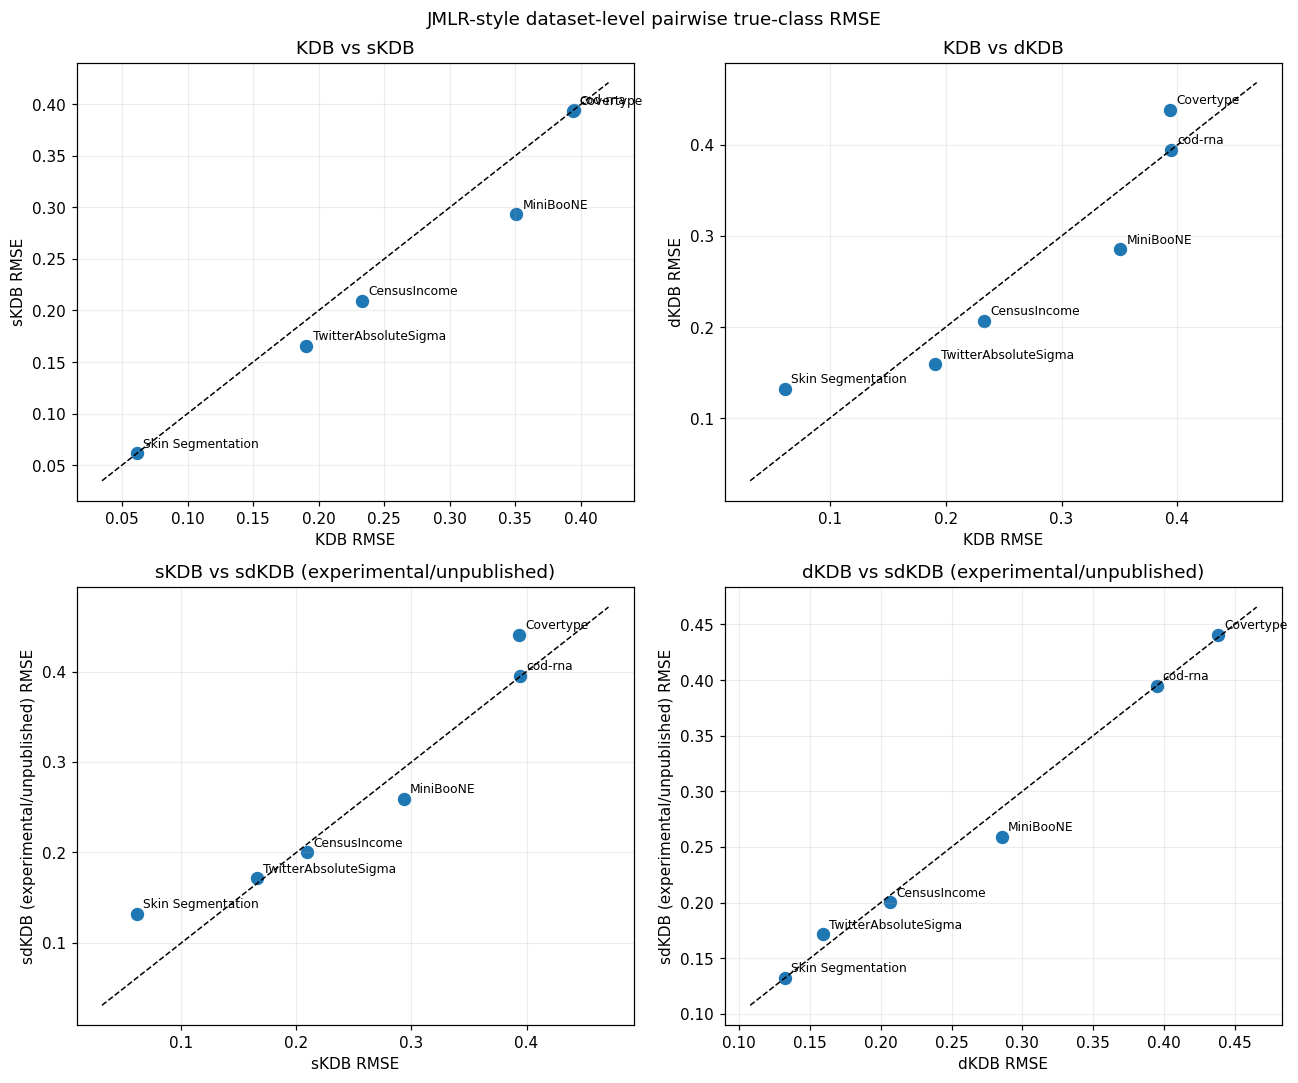

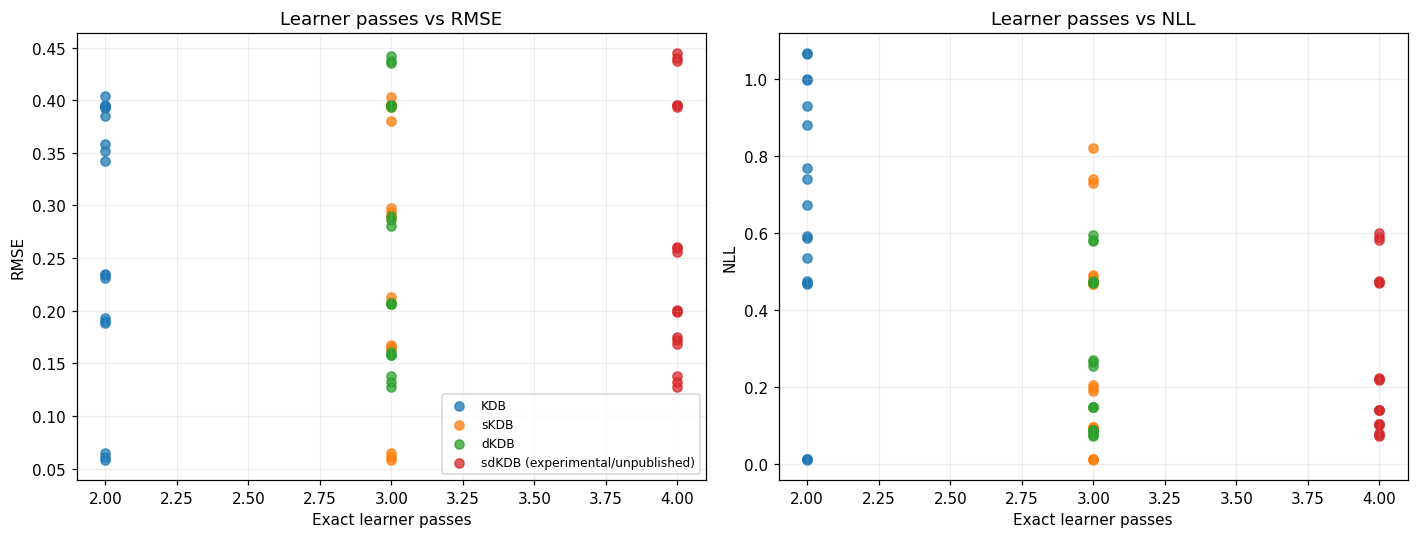

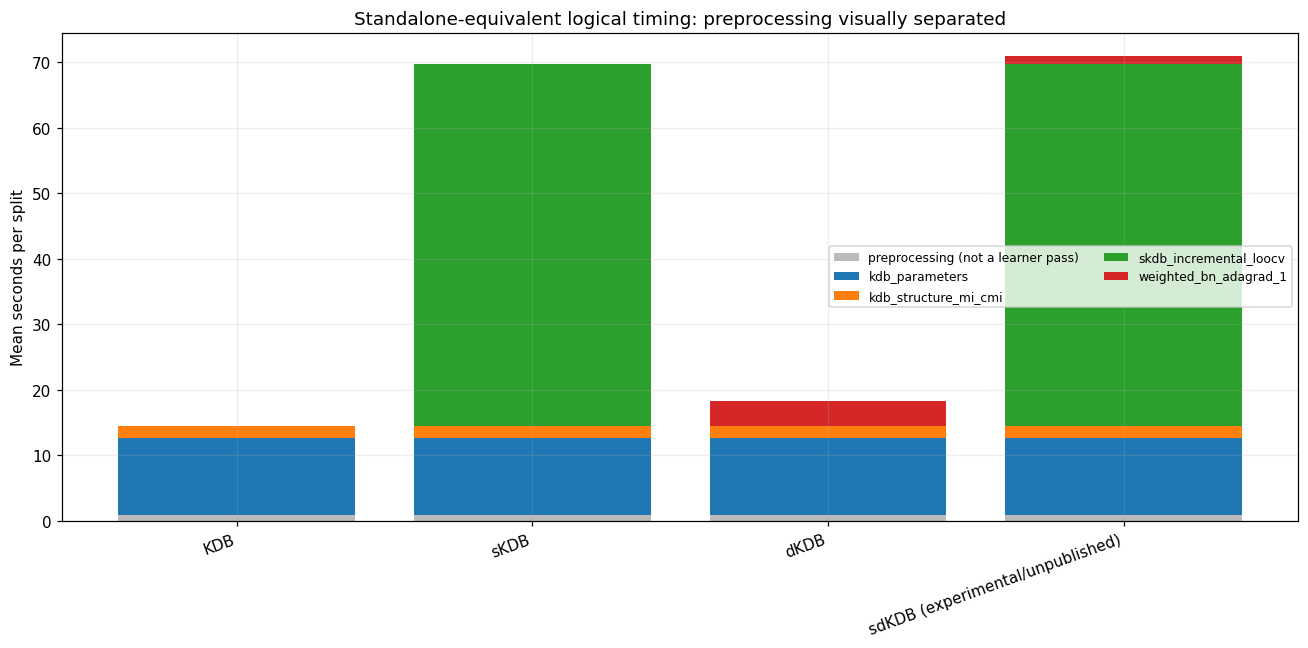

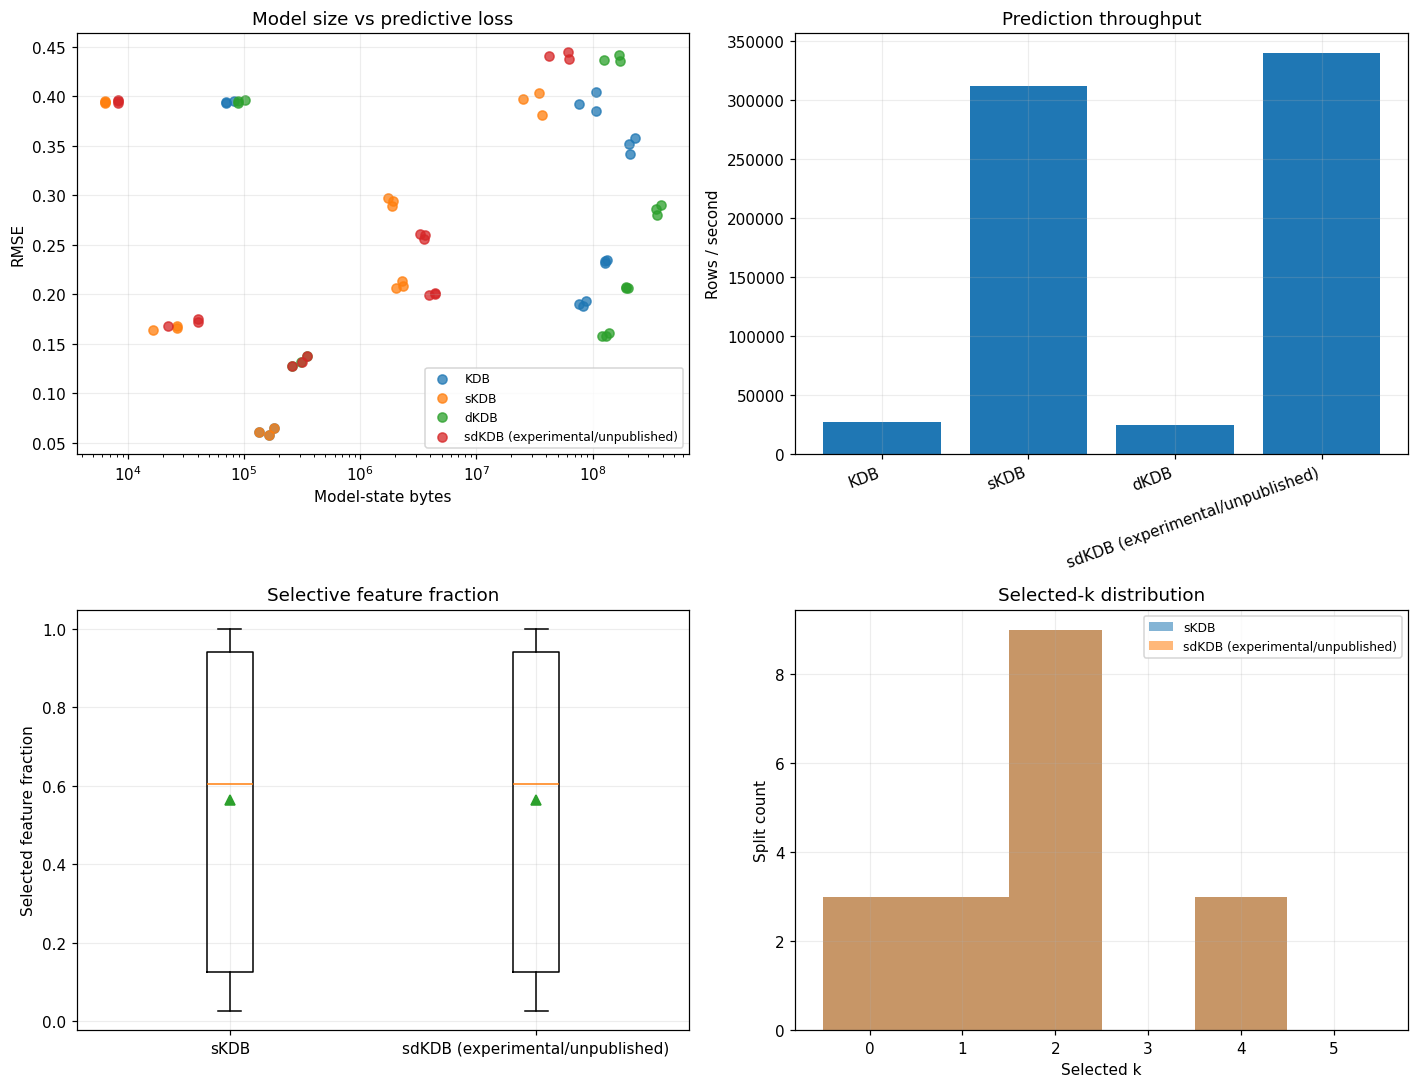

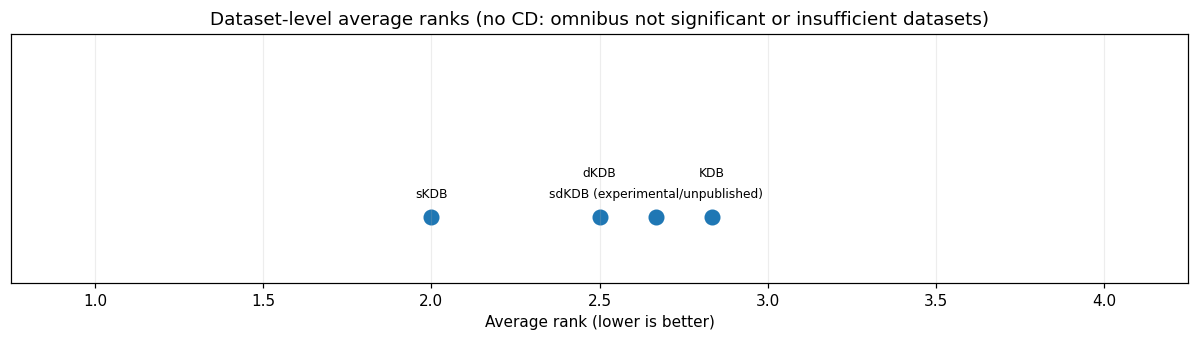

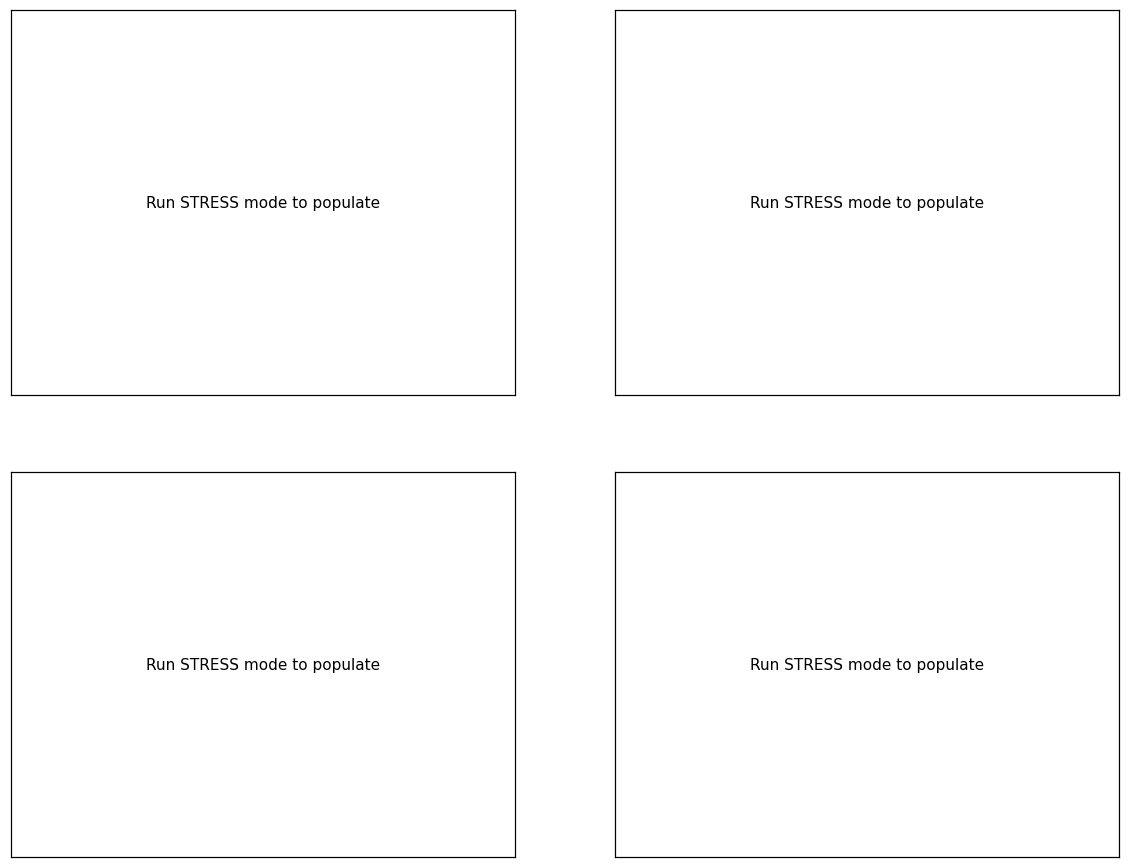

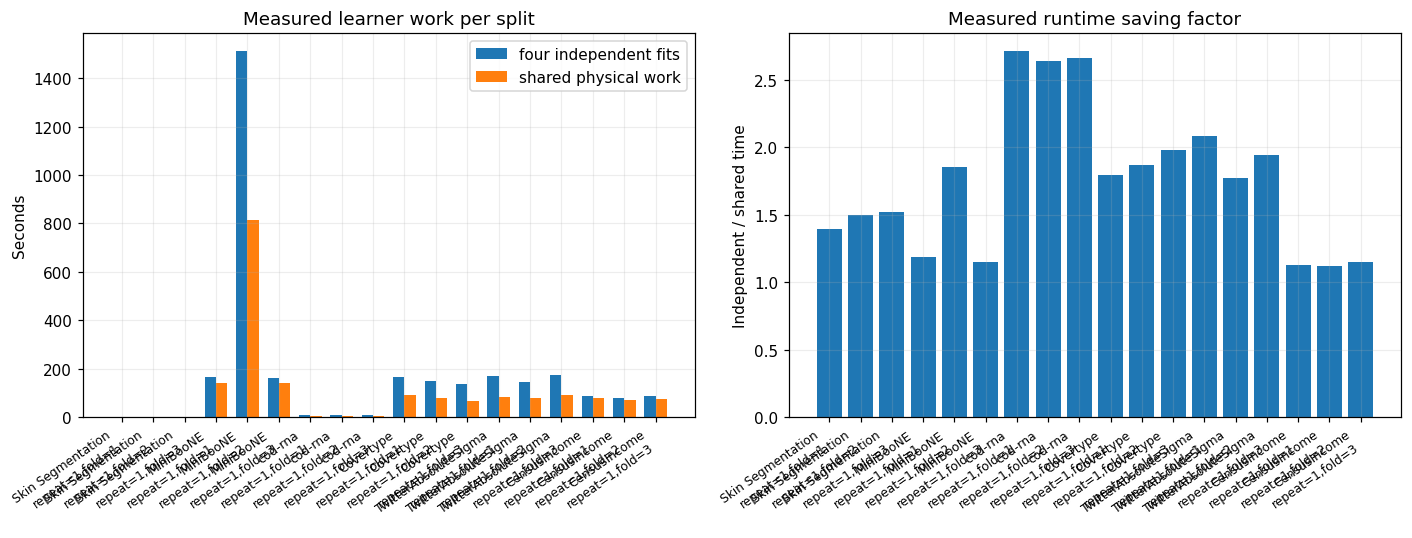

All 7 final figure functions executed.


In [19]:
def _no_data(axis, message):
    axis.text(0.5, 0.5, message, ha="center", va="center", transform=axis.transAxes)
    axis.set_xticks([]); axis.set_yticks([])


def plot_pairwise_rmse(runs):
    means = comparison_dataset_means(runs)
    figure, axes = plt.subplots(2, 2, figsize=(12, 10))
    for axis, (left, right) in zip(axes.ravel(), PAIRWISE_COMPARISONS):
        pivot = means.pivot(index="dataset", columns="model", values="rmse_true_class_probability") if not means.empty else pd.DataFrame()
        if left not in pivot or right not in pivot:
            _no_data(axis, "No complete comparison")
            continue
        paired = pivot[[right, left]].dropna()
        if paired.empty:
            _no_data(axis, "No complete comparison")
            continue
        low = float(paired.min().min()); high = float(paired.max().max())
        pad = max((high - low) * 0.08, 1e-4)
        axis.plot([low - pad, high + pad], [low - pad, high + pad], "k--", linewidth=1)
        axis.scatter(paired[right], paired[left], s=60)
        for name, row in paired.iterrows():
            axis.annotate(name, (row[right], row[left]), xytext=(4, 4), textcoords="offset points", fontsize=8)
        axis.set(xlabel=f"{right} RMSE", ylabel=f"{left} RMSE", title=f"{right} vs {left}")
    figure.suptitle("JMLR-style dataset-level pairwise true-class RMSE")
    figure.tight_layout(); return figure


def plot_pass_tradeoffs(runs):
    figure, axes = plt.subplots(1, 2, figsize=(13, 5))
    for axis, metric, label in zip(axes, ["rmse_true_class_probability", "nll"], ["RMSE", "NLL"]):
        if runs.empty:
            _no_data(axis, "No run data"); continue
        for model, group in runs.groupby("model", sort=False):
            axis.scatter(group["learner_passes"], group[metric], label=model, alpha=0.75)
        axis.set(xlabel="Exact learner passes", ylabel=label, title=f"Learner passes vs {label}")
    if not runs.empty:
        axes[0].legend(fontsize=8)
    figure.tight_layout(); return figure


def plot_training_breakdown(runs, passes):
    figure, axis = plt.subplots(figsize=(12, 6))
    if runs.empty or passes.empty:
        _no_data(axis, "No timing data"); return figure
    prep = runs.groupby("model")["preprocessing_seconds"].mean().reindex(MODEL_ORDER).fillna(0)
    stages = passes.groupby(["model", "stage"])["seconds"].mean().unstack(fill_value=0).reindex(MODEL_ORDER).fillna(0)
    x = np.arange(len(MODEL_ORDER)); bottom = np.zeros(len(MODEL_ORDER))
    axis.bar(x, prep, label="preprocessing (not a learner pass)", color="#bbbbbb")
    bottom += prep.to_numpy()
    for stage in stages.columns:
        values = stages[stage].to_numpy()
        axis.bar(x, values, bottom=bottom, label=stage)
        bottom += values
    axis.set_xticks(x, MODEL_ORDER, rotation=20, ha="right")
    axis.set_ylabel("Mean seconds per split")
    axis.set_title("Standalone-equivalent logical timing: preprocessing visually separated")
    axis.legend(fontsize=8, ncol=2)
    figure.tight_layout(); return figure


def plot_size_throughput_selection(runs):
    figure, axes = plt.subplots(2, 2, figsize=(13, 10))
    if runs.empty:
        for axis in axes.ravel(): _no_data(axis, "No run data")
        return figure
    for model, group in runs.groupby("model", sort=False):
        axes[0, 0].scatter(group["model_state_bytes"], group["rmse_true_class_probability"], label=model, alpha=0.75)
    axes[0, 0].set(xscale="log", xlabel="Model-state bytes", ylabel="RMSE", title="Model size vs predictive loss")
    throughput = runs.groupby("model")["prediction_throughput_rows_per_second"].mean().reindex(MODEL_ORDER)
    axes[0, 1].bar(np.arange(len(throughput)), throughput)
    axes[0, 1].set_xticks(np.arange(len(throughput)), throughput.index, rotation=20, ha="right")
    axes[0, 1].set(ylabel="Rows / second", title="Prediction throughput")
    selective = runs[runs["model"].isin(["sKDB", "sdKDB (experimental/unpublished)"])]
    if selective.empty:
        _no_data(axes[1, 0], "No selective runs"); _no_data(axes[1, 1], "No selective runs")
    else:
        data = [selective.loc[selective["model"] == model, "selected_feature_fraction"].to_numpy() for model in ["sKDB", "sdKDB (experimental/unpublished)"]]
        axes[1, 0].boxplot(data, tick_labels=["sKDB", "sdKDB (experimental/unpublished)"], showmeans=True)
        axes[1, 0].set(ylabel="Selected feature fraction", title="Selective feature fraction")
        for model, group in selective.groupby("model", sort=False):
            axes[1, 1].hist(group["selected_k"], bins=np.arange(-0.5, KMAX + 1.5), alpha=0.55, label=model)
        axes[1, 1].set(xlabel="Selected k", ylabel="Split count", title="Selected-k distribution")
        axes[1, 1].set_xticks(range(KMAX + 1)); axes[1, 1].legend(fontsize=8)
    axes[0, 0].legend(fontsize=8)
    figure.tight_layout(); return figure


def plot_average_ranks(runs, friedman_result):
    figure, axis = plt.subplots(figsize=(11, 3.2))
    ranks = model_rank_table(runs)
    if ranks.empty:
        _no_data(axis, "Insufficient complete datasets for ranks"); return figure
    average = ranks[MODEL_ORDER].mean().sort_values()
    y = np.zeros(len(average))
    axis.scatter(average.values, y, s=90)
    for index, (model, rank) in enumerate(average.items()):
        axis.annotate(model, (rank, 0), xytext=(0, 12 + 14 * (index % 2)), textcoords="offset points", ha="center", fontsize=8)
    axis.set_xlim(0.75, len(MODEL_ORDER) + 0.25); axis.set_ylim(-0.2, 0.55)
    axis.set_yticks([]); axis.set_xlabel("Average rank (lower is better)")
    title = "Dataset-level average ranks"
    cd = friedman_result.get("nemenyi_critical_difference")
    if cd is not None:
        start = 1.0; axis.plot([start, start + cd], [0.38, 0.38], color="black", linewidth=3)
        axis.text(start + cd / 2, 0.42, f"Nemenyi CD={cd:.3f}", ha="center", fontsize=8)
        title += " with significant-omnibus Nemenyi CD"
    else:
        title += " (no CD: omnibus not significant or insufficient datasets)"
    axis.set_title(title); figure.tight_layout(); return figure


def plot_stress_scaling(runs):
    figure, axes = plt.subplots(2, 2, figsize=(13, 10))
    stress = runs[runs["dataset"].isin(["SUSY", "HIGGS"]) & runs["scaling_train_rows"].notna()] if not runs.empty else pd.DataFrame()
    specs = [
        ("learner_training_seconds", "Learner training seconds"),
        ("rmse_true_class_probability", "RMSE"),
        ("selected_k", "Selected k"),
        ("selected_feature_fraction", "Selected feature fraction"),
    ]
    if stress.empty:
        for axis in axes.ravel(): _no_data(axis, "Run STRESS mode to populate")
        return figure
    aggregate = stress.groupby(["dataset", "model", "scaling_train_rows"], as_index=False)[[item[0] for item in specs]].mean()
    for axis, (metric, label) in zip(axes.ravel(), specs):
        for (dataset, model), group in aggregate.groupby(["dataset", "model"], sort=False):
            axis.plot(group["scaling_train_rows"], group[metric], marker="o", label=f"{dataset}: {model}")
        axis.set(xlabel="Training rows", ylabel=label, title=f"Stress scaling: {label}")
        axis.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    axes[0, 0].legend(fontsize=7, ncol=2)
    figure.tight_layout(); return figure



def plot_runtime_optimization_impact(runs):
    figure, axes = plt.subplots(1, 2, figsize=(13, 5))
    if runs.empty:
        _no_data(axes[0], "No run data")
        _no_data(axes[1], "No run data")
        return figure
    fold_level = runs.drop_duplicates(["dataset", "split_id"])
    labels = (fold_level["dataset"] + "\n" + fold_level["split_id"]).tolist()
    x = np.arange(len(fold_level))
    axes[0].bar(x - 0.18, fold_level["estimated_independent_learner_seconds"], 0.36, label="four independent fits")
    axes[0].bar(x + 0.18, fold_level["physical_shared_learner_seconds"], 0.36, label="shared physical work")
    axes[0].set_xticks(x, labels, rotation=35, ha="right", fontsize=8)
    axes[0].set_ylabel("Seconds")
    axes[0].set_title("Measured learner work per split")
    axes[0].legend()
    axes[1].bar(x, fold_level["runtime_savings_factor"])
    axes[1].set_xticks(x, labels, rotation=35, ha="right", fontsize=8)
    axes[1].set_ylabel("Independent / shared time")
    axes[1].set_title("Measured runtime saving factor")
    figure.tight_layout()
    return figure


FINAL_FIGURES = [
    plot_pairwise_rmse(RUNS),
    plot_pass_tradeoffs(RUNS),
    plot_training_breakdown(RUNS, PASSES),
    plot_size_throughput_selection(RUNS),
    plot_average_ranks(RUNS, FRIEDMAN_RESULT),
    plot_stress_scaling(RUNS),
    plot_runtime_optimization_impact(RUNS),
]
plt.show()
print(f"All {len(FINAL_FIGURES)} final figure functions executed.")


## 12. Final tables, findings, and runtime audit


In [20]:
AUTHORITATIVE_TABLES = {
    "dataset_source_readiness": DATASET_SOURCE_READINESS,
    "dataset_metadata": DATASET_METADATA,
    "per_dataset_model_summary": DATASET_MODEL_SUMMARY,
    "mean_plus_minus_std": MEAN_STD_TABLE,
    "pass_audit": PASSES,
    "computational_efficiency": COMPUTATIONAL_EFFICIENCY_TABLE,
    "model_selection": MODEL_SELECTION_TABLE,
    "dataset_level_model_ranks": DATASET_LEVEL_RANKS,
    "win_draw_loss": WIN_DRAW_LOSS_TABLE,
    "pairwise_effects_with_95ci": PAIRWISE_EFFECT_TABLE,
    "nemenyi_posthoc": NEMENYI_TABLE,
    "wilcoxon_holm_supplement": WILCOXON_HOLM_TABLE,
    "attempt_status": ATTEMPT_STATUS,
}
for table_name, table in AUTHORITATIVE_TABLES.items():
    print(f"\n--- {table_name} ({len(table)} rows) ---")
    display(table)

if RUNS.empty:
    print("No empirical finding is claimed because no benchmark rows are available.")
else:
    best = comparison_dataset_means(RUNS)
    if not best.empty:
        winners = best.loc[best.groupby("dataset")["rmse_true_class_probability"].idxmin(), ["dataset", "model", "rmse_true_class_probability"]]
        print("Concise descriptive finding (not a significance claim): lowest mean RMSE by dataset")
        display(winners)

expected_columns = {
    "dataset", "split_id", "model", "rmse_true_class_probability", "zero_one_loss",
    "accuracy", "nll", "multiclass_brier_score", "learner_passes",
    "learner_rows_processed", "preprocessing_seconds", "learner_training_seconds",
    "prediction_seconds", "total_pipeline_seconds", "model_state_bytes",
    "selected_k", "selected_feature_fraction", "discriminative_passes",
}
if RUN_BENCHMARKS:
    assert not RUNS.empty
    assert expected_columns.issubset(RUNS.columns)
    assert set(RUNS["model"]) == set(MODEL_ORDER)
    assert RUNS.groupby(["dataset", "split_id"])["model"].nunique().eq(4).all()
    assert (RUNS["configuration_id"] == CONFIGURATION_ID).all()
    print("FINAL VALIDATION PASS — tidy schema, four learners per split, and configuration IDs are consistent.")



--- dataset_source_readiness (11 rows) ---


,dataset,source_status,paper_rows_features_classes,source,note
0,PokerHand,automatic source configured; download/schema c...,"(164860, 10, 10)","UCI 158, complete training + test partitions","UCI has 1,025,010 rows; paper Table 1 says 164..."
1,Diabetes,original file required,"(101766, 46, 2)","FewPLa binary Diabetes, original experiment fi...",Raw UCI readmitted has 3 classes; the paper do...
2,Waveform,original file required,"(100000, 18, 3)","FewPLa 100,000-row, 18-feature Waveform, origi...","UCI download has 5,000 rows and 21 features. D..."
3,WearableComputing,original file required,"(165632, 18, 5)",UCI 250 / PUC-Rio body postures and movements,UCI currently hosts only an example; supply th...
4,Localization,automatic source configured; download/schema c...,"(164860, 4, 11)",UCI 196 ConfLongDemo_JSI: tag identifier and x...,Four-feature reconstruction: omit sequence ide...
5,TwitterAbsoluteSigma,automatic source configured; download/schema c...,"(140607, 77, 2)",UCI 248 donor archive: Twitter Absolute Sigma 500,"Use published classification labels, never the..."
6,CensusIncome,automatic source configured; download/schema c...,"(299285, 41, 2)","UCI 117 Census-Income (KDD), both partitions, ...","UCI instructs excluding instance weight, givin..."
7,KddCUP,original file required,"(5209460, 41, 40)",KDD Cup 1999 full kddcup.data.gz + corrected.g...,The current UCI archive contains documentation...
8,USPSExtended,original file required,"(341462, 676, 2)","CVM extended binary USPS, original experiment ...","341,462 rows, 676 features, 2 classes; ordinar..."
9,MNIST,automatic source configured; download/schema c...,"(8100000, 784, 10)","LIBSVM mnist8m (unscaled), extended MNIST",8.1 million rows; never replace with ordinary ...



--- dataset_metadata (6 rows) ---


,name,source,url,n_rows,n_features,n_classes,class_counts,class_proportions,missing_feature_values,nonfinite_feature_values,numeric_dtype_compatible,feature_dtype_summary,approx_raw_memory_bytes,sampled,requested_row_limit,paper_shape,source_shape,paper_shape_matches,paper_identity_verified,categorical_indices,sampling_policy,note,source_override_description,evaluation_scope,is_full_dataset,processed_cache_hit
0,Skin Segmentation,UCI Skin Segmentation via OpenML data_id=1502,https://www.openml.org/d/1502,50000,3,2,"{""1"": 10377, ""2"": 39623}","{""1"": 0.20754, ""2"": 0.79246}",0,0,True,"{""int64"": 3}",1250480,True,50000,None,None,None,None,None,None,None,None,deterministic declared practical sample,False,False
1,MiniBooNE,UCI MiniBooNE via OpenML data_id=41150,https://www.openml.org/d/41150,50000,50,2,"{""True"": 14031, ""False"": 35969}","{""True"": 0.28062, ""False"": 0.71938}",0,0,True,"{""float64"": 50}",20050487,True,50000,None,None,None,None,None,None,None,None,deterministic declared practical sample,False,False
2,cod-rna,LIBSVM cod-rna train/validation/test files,https://www.csie.ntu.edu.tw/~cjlin/libsvmtools...,50000,8,2,"{""-1"": 33333, ""1"": 16667}","{""-1"": 0.66666, ""1"": 0.33334}",0,0,True,"{""float64"": 8}",3250256,True,50000,None,None,None,None,None,None,None,None,deterministic declared practical sample,False,False
3,Covertype,UCI Covertype via sklearn fetch_covtype,https://archive.ics.uci.edu/dataset/31/covertype,50000,54,7,"{""1"": 18230, ""2"": 24380, ""3"": 3077, ""4"": 236, ...","{""1"": 0.3646, ""2"": 0.4876, ""3"": 0.06154, ""4"": ...",0,0,True,"{""float64"": 54}",21800256,True,50000,None,None,None,None,None,None,None,None,deterministic declared practical sample,False,False
4,TwitterAbsoluteSigma,UCI 248 donor archive: Twitter Absolute Sigma 500,https://lig-aptikal.imag.fr/buzz-prediction-in...,50000,77,2,"{""0.0"": 40129, ""1.0"": 9871}","{""0.0"": 0.80258, ""1.0"": 0.19742}",0,0,True,"{""float64"": 42, ""int64"": 35}",31200256,True,50000,"[140607, 77, 2]","[140707, 77, 2]",False,False,[],"proportional without replacement, minimum fold...","Use published classification labels, never the...",None,deterministic declared practical sample,False,False
5,CensusIncome,"UCI 117 Census-Income (KDD), both partitions, ...",https://archive.ics.uci.edu/dataset/117/census...,50000,40,2,"{""- 50000."": 46896, ""50000+."": 3104}","{""- 50000."": 0.93792, ""50000+."": 0.06208}",104962,104962,True,"{""float64"": 32, ""int64"": 8}",19247152,True,50000,"[299285, 41, 2]","[299285, 40, 2]",False,False,"[1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...","proportional without replacement, minimum fold...","UCI instructs excluding instance weight, givin...",None,deterministic declared practical sample,False,False



--- per_dataset_model_summary (24 rows) ---


...


--- attempt_status (15 rows) ---


,dataset,mode,status,reason,configuration_id,requested_row_limit,evaluation_scope
0,Skin Segmentation,CORE_PRACTICAL,complete,None,54c0518917f385f8,50000,deterministic declared practical sample
1,MiniBooNE,CORE_PRACTICAL,complete,None,54c0518917f385f8,50000,deterministic declared practical sample
2,cod-rna,CORE_PRACTICAL,complete,None,54c0518917f385f8,50000,deterministic declared practical sample
3,Covertype,CORE_PRACTICAL,complete,None,54c0518917f385f8,50000,deterministic declared practical sample
4,PokerHand,CORE_PRACTICAL,failed,RuntimeError: Unable to download https://archi...,54c0518917f385f8,50000,deterministic declared practical sample
5,Diabetes,CORE_PRACTICAL,needs-original-source,Diabetes: Raw UCI readmitted has 3 classes; th...,54c0518917f385f8,50000,deterministic declared practical sample
6,Waveform,CORE_PRACTICAL,needs-original-source,"Waveform: UCI download has 5,000 rows and 21 f...",54c0518917f385f8,50000,deterministic declared practical sample
7,WearableComputing,CORE_PRACTICAL,needs-original-source,WearableComputing: UCI currently hosts only an...,54c0518917f385f8,50000,deterministic declared practical sample
8,Localization,CORE_PRACTICAL,failed,RuntimeError: Unable to download https://archi...,54c0518917f385f8,50000,deterministic declared practical sample
9,TwitterAbsoluteSigma,CORE_PRACTICAL,complete,None,54c0518917f385f8,50000,deterministic declared practical sample


Concise descriptive finding (not a significance claim): lowest mean RMSE by dataset


,dataset,model,rmse_true_class_probability
3,CensusIncome,sdKDB (experimental/unpublished),0.200043
6,Covertype,sKDB,0.393597
11,MiniBooNE,sdKDB (experimental/unpublished),0.258977
12,Skin Segmentation,KDB,0.061431
17,TwitterAbsoluteSigma,dKDB,0.158972
20,cod-rna,KDB,0.394458


FINAL VALIDATION PASS — tidy schema, four learners per split, and configuration IDs are consistent.


In [21]:
RUNTIME_CHANGE_LOG = pd.DataFrame([
    {"change": "Vectorized/parallel MDL", "helps": "removes Python candidate loop", "semantic_check": "exact cuts/transforms"},
    {"change": "Vectorized counts", "helps": "batched integer sufficient statistics", "semantic_check": "same structure/probabilities"},
    {"change": "Compiled sKDB LOOCV", "helps": "compiled row-prefix-k loop", "semantic_check": "same RMSE surface and selection"},
    {"change": "Compiled online discrimination", "helps": "compiled sequential updates", "semantic_check": "same weights/probabilities"},
    {"change": "Shared fold state", "helps": "5 physical vs 12 logical headline passes", "semantic_check": "same standalone model states/pass ledgers"},
    {"change": "Processed/result caches", "helps": "fast restart and per-model checkpoints", "semantic_check": "hash-keyed; final tables rebuilt here"},
    {"change": "Bounded/progressing downloads", "helps": "timeouts, retries, concurrent cod-rna parts", "semantic_check": "same official source partitions"},
    {"change": "Practical/full split", "helps": "bounded everyday run; full remains available", "semantic_check": "scope explicitly labelled; never pooled"},
])
display(RUNTIME_CHANGE_LOG)
if not RUNS.empty:
    runtime_audit = RUNS.drop_duplicates(["dataset", "split_id"])[[
        "dataset", "split_id", "evaluation_scope", "train_rows", "test_rows",
        "physical_learner_passes_executed", "logical_learner_passes_represented",
        "physical_shared_learner_seconds", "estimated_independent_learner_seconds",
        "runtime_savings_factor",
    ]]
    display(runtime_audit)
    assert (runtime_audit["physical_learner_passes_executed"] == 5).all()
    assert (runtime_audit["logical_learner_passes_represented"] == 12).all()
    print("FINAL RUNTIME AUDIT PASS — optimized physical work and logical study accounting are both explicit.")


,change,helps,semantic_check
0,Vectorized/parallel MDL,removes Python candidate loop,exact cuts/transforms
1,Vectorized counts,batched integer sufficient statistics,same structure/probabilities
2,Compiled sKDB LOOCV,compiled row-prefix-k loop,same RMSE surface and selection
3,Compiled online discrimination,compiled sequential updates,same weights/probabilities
4,Shared fold state,5 physical vs 12 logical headline passes,same standalone model states/pass ledgers
5,Processed/result caches,fast restart and per-model checkpoints,hash-keyed; final tables rebuilt here
6,Bounded/progressing downloads,"timeouts, retries, concurrent cod-rna parts",same official source partitions
7,Practical/full split,bounded everyday run; full remains available,scope explicitly labelled; never pooled


,dataset,split_id,evaluation_scope,train_rows,test_rows,physical_learner_passes_executed,logical_learner_passes_represented,physical_shared_learner_seconds,estimated_independent_learner_seconds,runtime_savings_factor
0,Skin Segmentation,"repeat=1,fold=1",deterministic declared practical sample,33333,16667,5,12,0.696402,0.970221,1.393190
4,Skin Segmentation,"repeat=1,fold=2",deterministic declared practical sample,33333,16667,5,12,0.653226,0.978716,1.498281
8,Skin Segmentation,"repeat=1,fold=3",deterministic declared practical sample,33334,16666,5,12,0.630852,0.957722,1.518142
12,MiniBooNE,"repeat=1,fold=1",deterministic declared practical sample,33333,16667,5,12,138.989467,164.646830,1.184599
16,MiniBooNE,"repeat=1,fold=2",deterministic declared practical sample,33333,16667,5,12,815.770187,1510.104792,1.851140
20,MiniBooNE,"repeat=1,fold=3",deterministic declared practical sample,33334,16666,5,12,139.232971,160.432533,1.152260
24,cod-rna,"repeat=1,fold=1",deterministic declared practical sample,33333,16667,5,12,3.499354,9.487648,2.711257
28,cod-rna,"repeat=1,fold=2",deterministic declared practical sample,33333,16667,5,12,3.412373,9.005190,2.638982
32,cod-rna,"repeat=1,fold=3",deterministic declared practical sample,33334,16666,5,12,3.723679,9.906994,2.660539
36,Covertype,"repeat=1,fold=1",deterministic declared practical sample,33333,16667,5,12,91.881887,165.250766,1.798513


FINAL RUNTIME AUDIT PASS — optimized physical work and logical study accounting are both explicit.


### Interpretation guardrails

- Practical-mode results answer the same comparative learner question on
  declared deterministic samples; they are not labelled full-dataset runs.
- `learner_training_seconds` and the logical pass audit remain
  standalone-equivalent per model. `physical_shared_learner_seconds`
  reports what this notebook actually spent after safe sharing.
- CV folds are repeated measurements, never independent datasets in the
  Friedman/Nemenyi analysis.
- Peak RSS remains `NaN` where the OS cannot provide a reliable high-water
  mark.
- **sdKDB is experimental/unpublished.**
